# 제2장 AI를 이용한 당뇨망막병증 감지

## 목차

**Step 1. 소개**

**Step 2. 관련 연구**
1. 전통적 접근 방식
2. 머신러닝 기반 연구
3. 딥러닝 기반 연구
4. 앙상블 학습의 활용
5. 데이터 부족 문제 해결
6. 성능 비교

**Step 3. 데이터와 방법론**
1. 데이터셋
2. 전처리 기법
3. 데이터 증강
4. 제안하는 모델

**Step 4. 실험 결과**
1. 모델 성능 평가 방법
2. 베이스 모델 성능
3. 가중치 기반 앙상블 모델 성능
4. 전처리와 데이터 증강의 효과
5. 결과 비교와 의의
6. 결론

**Step 5. 전체 코드 개요**
1. 데이터 준비 및 전처리
2. 데이터 로더 생성
3. CNN 모델 설계
4. 모델 학습
5. 특징 추출 및 J48 분류기 학습
6. 학습 결과 시각화
7. 개선 사항

**Step 6. 코드 자세히 살펴보기** (커스텀 CNN + J48 결정 트리)
1. 모듈 임포트
2. 데이터 읽어오기 및 전처리
3. 데이터 증강
4. CNN 모델
5. 모델 학습 및 성능 평가

**Step 7. CNN을 이용한 코드 자세히 살펴보기** (전이 학습 + 앙상블)
1. 모듈 임포트
2. 데이터 로드 및 전처리
3. 데이터 증강
4. InceptionV3 모델
5. VGG16 모델
6. 앙상블 모델

**참조사항** — 이 노트북에서 개선·보완한 내용 정리

**Kaggle 실행 기록** — 실행하면서 겪은 문제와 해결, 측정 시간, 1차·최종 실행 비교

**이 노트북을 실행하기 전에 꼭 확인하세요**

1장(WBCD)은 인터넷에서 바로 받는 작은 표 데이터라 노트북만 열면 바로 실행됐지만, 2장은 **망막 사진 수천 장**으로 딥러닝 모델을 학습시키기 때문에 준비물이 필요합니다. 이 노트북은 **Kaggle 노트북(무료 GPU)에서 그대로 실행되도록** 맞춰 두었습니다. 내 PC에서 실행할 때는 아래 준비물을 확인하세요.

| 항목 | 내용 |
|---|---|
| 데이터 | Kaggle **APTOS 2019 Blindness Detection** 대회 데이터 (`train.csv` + `train_images/` 폴더). 압축 기준 약 10GB 안팎이라 **디스크 여유 공간**을 먼저 확인하세요. Kaggle 계정으로 로그인하고 대회 규칙(Rules)에 동의해야 내려받을 수 있습니다. |
| 경로 | Step 5·6·7 맨 앞의 **실행 설정 셀**이 Kaggle에서는 데이터 위치를 자동으로 찾고, 내 PC에서는 `C:/Dataset`(데이터)과 `C:/testRun`(모델 저장)을 씁니다(책은 `D:/Dataset`, `D:/testRun`). 처음 실행할 때 사진을 긴 변 512픽셀로 줄여 따로 저장해 두어 학습 속도를 높입니다. |
| 에포크 | 책의 원래 값은 Step 5가 **50**, Step 6·7이 **100**입니다. 이 노트북은 Kaggle의 12시간 실행 제한 안에 끝나도록 실행 설정 셀의 `EPOCHS = 30` 하나로 모든 학습 에포크를 관리합니다. |
| 하드웨어 | **GPU 권장**. TensorFlow는 2.11부터 Windows에서 GPU를 지원하지 않아, 내 PC(Windows)에서는 CPU로만 학습합니다. 이 경우 에포크당 수십 분이 걸릴 수 있으므로 `EPOCHS`를 5∼10으로 줄이거나 Kaggle(GPU) 또는 WSL2에서 실행하세요. |
| 버전 | TensorFlow 2.21 / Keras 3 기준으로 코드를 고쳐 두었습니다. 책 원래 코드는 옛날 Keras 2 문법이라 최신 버전에서 여러 곳이 오류로 멈춥니다(자세한 내용은 각 **개선 사항** 블록과 맨 끝 **참조사항** 참고). |
| 사전 학습 가중치 | Step 7의 InceptionV3·VGG16은 처음 실행할 때 ImageNet 가중치 파일(약 150MB)을 인터넷에서 자동으로 내려받습니다. Kaggle에서는 노트북 설정의 **Internet**을 켜 두어야 합니다. |

실행 순서는 **Step 5 → Step 6 → Step 7**입니다. Step 7의 앙상블은 Step 6에서 저장한 CNN 모델 파일(`CNN.h5`)을 불러오므로, Step 6을 먼저 끝내야 합니다.

**이 노트북에 담긴 실행 결과**

아래의 모든 출력(표·그래프·학습 로그)은 **Kaggle 노트북에서 실제로 실행한 결과**입니다.

| 항목 | 값 |
|---|---|
| 실행 환경 | Kaggle Notebook, GPU T4 ×2 (TensorFlow는 그중 1개로 학습), Latest Container Image |
| 에포크 | `EPOCHS = 30` (책: Step 5는 50, Step 6·7은 100) |
| 사진 | 3,662장을 긴 변 512픽셀로 줄여 사용 (학습 입력은 227×227, 224×224) |
| 검증 데이터 | 앞쪽 20% = 732장 (학습 2,930장) |
| 학습 시간 | 학습 5번 합계 약 3시간 7분 (Step 5 CNN 30분, Step 6 CNN 39분, InceptionV3 39분, VGG16 39분, 앙상블 40분) |

**결과 한 줄 요약**: 전이 학습 모델(InceptionV3·VGG16)은 검증 정확도 약 75%, 이 둘과 CNN을 합친 <strong>가중치 앙상블은 77.3%(QWK 0.81)</strong>로 가장 좋았습니다. 반면 책이 90.56%라고 보고한 **커스텀 CNN은 모든 사진을 "0 정상"으로 예측**하는 상태에서 벗어나지 못했습니다. 각 결과 아래의 **결과 해석** 블록과, 맨 끝의 **Kaggle 실행 기록**에 자세히 정리했습니다.

> 저장된 출력에서는 오류가 아닌 GPU·XLA 안내 로그(빨간 배경으로 보이던 표준 오류 출력)를 정리해 두었습니다. 실행 중 오류(`Traceback`)는 한 번도 나지 않았습니다.

## Step 1. 소개

여기에서는 당뇨망막병증(Diabetic Retinopathy, DR)을 조기에 감지하고 단계별로 분류하기 위해 제안된 딥러닝 기반 접근 방식을 설명합니다.

당뇨병은 혈액 속 포도당 농도가 비정상적으로 높아지는 질환으로, 주로 인슐린이라는 호르몬의 부족이나 기능 장애로 인해 발생합니다. 이로 인해 환자는 극심한 갈증, 잦은 배뇨, 피로, 시력 저하, 상처가 잘 낫지 않는 등의 증상을 경험할 수 있습니다. 당뇨병의 주요 원인으로는 유전적 요인, 건강하지 않은 식습관과 운동 부족, 나이 증가 등이 있으며, 스트레스와 특정 약물도 영향을 줄 수 있습니다. 당뇨병을 제때 진단하지 못하면 심장병, 뇌졸중, 신장병, 신경 손상, 시력 상실 등과 같은 심각한 합병증으로 이어질 수 있습니다.

특히 당뇨망막병증은 당뇨병으로 인해 망막의 혈관이 손상되면서 시력을 점차 잃게 되는 질환으로, 당뇨병 환자에게 흔히 나타나는 합병증 중 하나입니다. 이 질환은 진행 단계에 따라 정상, 경미, 중간, 심각, 증식성으로 분류됩니다. 초기 단계에서 발견하면 치료를 통해 시력을 보존할 수 있지만, 조기 진단이 어려운 경우가 많아 치료 기회를 놓치기도 합니다.

기존의 당뇨망막병증 진단은 숙련된 안과 전문의가 망막 이미지를 분석하는 방식으로 이루어졌습니다. 하지만 이 과정은 시간이 오래 걸리고 대량의 데이터를 효율적으로 처리하기 어렵다는 한계가 있습니다. 이러한 문제를 해결하기 위해 인공지능 기술이 도입되었습니다. 인공지능은 대량의 망막 이미지를 신속하고 정확하게 분석하여 질환을 감지하고, 진행 단계까지 분류할 수 있는 강력한 도구로 떠오르고 있습니다. 특히 딥러닝 기술을 활용하면 기존의 수작업 기반 진단보다 더 높은 정확성과 일관성을 제공할 수 있습니다.

첨부된 문서에서는 이러한 배경을 바탕으로 당뇨망막병증을 조기에 정확히 감지하기 위한 딥러닝 기반의 자동화된 진단 시스템을 제안하고 있습니다. 이 연구는 Inception-v3, VGG16, 사용자 정의 CNN 모델을 결합한 가중치 평균 앙상블 모델을 활용하여 높은 정확도를 달성했습니다. 이를 통해 기존 방식보다 빠르고 정확하며, 의료 접근성이 낮은 지역에서도 효과적으로 활용 가능한 진단 방법을 제시하고 있습니다. 이 모델은 95.06%의 정확도와 98.10%의 AUC 점수를 기록하며, 조기 진단의 가능성을 한층 높이는 데 기여하고 있습니다.

인공지능 기반 자동화 진단 시스템은 진단 속도와 정확성을 높이고, 의료 자원이 부족한 지역에서도 사용할 수 있는 효율적인 도구로 환자들에게 더 나은 의료 서비스를 제공합니다. 이는 당뇨망막병증뿐만 아니라 다른 의료 분야에도 적용 가능성이 있어, 향후 의료 환경을 혁신할 수 있는 중요한 기술로 평가받고 있습니다.

**용어 풀이 — 이 장에서 계속 나오는 말**

| 용어 | 쉬운 뜻 |
|---|---|
| 망막(retina) | 눈 안쪽 벽에 붙은 얇은 막. 카메라의 필름(이미지 센서)처럼 빛을 받아 신경 신호로 바꿉니다. 아주 가는 혈관이 많아서 혈당이 높은 상태가 오래가면 쉽게 손상됩니다. |
| 안저 사진(fundus image) | 동공을 통해 망막을 찍은 사진. 이 장의 데이터(APTOS 2019)가 바로 안저 사진입니다. 가운데가 둥글고 바깥은 검은 배경입니다. |
| 미세동맥류(microaneurysm) | 망막의 가는 혈관 벽이 약해져 작게 부풀어 오른 점. DR의 가장 이른 징후입니다. |
| 증식성(proliferative) | 망막에 산소가 부족해지자 눈이 **새 혈관을 만들어 내는** 단계. 새 혈관은 약해서 쉽게 터지므로 가장 위험합니다. |
| CNN | 합성곱 신경망(Convolutional Neural Network). 사진을 작은 창(필터)으로 훑으며 선·점·모양 같은 특징을 스스로 배우는 딥러닝 모델입니다. |
| 앙상블(ensemble) | 여러 모델의 예측을 합쳐 최종 답을 내는 방법. 한 사람보다 여러 전문가의 의견을 모으는 것과 비슷합니다. |
| 가중치 평균 앙상블 | 앙상블할 때 <strong>성능이 좋은 모델의 의견에 더 큰 비중(가중치)</strong>을 주어 평균을 내는 방식입니다. |
| AUC | 모델이 "병이 있는 사진"과 "없는 사진"을 얼마나 잘 구분하는지를 0∼1(또는 0∼100%)로 나타낸 점수. 1에 가까울수록 좋고, 0.5면 동전 던지기 수준입니다. 1장 Step 3의 성능 평가 방법에 자세히 나와 있습니다. |

## Step 2. 관련 연구

여기에서는 당뇨망막병증(Diabetic Retinopathy, DR) 진단과 분류를 위한 기존 연구들을 정리합니다. DR은 조기 발견이 중요한 질환으로, 기존 연구들은 이 질환을 정확히 감지하고 단계적으로 분류하기 위해 다양한 기술을 활용했습니다. 주요 내용은 다음과 같습니다.

### 1. 전통적 접근 방식

과거에는 당뇨망막병증을 진단하기 위해 주로 전문가가 직접 망막 이미지를 분석하는 방식이 사용되었습니다. 이는 환자의 망막 사진을 의료 장비를 통해 촬영한 후, 전문가가 망막 혈관의 손상 정도, 출혈, 또는 미세 동맥류와 같은 이상 징후를 눈으로 확인하는 작업이었습니다. 이러한 방식은 정확한 진단을 위해 고도의 훈련과 경험을 가진 전문 의료진이 필요하며, 결과적으로 시간이 많이 소요되었습니다. 또한, 여러 환자의 데이터를 동시에 분석하거나 대규모 데이터셋을 처리하는 데에 한계가 있었습니다.

특히, 망막 이미지를 분석하는 작업은 사람의 눈에 의존하기 때문에 피로와 주관적인 판단 오류가 발생할 가능성도 있었습니다. 이러한 한계는 정확하고 신속한 진단이 요구되는 상황에서 큰 문제로 작용했습니다. 이에 따라 연구자들은 이러한 문제를 해결하기 위해 자동화된 방법, 특히 컴퓨터를 활용한 분석 기법을 개발하고 적용하기 시작했습니다. 이러한 자동화 기술은 시간이 적게 들고, 대규모 데이터셋도 효율적으로 처리할 수 있는 가능성을 열어주었습니다.

### 2. 머신러닝 기반 연구

초기 당뇨병성 망막병증(Diabetic Retinopathy, DR) 진단 연구에서는 머신러닝 알고리즘을 활용하여 망막 이미지를 분석하려는 시도가 이루어졌습니다. 이러한 연구에서는 다양한 알고리즘이 사용되었으며, 각각의 알고리즘은 독특한 방식으로 DR 이미지를 처리하고 분류하는 데 기여했습니다.

첫 번째로, K-최근접 이웃(KNN) 알고리즘은 DR 진단에서 간단하고 직관적인 접근법으로 주목받았습니다. 이 방법은 이미지 데이터의 각 샘플 간의 거리를 계산하여 가장 가까운 이웃과 비교함으로써 정상과 비정상 이미지를 분류합니다. 예를 들어, 특정 망막 이미지가 정상 데이터와 가까운지, 아니면 비정상 데이터와 가까운지를 확인하여 해당 이미지를 분류하는 방식입니다. 이 알고리즘은 계산이 간단하고 데이터 양이 적을 때 특히 유용했으나, 데이터가 많아지거나 복잡한 패턴이 포함될 경우 성능이 저하되는 한계가 있었습니다.

또 다른 대표적인 알고리즘은 서포트 벡터 머신(Support Vector Machine, SVM)입니다. SVM은 데이터를 고차원 공간으로 변환하여 클래스 간의 경계를 최대한 넓히는 방식으로 분류를 수행합니다. 이는 망막 이미지의 복잡한 패턴을 탐지하는 데 효과적이었으며, 특히 정상과 비정상 이미지를 구분하는 데 있어 높은 정확도를 보였습니다. 그러나 SVM 역시 대규모 데이터셋에서 계산 비용이 증가하고, 다양한 클래스의 데이터를 처리하는 데 제한적인 부분이 있었습니다.

한편, 주성분 분석(Principal Component Analysis, PCA)과 히스토그램 기반 특징 추출 기법은 망막 이미지에서 중요한 특징을 선별하고 데이터의 차원을 축소하여 DR 여부를 판단하는 데 활용되었습니다. PCA는 이미지 데이터를 구성하는 주요 요소를 식별하여 불필요한 정보를 제거하고, 중요한 특징만을 남김으로써 분석의 효율성을 높였습니다. 예를 들어, DR과 관련된 특정 혈관 패턴이나 병변의 특징을 추출하여 분류 모델에 제공하는 방식으로 작동했습니다. 히스토그램 기반 방법은 이미지의 색상 분포나 텍스처와 같은 정보를 분석하여 망막의 상태를 평가하는 데 사용되었습니다.

이러한 머신러닝 기반 방법들은 초기 연구에서 중요한 역할을 했으며, 데이터가 제한적일 때 유용한 결과를 제공했습니다. 하지만 대규모 데이터셋이나 더 복잡한 패턴이 필요한 환경에서는 한계가 분명했습니다. 머신러닝 모델의 성능은 데이터 크기와 품질에 따라 크게 영향을 받았으며, 특히 의료 이미지와 같은 고차원 데이터에서는 일반화된 학습이 어려웠습니다. 이러한 한계는 딥러닝 기술의 발전을 촉진하는 계기가 되었으며, 이후 더 복잡한 신경망 구조와 대규모 데이터셋을 활용하는 딥러닝 모델이 등장하면서 DR 진단의 정확도와 효율성이 크게 향상되었습니다.

### 3. 딥러닝 기반 연구

최근 몇 년간 딥러닝 기술의 발전은 당뇨병성 망막병증(DR) 진단에서 획기적인 변화를 가져왔습니다. 특히 딥러닝 기반 모델은 복잡한 데이터 패턴을 학습하고 일반화하는 데 뛰어난 성능을 보이며, 기존 머신러닝 접근법의 한계를 극복하는 데 중요한 역할을 했습니다.

딥러닝에서 가장 널리 사용되는 기술 중 하나는 합성곱 신경망(Convolutional Neural Network, CNN)입니다. CNN은 이미지 데이터를 분석하고 분류하는 데 적합한 구조를 가지고 있어 DR 진단에서도 핵심적인 역할을 합니다. CNN은 이미지를 픽셀 단위로 처리하여 특징을 자동으로 학습하며, 망막 이미지에서 DR의 징후를 나타내는 패턴을 효과적으로 감지합니다. 예를 들어, 망막 이미지의 병변, 출혈, 미세동맥류와 같은 중요한 특징들을 자동으로 탐지하여 분류 작업을 수행합니다. 이러한 접근법은 기존의 수작업 특징 추출 과정을 대체하며 DR 진단의 정확도를 크게 향상시켰습니다.

CNN 기술의 발전과 함께 EfficientNet, ResNet, DenseNet과 같은 최신 신경망 아키텍처가 DR 진단에 도입되었습니다. EfficientNet은 계산 효율성을 높이면서도 성능을 극대화할 수 있도록 설계된 모델로, 복잡한 망막 이미지에서도 높은 정확도를 제공합니다. ResNet(Residual Network)은 잔차 연결을 도입하여 매우 깊은 네트워크에서도 성능 저하를 방지하며, DR 이미지 분석에 적합한 강력한 모델로 자리 잡았습니다. DenseNet(Dense Convolutional Network)은 각 층이 이전 층의 출력을 활용하도록 설계되어 데이터 학습 효율성을 극대화합니다. 이들 모델은 각각의 장점을 활용해 DR 진단에서 높은 성능을 발휘하고 있습니다.

또한, 전이 학습(Transfer Learning)은 DR 진단에서 특히 유용한 기법으로 주목받고 있습니다. 전이 학습은 ImageNet과 같은 대규모 데이터셋에서 사전 훈련된 모델을 활용하여 DR 데이터셋에 맞게 조정하는 방식입니다. 이를 통해 제한된 DR 데이터에서도 높은 성능을 낼 수 있으며, 훈련 시간을 단축하고 과적합을 방지하는 데 효과적입니다. 예를 들어, Inception-v3, VGG16, Xception과 같은 모델은 이미 대규모 이미지 데이터셋에서 학습된 강력한 특징 표현을 가지고 있으며, 이를 DR 진단에 적용할 때 매우 높은 정확도를 보여줍니다. 이러한 모델들은 망막 이미지의 다양한 병변과 특징을 감지하고 분류하는 데 있어 기존 방법들보다 훨씬 우수한 성능을 제공합니다.

딥러닝 기반 연구는 DR 진단을 자동화하고 정확도를 크게 높이는 데 기여하며, 의료 현장에서 더 빠르고 신뢰할 수 있는 진단 도구로 자리 잡고 있습니다. 앞으로도 딥러닝 기술의 발전과 새로운 모델의 개발은 DR 진단뿐만 아니라 다양한 의료 분야에서도 중요한 역할을 할 것으로 기대됩니다.

> **용어 풀이 — 전이 학습과 ImageNet**
>
> - **ImageNet**: 고양이·자동차·꽃 등 1,000가지 종류로 이름표가 붙은 사진 약 120만 장짜리 공개 데이터셋입니다. 이미지 인식 모델의 "기초 체력 훈련장"으로 쓰입니다.
> - **전이 학습**: ImageNet으로 이미 학습된 모델은 선·모서리·질감·둥근 모양을 알아보는 능력이 있습니다. 이 능력은 망막 사진에도 그대로 쓸모가 있으므로, 모델을 처음부터 학습시키지 않고 **앞부분(특징 추출부)은 그대로 가져오고 마지막 판단 부분만 새로 학습**시킵니다. 데이터가 적어도 잘 되고 학습 시간도 줄어듭니다. Step 7에서 실제로 구현합니다.
> - **과적합(overfitting)**: 모델이 학습 데이터만 달달 외워서, 처음 보는 데이터에서는 성능이 떨어지는 현상입니다.

### 4. 앙상블 학습의 활용

당뇨병성 망막병증(DR) 진단에서는 단일 모델의 한계를 극복하고 성능을 극대화하기 위해 앙상블 학습 기법이 널리 활용되었습니다. 앙상블 학습은 여러 모델의 예측을 결합함으로써 각각의 모델이 가진 강점을 통합하고 약점을 보완하여 전체적인 정확도와 안정성을 향상시키는 방법입니다.

대표적인 앙상블 학습 기법 중 하나는 가중치 기반 앙상블(Weighted Ensemble)입니다. 이 방법에서는 각 모델의 성능을 기준으로 가중치를 부여하고, 각 모델의 예측값에 해당 가중치를 곱하여 최종 결과를 도출합니다. 예를 들어, 높은 성능을 보인 모델에는 더 큰 가중치를 부여하고, 성능이 상대적으로 낮은 모델에는 작은 가중치를 적용하여 최적의 조합을 이루도록 합니다. 이를 통해 단일 모델보다 더 정밀하고 일관된 결과를 얻을 수 있으며, DR의 다양한 단계와 복잡한 특징을 효과적으로 분류할 수 있습니다.

또 다른 주요 앙상블 기법으로는 스태킹(Stacking)이 있습니다. 스태킹은 여러 기본 모델(Base Model)의 출력을 메타 모델(Meta Model)의 입력으로 사용하여 최종 예측을 수행하는 방식입니다. 기본 모델들은 각각 독립적으로 학습을 진행하며, 이를 통해 서로 다른 데이터 패턴을 탐지하고 다양한 관점에서 결과를 제공합니다. 그런 다음 메타 모델이 이 출력들을 분석하여 최적의 결정을 내립니다. 예를 들어, 기본 모델로 CNN, Inception-v3, VGG16 등을 사용하고, 메타 모델로 로지스틱 회귀나 더 간단한 신경망 모델을 활용할 수 있습니다. 이 접근법은 단일 모델 대비 데이터의 복잡한 패턴을 더 잘 반영하며, DR 진단에서 특히 유용하게 적용됩니다.

앙상블 학습은 단일 모델보다 높은 정확도와 안정성을 제공하며, 특히 의료 데이터와 같이 복잡하고 다차원적인 문제를 다룰 때 강력한 도구로 자리잡았습니다. DR 진단에서 앙상블 학습은 개별 모델의 약점을 상쇄하고 각 모델이 가진 강점을 극대화하여 정확하고 신뢰할 수 있는 진단 결과를 제공합니다. 이러한 기법은 향후 DR뿐만 아니라 다른 의료 영상 분석 문제에도 지속적으로 확장되어 사용될 가능성이 높습니다.

### 5. 데이터 부족 문제 해결

당뇨병성 망막병증(DR) 진단 모델 개발에서 의료 데이터의 부족은 주요한 장애물 중 하나로 작용했습니다. 의료 이미지는 고도로 전문적인 분석과 라벨링이 필요하므로 충분한 데이터셋을 확보하기 어렵고, 이는 모델 학습에 한계를 초래합니다. 이러한 문제를 해결하기 위해 연구자들은 다양한 기법을 활용하여 데이터의 양과 품질을 개선하는 데 집중했습니다.

첫 번째로 데이터 증강(Data Augmentation) 기법이 널리 사용되었습니다. 데이터 증강은 기존 데이터셋에 다양한 변형을 가하여 데이터의 다양성을 인위적으로 증가시키는 방법입니다. 예를 들어, DR 이미지를 회전시키거나 확대하거나 수평 및 수직으로 반전시키는 등의 변환을 통해 데이터셋을 확장할 수 있습니다. 이러한 기법은 모델이 다양한 관점과 변형된 패턴을 학습하도록 도와줌으로써 일반화 성능을 향상시키고 과적합(overfitting)을 방지하는 데 기여합니다. 특히, 망막 이미지는 환자의 자세나 조명 조건에 따라 변형될 수 있으므로, 이러한 증강 기법은 실제 의료 환경에서의 변동성을 반영하는 데 효과적입니다.

두 번째로, 이미지의 품질을 개선하고 노이즈를 제거하기 위한 전처리 기법이 활용되었습니다. 대표적으로 Ben Graham 기법은 DR 진단 연구에서 자주 사용되는 전처리 방법입니다. 이 기법은 2015년 Kaggle 대회에서 처음 도입되었으며, 이미지의 밝기와 대비를 조정하여 시각적 품질을 향상시킵니다. Ben Graham 기법은 각 픽셀의 강도를 주변 픽셀의 가중치 평균으로 보정하여 이미지의 균일성을 높이고, 과도한 조명 또는 어두운 영역으로 인한 문제를 해결합니다. 또한, 이미지를 회색조로 변환하거나 불필요한 배경을 제거하고, Gaussian Blur 같은 추가 기법을 적용하여 이미지의 가장자리 부분을 부드럽게 처리합니다. 이러한 전처리는 모델이 DR과 관련된 핵심 특징을 더 정확하게 학습하도록 도와줍니다.

이와 같은 데이터 증강 및 전처리 기법은 제한된 데이터셋에서도 모델의 성능을 최대화하는 데 중요한 역할을 합니다. 이를 통해 연구자들은 DR 진단 모델의 정확도와 신뢰성을 향상시키고, 데이터 부족으로 인한 제약을 효과적으로 극복할 수 있었습니다. 이러한 접근법은 DR 진단뿐만 아니라 다른 의료 영상 분석 문제에도 유용하게 적용되고 있습니다.

### 6. 성능 비교

당뇨병성 망막병증(DR) 분류를 위한 다양한 연구에서는 각 모델의 성능이 비교되었으며, 이를 통해 각 모델의 강점과 한계를 파악할 수 있었습니다. 특히, 최신 딥러닝 모델들은 DR 진단의 정확도와 효율성을 크게 향상시키며 조기 진단과 진행 단계별 분류에서 두각을 나타내고 있습니다.

Inception-v3와 Xception은 높은 정확도로 주목받는 모델들로, 복잡한 데이터 패턴을 처리하는 데 있어 뛰어난 성능을 보였습니다. 이들 모델은 다중 병변을 포함한 망막 이미지를 분석하고, DR의 다섯 가지 주요 단계(정상, 경증, 중등도, 중증, 증식성)를 정확히 분류하는 데 강점을 나타냈습니다. 특히 Xception은 깊고 정교한 아키텍처를 활용하여 이미지의 미세한 특징까지도 학습할 수 있는 능력을 제공하며, DR 진행 단계별 정밀한 분류가 가능했습니다.

한편, EfficientNet-B3와 같은 경량화된 모델은 계산 비용이 낮으면서도 높은 성능을 유지할 수 있어, 의료 데이터 처리 환경에서 실용성이 높습니다. EfficientNet은 모델의 크기와 성능 간의 균형을 최적화하여, 제한된 자원으로도 정확한 진단 결과를 제공할 수 있습니다. 이러한 경량화 모델은 특히 리소스가 제한적인 지역이나 모바일 기반 의료 시스템에서 유용하게 활용될 수 있습니다.

최신 연구에서는 DR 진단 모델이 95% 이상의 높은 정확도를 달성하며, 조기 진단과 단계적 분류의 가능성을 한층 높이고 있습니다. 이러한 성과는 데이터 증강, 전처리, 전이 학습, 그리고 앙상블 학습과 같은 다양한 기법의 조합을 통해 이루어졌습니다. 예를 들어, 전이 학습을 통해 ImageNet과 같은 대규모 데이터셋에서 사전 훈련된 Inception-v3와 같은 모델을 DR 데이터셋에 맞게 조정함으로써 높은 성능을 달성할 수 있었습니다. 또한, 앙상블 학습을 활용하여 여러 모델의 강점을 결합함으로써 더 높은 정확도와 안정성을 확보할 수 있었습니다.

이러한 성능 비교를 통해, 다양한 모델과 기법이 DR 진단의 정확도와 신뢰성을 높이는 데 기여하고 있으며, 조기 치료와 예방 가능성을 극대화할 수 있음을 알 수 있습니다. 앞으로도 이러한 딥러닝 모델의 발전과 새로운 기술의 도입은 DR 진단뿐만 아니라 다른 의료 영상 분석 문제에서도 중요한 역할을 할 것으로 기대됩니다.

이처럼 기존 연구들은 머신러닝에서 딥러닝으로 발전하며 DR 진단의 정확도와 효율성을 크게 개선했습니다. 특히, 전이 학습과 앙상블 학습은 데이터 부족 문제를 해결하고, 모델 성능을 강화하는 데 중요한 역할을 했습니다. 첨부 문서에서 제안한 모델 역시 이러한 기존 연구의 강점을 결합하여 높은 성능을 달성했으며, 기존 연구와 비교했을 때 더욱 효율적이고 실용적인 진단 솔루션을 제공합니다.

## Step 3. 데이터와 방법론

여기에서는 사용된 데이터셋과 전처리 기법에 대해 다룹니다. Kaggle의 APTOS 2019 데이터셋이 사용되었으며, 이 데이터셋은 DR 진단을 위해 이미지가 수집된 후 전문가에 의해 5단계로 라벨링되었습니다.

### 1. 데이터셋

APTOS 2019 데이터셋은 Asia Pacific Tele-Ophthalmology Society에 의해 제공된 망막 이미지 데이터셋으로, 당뇨병성 망막병증(DR)의 진단 및 분류를 위한 연구에서 널리 활용되고 있습니다. 이 데이터셋은 총 3662개의 학습용 이미지와 1992개의 테스트용 이미지로 구성되어 있으며, 각 이미지는 전문가에 의해 다음과 같은 DR 단계로 라벨링되어 있습니다.

- **정상(No DR)**: 망막에서 DR 징후가 전혀 발견되지 않은 상태
- **경증(Mild)**: 미세 동맥류와 같은 초기 병변이 나타나는 단계로, 조기 치료가 가능한 상태
- **중등도(Moderate)**: 망막 혈관의 일부가 막히거나 손상되기 시작하며, 시력 저하 위험이 증가하는 단계
- **중증(Severe)**: 혈관의 막힘과 손상이 확대되고, 망막에 흉터 조직이 형성되어 시력 상실 위험이 높은 단계
- **증식성 DR(Proliferative DR)**: 새로운 혈관이 형성되며, 출혈과 같은 심각한 병변이 나타나 시력 상실이 거의 확실시되는 단계

이 데이터셋은 다양한 조명 조건과 노출 환경에서 촬영된 이미지를 포함하고 있어, 데이터 품질이 고르지 않으며 노이즈가 포함되어 있는 경우가 많습니다. 이러한 데이터 품질 문제는 DR 진단 모델의 성능에 부정적인 영향을 미칠 수 있으므로, 데이터 전처리 과정이 필수적입니다. 전처리는 이미지의 품질을 향상시키고, 모델이 DR 징후를 보다 정확하게 학습할 수 있도록 돕는 중요한 과정으로, 본 연구에서도 이를 적극적으로 활용하였습니다.

**참고 — `train.csv`의 실제 모습**

코드에서 읽어 오는 `train.csv`는 열이 두 개뿐인 간단한 표입니다. `id_code`는 사진 파일 이름(확장자 없음), `diagnosis`는 위 5단계를 숫자로 나타낸 정답입니다.

| id_code | diagnosis |
|---|---|
| 000c1434d8d7 | 2 |
| 001639a390f0 | 4 |
| 0024cdab0c1e | 1 |

| diagnosis 값 | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| 단계 | 정상 | 경증 | 중등도 | 중증 | 증식성 |

사진 파일은 `train_images/000c1434d8d7.png`처럼 `id_code` 뒤에 `.png`를 붙인 이름으로 들어 있습니다. 그래서 Step 5∼7 코드에 `id_code`에 `".png"`를 붙이는 줄이 반복해서 나옵니다.

3,662장 중 정상(0)이 절반 가까이를 차지하고 중증(3)은 가장 적은 **불균형 데이터**입니다. 이 불균형이 아래 데이터 증강을 하는 이유 중 하나입니다.

### 2. 전처리 기법

망막 이미지의 품질을 향상시키고 모델 학습의 효율성을 높이기 위해 연구에서는 다양한 전처리 기법을 적용했습니다. 이러한 전처리는 데이터의 균일성을 확보하고 모델이 DR과 관련된 특징을 정확히 학습하도록 돕는 중요한 단계입니다.

**(1) Ben Graham 기법**

Ben Graham 기법은 Kaggle의 2015년 DR 대회에서 처음 도입된 전처리 방법으로, 이미지의 밝기와 대비를 조정하여 조명 조건의 영향을 최소화합니다. 이 기법은 각 픽셀의 강도를 주변 픽셀의 평균값과 비교하여 조정함으로써 이미지의 불균일한 조명이나 어두운 부분을 개선합니다. 이를 통해 시각적으로 더 일관된 이미지를 생성하며, 모델이 조명 조건의 변화로 인한 혼란 없이 핵심 특징을 학습할 수 있도록 지원합니다.

**(2) Gaussian Blur**

Gaussian Blur는 이미지의 가장자리 부분을 부드럽게 처리하여 불필요한 세부 정보를 제거하는 역할을 합니다. 이 기법은 이미지에서 노이즈를 줄이고, 모델이 특정 세부 사항에 과도하게 의존하지 않도록 하여 더 일반화된 특징을 학습할 수 있도록 돕습니다. 특히, 망막 이미지와 같은 의료 영상에서는 이러한 노이즈 제거가 모델 성능 향상에 중요한 요소로 작용합니다.

**(3) 이미지 크롭 및 정규화**

망막 이미지에는 종종 검은 배경 영역이 포함되어 있어 분석에 방해가 될 수 있습니다. 이러한 배경을 제거하기 위해 이미지를 크롭하여 망막 부위만 남기고, 이를 딥러닝 모델의 입력 크기에 맞게 정규화합니다. 예를 들어, Inception-v3와 같은 모델의 입력 크기인 299×299 픽셀로 이미지를 조정함으로써 모델의 성능을 최적화합니다. 이 과정은 모델이 실제 데이터에 집중하도록 유도하여 학습 및 예측의 정확도를 높이는 데 기여합니다.

이러한 전처리 기법들은 이미지의 품질을 크게 향상시키고, DR 진단 모델이 데이터의 주요 특징을 효과적으로 학습할 수 있도록 돕는 핵심적인 단계입니다. 결과적으로, 이러한 전처리는 모델의 성능을 극대화하고 DR 진단의 정확성과 신뢰성을 높이는 데 중요한 역할을 합니다. 책에는 이어서 원본 이미지(Original Image)와 전처리 후 이미지(After Pre-processing)를 나란히 비교한 예시 그림이 실려 있습니다. 전처리 후에는 검은 배경이 잘려 나가고, 전체가 회색 톤으로 바뀌면서 혈관과 병변의 윤곽이 또렷하게 드러납니다.

**Ben Graham 기법이 실제로 하는 계산 — 코드 한 줄로 보기**

Step 5∼7 코드에서 Ben Graham 기법은 아래 한 줄로 구현됩니다.

```python
image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
```

`cv2.addWeighted(A, a, B, b, c)`는 픽셀마다 <strong>`A×a + B×b + c`</strong>를 계산합니다. 여기서 A는 원본, B는 원본을 흐리게 만든 사진이므로,

**결과 = 4 × (원본 − 흐린 사진) + 128**

1. **흐린 사진(GaussianBlur)** = 그 주변의 평균 밝기. 즉 "조명이 대략 이 정도였다"는 배경 밝기입니다.
2. **원본 − 흐린 사진** = 주변보다 얼마나 더 밝거나 어두운지만 남깁니다. 사진 전체가 어둡게 찍혔든 밝게 찍혔든 조명 차이는 사라지고, **혈관·출혈·삼출물처럼 주변과 다른 작은 부분만** 남습니다.
3. **× 4** = 그 차이를 4배로 키워 또렷하게 만듭니다.
4. **+ 128** = 차이가 0인 곳(특징 없는 곳)을 중간 회색(128)으로 맞춥니다. 그래서 전처리 후 사진이 전체적으로 회색으로 보입니다.

`sigmaX`(기본값 10)는 흐리게 만드는 정도입니다. 값이 클수록 더 넓은 범위의 평균을 "배경"으로 봅니다.

### 3. 데이터 증강

APTOS 2019 데이터셋은 클래스 간 데이터 불균형이 존재하여 특정 단계의 데이터가 상대적으로 적습니다. 이는 모델 학습 과정에서 과적합의 위험을 초래하거나, 특정 클래스에 대한 예측 성능을 저하시킬 수 있습니다. 이러한 문제를 해결하기 위해 데이터 증강(Data Augmentation) 기법이 활용되었습니다. 데이터 증강은 기존 데이터셋에 변형을 가해 새로운 데이터를 생성함으로써 데이터의 다양성을 증가시키고 모델의 일반화 성능을 향상시키는 데 기여합니다.

**(1) 회전 및 확대**

이미지를 다양한 각도로 회전시키고 확대하여 데이터셋에 새로운 변형 이미지를 추가합니다. 예를 들어, 망막 이미지를 90도, 180도 또는 임의의 각도로 회전시켜 다른 각도에서의 병변 특징을 모델이 학습할 수 있도록 합니다. 확대는 이미지를 중심으로 확장하거나 축소하여 모델이 병변의 크기와 관련된 다양한 변화를 인식할 수 있도록 돕습니다. 이러한 방법은 데이터셋의 크기를 효과적으로 늘리고, 모델이 다양한 시각적 조건에서도 학습할 수 있도록 합니다.

**(2) 수평 및 수직 반전**

이미지를 좌우로 또는 상하로 반전하여 데이터의 다양성을 추가합니다. 이는 망막 이미지의 병변이 좌우나 상하 대칭으로 나타날 가능성을 반영하며, 모델이 대칭적인 패턴을 학습하도록 유도합니다. 수평 반전은 좌우 위치를 바꾸는 방식으로, 수직 반전은 상하 위치를 뒤집는 방식으로 작동합니다. 이 기법은 데이터셋의 크기를 두 배로 늘리는 효과를 제공하며, 모델의 학습 범위를 확장시킵니다.

**(3) 줌 및 전단 변환(Shear)**

줌 변환은 이미지를 확대하거나 축소하여 망막 이미지의 세부적인 병변을 더 잘 관찰할 수 있도록 합니다. 전단 변환(Shear)은 이미지를 특정 방향으로 기울이는 방식으로, 데이터셋에 비정형적인 변화를 추가하여 모델이 다양한 왜곡된 패턴에도 잘 적응할 수 있도록 합니다. 이러한 기법은 모델이 망막 이미지의 다양한 변형과 비정상적인 조건을 학습할 수 있도록 도와줍니다.

이와 같은 데이터 증강 기법은 데이터셋의 다양성을 증대시키고 클래스 불균형 문제를 완화하여 모델 학습을 더욱 안정적이고 효과적으로 만듭니다. 결과적으로, DR 진단 모델의 성능을 향상시키고 실제 의료 환경에서의 적용 가능성을 높이는 데 기여합니다.

이 모든 과정을 통해 데이터 품질을 높이고 데이터셋의 다양성을 확보하여 모델의 학습 및 일반화 성능을 강화할 수 있었습니다. 이 전처리 및 증강 단계는 DR 진단 시스템의 성능을 개선하는 데 중요한 역할을 합니다.

> **참고 — "데이터셋 크기를 두 배로 늘린다"의 실제 의미**
>
> 이 장의 코드에서 증강은 Keras의 `ImageDataGenerator`로 합니다. 이 도구는 증강된 사진을 **미리 만들어 파일로 저장하지 않습니다.** 학습 중에 사진을 한 묶음(배치)씩 꺼낼 때마다 **그 자리에서 무작위로** 돌리고 뒤집어서 모델에 넣습니다. 그래서 파일 개수(3,662장)는 그대로지만, 에포크(전체 데이터를 한 번 다 보는 단위)마다 모델은 조금씩 다른 모습의 사진을 보게 됩니다. "데이터가 늘어나는 효과"란 이런 뜻입니다.

### 4. 제안하는 모델

연구 논문의 **METHODS** 섹션에서는 연구에서 제안한 모델의 구체적인 방법론과 구현 과정을 설명합니다. 이 연구는 가중치 기반 앙상블 학습을 사용하여 DR 이미지를 다섯 가지 단계로 분류하는 데 초점을 맞추었습니다. 이 섹션은 모델의 설계, 데이터 전처리, 모델 훈련, 그리고 최종 앙상블 방법론으로 구성됩니다.

제안된 모델은 두 가지 주요 단계로 구성됩니다. 첫 번째 단계에서는 DR 이미지에 대한 전처리와 데이터 증강을 수행합니다. 두 번째 단계에서는 세 가지 베이스 모델(인셉션-v3, VGG16, 커스텀 CNN)을 훈련하고, 가중치 기반 앙상블 기법을 사용하여 최종 예측을 도출합니다.

**(1) 베이스 모델 선택**

연구에서는 다양한 사전 훈련된 딥러닝 모델(Inception-v3, Xception, ResNet50, VGG16, DenseNet201)과 커스텀 CNN을 테스트한 결과, Inception-v3, VGG16, 커스텀 CNN이 가장 우수한 성능을 보여 베이스 모델로 선택되었습니다. 다음은 전체 시스템 구성도입니다.

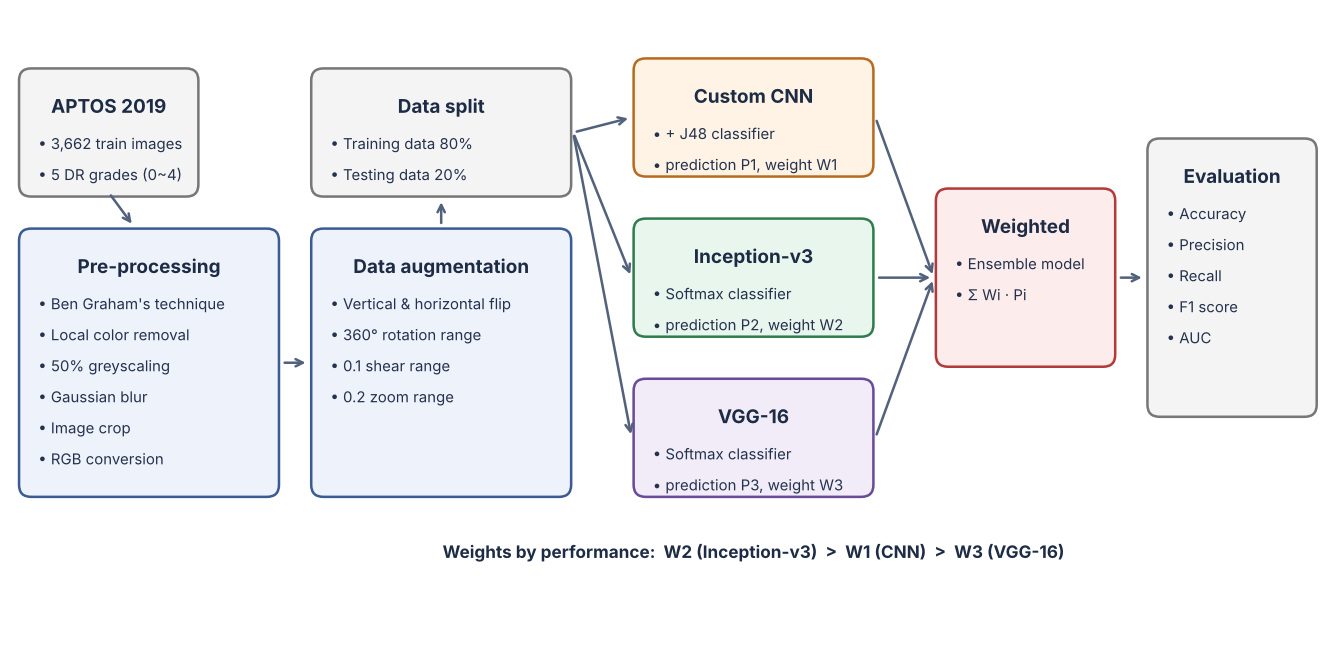

**전체 시스템 구성도** (책의 그림을 다시 그린 것)

| 단계 | 내용 |
|---|---|
| ① Pre-processing (전처리) | Ben Graham 기법(주변 픽셀의 가중 평균을 빼서 조명 차이 제거), 국소 색상 제거, 50% 회색조, Gaussian Blur, 이미지 크롭, RGB 변환 |
| ② Data augmentation (증강) | 상하·좌우 반전, 360° 회전, 전단 0.1, 확대·축소 0.2 |
| ③ Data split (분할) | 학습용 80%, 테스트용 20% |
| ④ 베이스 모델 3개 | 커스텀 CNN(+ J48 분류기) → 예측 P1, Inception-v3(Softmax) → 예측 P2, VGG-16(Softmax) → 예측 P3 |
| ⑤ 가중치 앙상블 | 각 예측에 가중치를 곱해 더함: W1·P1 + W2·P2 + W3·P3 |
| ⑥ 평가 | 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1 점수, AUC |

책의 그림에는 가중치를 정한 기준도 적혀 있습니다. **성능이 가장 좋은 Inception-v3에 가장 큰 가중치 W2, CNN에 중간 가중치 W1, VGG-16에 가장 작은 가중치 W3**를 주어 **W2 > W1 > W3**가 되도록 했습니다.

- **Inception-v3**: 복잡한 특징을 효과적으로 학습할 수 있는 고급 모델로, DR 분류에서 높은 정확도를 보임.
- **VGG16**: 간단하고 깊은 구조로 이미지 특징을 안정적으로 추출.
- **커스텀 CNN**: DR 데이터셋에 맞춤 설계된 모델로, 베이스 모델들의 성능을 보완함.

**(2) 커스텀 CNN 설계**

커스텀 CNN은 6개의 합성곱층과 2개의 완전 연결층으로 구성되어 있으며, 각 층은 ReLU 활성화 함수와 배치 정규화를 사용합니다. 이 모델은 망막 이미지의 미세한 병변 특징을 학습하도록 설계되었으며, 가중치를 J48 분류기에 전달하여 최종 예측을 수행합니다. 다음은 CNN의 주요 파라미터입니다.

| Layer name | Tensor size | Number of parameters |
|---|---|---|
| Input image | 227 × 227 × 3 | 0 |
| Conv2d_1 | 227 × 227 × 64 | 204,928 |
| maxpooling2d_1 | 114 × 114 × 64 | 0 |
| Conv2d_2 | 114 × 114 × 64 | 295,168 |
| maxpooling2d_2 | 57 × 57 × 64 | 0 |
| Conv2d_3 | 57 × 57 × 128 | 590,080 |
| maxpooling2d_3 | 29 × 29 × 128 | 0 |
| Conv2d_4 | 29 × 29 × 256 | 1,180,160 |
| maxpooling2d_4 | 15 × 15 × 256 | 0 |
| Conv2d_5 | 15 × 15 × 512 | 2,359,808 |
| maxpooling2d_5 | 8 × 8 × 512 | 0 |
| Conv2d_6 | 8 × 8 × 1024 | 525,312 |
| maxpooling2d_6 | 4 × 4 × 1024 | 0 |
| FC_1 | 1024 × 1 | 1,049,600 |
| FC_2 | 32 × 1 | 32,800 |

**참고 — 이 표와 Step 5∼7의 실제 코드는 구조가 다릅니다**

위 표는 논문에 실린 CNN 구조이고, 책의 코드(Step 5·6)에서 실제로 만드는 CNN은 다음처럼 다릅니다. 표와 코드를 비교하며 읽을 때 헷갈리지 않도록 정리해 둡니다.

| 구분 | 위 표 (논문) | Step 6 코드 |
|---|---|---|
| 합성곱층 개수 | 6개 (블록마다 1개) | 12개 (블록마다 2개 × 6블록) |
| 첫 합성곱층 필터 | 64개 | 32개 (3×3) |
| 크기 유지 방식 | 합성곱 후에도 크기 유지(227→227) | 크기가 조금씩 줄어듦(227→225→223) |
| 배치 정규화 | 사용한다고 설명 | 사용하지 않음 |
| 완전 연결층 | 1024 → 32 | 32 → 5(출력) |

또 (3)에서 말하는 "입력 크기 299×299"는 Inception-v3의 원래 입력 크기이고, Step 7 코드는 Inception-v3에도 **224×224**를 넣습니다. Keras의 사전 학습 모델은 `include_top=False`(마지막 분류층을 빼고 가져오기)로 쓰면 입력 크기를 바꿀 수 있어서(InceptionV3는 75×75 이상, VGG16은 32×32 이상) 오류는 나지 않습니다.

**(3) 가중치 기반 앙상블 학습**

세 개의 베이스 모델(Inception-v3, VGG16, 커스텀 CNN)의 출력을 가중치 기반 앙상블 모델로 통합합니다. 각 모델의 성능(정확도)에 따라 가중치를 부여하고, 다음 수식을 통해 최종 예측 값을 계산합니다.

$$
y_{\text{ensemble}} = \sum_{i=1}^{N} w_i \cdot \hat{y}_i
$$

여기에서 $w_i$는 각 베이스 모델의 가중치, $\hat{y}_i$는 개별 모델의 예측값을 나타냅니다.

> **수식 풀어 읽기**
>
> - $N$ = 합칠 모델의 개수 (여기서는 3)
> - $\hat{y}_i$ = $i$번째 모델이 내놓은 예측. 이 장에서는 "5단계 각각일 확률" 5개짜리 묶음입니다. 예: `[0.10, 0.05, 0.70, 0.10, 0.05]` → 중등도(2)일 확률 70%
> - $w_i$ = $i$번째 모델의 발언권(가중치). 보통 합이 1이 되게 정합니다.
> - $\sum$ = 모두 더하라는 기호
>
> 예를 들어 가중치를 Inception-v3 0.4, CNN 0.35, VGG16 0.25로 정했다면 최종 예측 = 0.4 × (Inception-v3 예측) + 0.35 × (CNN 예측) + 0.25 × (VGG16 예측)이고, 그중 확률이 가장 큰 단계를 답으로 고릅니다. 가중치를 모두 같게(각 1/3) 하면 **단순 평균 앙상블**이 되는데, Step 7의 책 코드가 실제로는 이 단순 평균(`Average()`)을 씁니다. 이 노트북에서는 Step 7 끝에 **가중치 앙상블 셀을 추가**해 두었습니다.

**(4) 훈련 과정 및 평가**

APTOS 2019 데이터셋은 모델 훈련과 성능 평가를 위해 80%는 훈련용으로, 나머지 20%는 테스트용으로 분리하여 사용합니다. 이 데이터셋은 다양한 조명 조건과 클래스 불균형 문제를 포함하고 있기 때문에, 데이터 품질을 향상시키고 학습 다양성을 확보하기 위해 데이터 전처리 및 증강 기법을 적용합니다. 전처리 과정에서는 Ben Graham 기법과 Gaussian Blur를 통해 이미지의 품질을 개선하고, 검은 배경을 제거하여 모델 입력에 적합하도록 크기를 조정합니다. 데이터 증강 기법으로는 회전, 확대, 반전 및 전단 변환을 적용하여 데이터셋을 확장하고 다양한 변형된 이미지를 추가함으로써 모델의 일반화 성능을 향상시킵니다.

훈련 과정에서는 Inception-v3, VGG16, 커스텀 CNN의 세 가지 베이스 모델을 활용하여 각각의 모델을 독립적으로 훈련합니다. 그런 다음, 이 모델들의 출력을 가중치 기반 앙상블 학습 기법을 사용해 통합하여 최종 결과를 도출합니다. 이 과정에서 각 모델의 성능에 따라 가중치를 부여하여 모델의 강점을 극대화하고 약점을 보완하는 효과를 얻습니다.

여기에서는 사용된 모든 방법론을 체계적으로 설명하여 DR 분류 모델의 설계와 구현 과정을 명확히 보여줍니다. 이 접근법은 조기 진단과 단계적 분류를 위한 정확하고 효율적인 시스템을 구축하는 데 기여합니다.

## Step 4. 실험 결과

여기에서는 연구에서 제안한 모델의 성능을 다양한 실험을 통해 평가하고, 다른 모델들과 비교하여 얻은 결과를 자세히 설명합니다. 이 과정은 DR(당뇨병성 망막병증) 진단에서 제안된 접근법의 유효성과 장점을 확인하는 데 중점을 둡니다.

### 1. 모델 성능 평가 방법

연구에서는 APTOS 2019 데이터셋을 활용하여 DR(당뇨병성 망막병증) 분류를 위한 딥러닝 모델들의 성능을 비교 분석했습니다. 이를 위해 DenseNet201, MobileNet, VGG16, ResNet50, Inception-v3, Xception, 그리고 커스텀 CNN을 포함한 총 7개의 모델을 훈련하고 성능을 평가했습니다. 각 모델의 성능은 다양한 평가 지표를 기반으로 비교되었습니다.

<strong>정확도(Accuracy)</strong>는 전체 예측 중 올바르게 분류된 비율을 의미하며, 모델의 전반적인 성능을 간단히 측정하는 지표입니다. <strong>정밀도(Precision)</strong>는 모델이 긍정 클래스로 예측한 값 중 실제로 맞는 비율로, 예측의 정확도를 나타냅니다. <strong>재현율(Recall)</strong>은 실제 긍정 클래스 중 모델이 올바르게 예측한 비율로, 민감도를 평가하는 데 유용합니다. **F1 스코어**는 정밀도와 재현율 간의 균형을 나타내는 지표로, 두 값을 조화롭게 평가하기 위해 사용됩니다. 마지막으로 <strong>AUC(Area Under Curve)</strong>는 ROC 곡선 아래 면적을 기반으로 계산되며, 모델의 분류 능력을 종합적으로 평가하는 데 중요한 지표입니다.

이러한 평가 지표를 사용하여 모델 간의 성능을 비교함으로써, 각 모델이 DR 분류 작업에서 얼마나 효과적인지 확인했습니다. 이를 통해 가장 뛰어난 성능을 보이는 모델을 선정하고, 이후 앙상블 학습을 통해 성능을 더욱 향상시킬 수 있었습니다.

> **참고 — 5단계 분류에서 정밀도·재현율은 어떻게 구하나?**
>
> 1장의 유방암 문제는 양성/악성 두 가지라 "긍정 클래스(악성)"가 분명했습니다. 2장은 정답이 **5가지**라 단계마다 "이 단계 vs 나머지"로 따로 계산한 뒤 평균을 냅니다. 각 지표의 공식과 혼동행렬(TP·TN·FP·FN) 읽는 법은 1장 Step 3의 **5. 성능 평가 방법**에 자세히 정리되어 있습니다.
>
> 의료 진단에서는 특히 **재현율**이 중요합니다. 재현율이 낮으면 실제로 병이 있는 환자를 "정상"으로 놓치게 되고, 그만큼 치료 시기를 놓칠 수 있기 때문입니다.

### 2. 베이스 모델 성능

평가 결과, Inception-v3, VGG16, 그리고 커스텀 CNN이 DR 분류에서 가장 우수한 성능을 보였습니다. Inception-v3는 93.08%의 정확도와 97.20%의 AUC를 기록하며 단일 모델 중 가장 뛰어난 성능을 보였습니다. 이 모델은 복잡한 데이터 패턴을 효과적으로 학습하고, 다양한 병변 특징을 정밀하게 탐지하는 능력을 입증했습니다.

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| Inception-v3 | 93.08 | 84.48 | 80.14 | 82.21 | 97.20 |
| CNN | 90.56 | 81.88 | 67.78 | 73.86 | 93.82 |
| VGG16 | 91.29 | 84.63 | 71.82 | 79.09 | 96.72 |
| **Proposed WAE** | **95.13** | **89.50** | **85.69** | **87.58** | **98.60** |

VGG16은 91.29%의 정확도와 96.72%의 AUC를 나타내며 안정적이고 신뢰할 수 있는 성능을 발휘했습니다. 이 모델은 구조가 단순하지만 깊은 층으로 구성되어 있어 DR 진단에서 중요한 이미지 특징을 잘 포착했습니다.

커스텀 CNN은 90.56%의 정확도와 93.82%의 AUC로 높은 예측력을 보여주었습니다. 특히, 이 모델은 DR 데이터셋의 특성에 맞게 설계되어 개별 모델로서 강력한 성능을 발휘하며, 다른 모델들과의 조합에서도 중요한 역할을 할 수 있음을 증명했습니다.

이 세 모델은 각각의 강점을 통해 DR 분류 작업에서 높은 성능을 보이며, 이후 가중치 기반 앙상블 학습에서 핵심적인 베이스 모델로 활용되었습니다. 이러한 결과는 DR 진단 모델의 설계와 발전 가능성을 보여줍니다.

> **표 읽는 팁**
>
> - **WAE** = Weighted Average Ensemble(가중치 평균 앙상블), 이 연구가 제안한 모델입니다.
> - 세 모델 모두 <strong>정확도는 90% 이상인데 재현율은 68∼80%</strong>로 훨씬 낮습니다. 데이터의 절반 가까이가 "정상"인 불균형 데이터라, 정상 사진만 잘 맞혀도 정확도는 높게 나오기 때문입니다. 불균형 데이터에서는 정확도 하나만 보지 말고 재현율·F1을 함께 봐야 하는 이유입니다.
> - CNN의 재현율(67.78)이 가장 낮다는 것은 "병이 있는 사진을 정상으로 놓치는 경우"가 셋 중 가장 많다는 뜻입니다. 앙상블로 합치자 재현율이 85.69까지 올라간 것이 이 연구의 핵심 성과입니다.

### 3. 가중치 기반 앙상블 모델 성능

이 연구의 핵심은 가중치 기반 앙상블 학습을 통해 DR(당뇨병성 망막병증) 진단 모델의 성능을 극대화한 점입니다. 가중치 기반 앙상블 학습은 각 베이스 모델(Inception-v3, VGG16, 커스텀 CNN)의 성능(정확도)을 기준으로 가중치를 부여하여 모델의 예측 결과를 결합하는 방식으로 작동합니다. 이를 통해 개별 모델이 가진 강점을 결합하고, 약점을 보완하여 최종적으로 더 나은 결과를 도출할 수 있습니다.

제안된 앙상블 모델은 **95.06%의 정확도**와 **98.10%의 AUC**를 달성하며, 개별 베이스 모델뿐만 아니라 기존 연구에서 제안된 다른 모델들보다 뛰어난 성능을 보여주었습니다. 이 결과는 DR 진단에서 높은 신뢰성과 정확성을 제공할 수 있는 모델을 설계했다는 점에서 의의가 있습니다.

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| WAE without pre-processing | 94.06 | 86.88 | 84.78 | 84.69 | 97.10 |
| WAE with pre-processing | 95.06 | 87.88 | 83.78 | 85.69 | 98.10 |

특히, 이 앙상블 모델은 DR의 다섯 가지 주요 단계(정상, 경증, 중등도, 중증, 증식성 DR)를 정확히 분류하는 데 있어 우수한 성능을 나타냈습니다. 이는 DR의 조기 진단 가능성을 높이고, 단계별로 적절한 치료 방안을 제시할 수 있는 기초를 제공합니다. 조기 진단은 환자의 시력을 보존하고, 진행성 DR의 심각성을 줄이는 데 중요한 역할을 하므로, 이 모델의 높은 정확도는 실제 의료 환경에서도 유용하게 활용될 가능성을 보여줍니다.

결론적으로, 이 연구는 가중치 기반 앙상블 학습을 통해 DR 진단의 정확도와 신뢰성을 향상시켰으며, DR 조기 진단 및 단계적 분류에서 큰 가능성을 입증한 중요한 사례로 평가될 수 있습니다.

**참고 — 책 안의 숫자가 서로 조금 다릅니다**

| 위치 | 제안 모델 정확도 | 제안 모델 AUC |
|---|---|---|
| 2번 표 (Proposed WAE) | 95.13 | 98.60 |
| 3번 본문·표 (WAE with pre-processing), Step 1 소개 | 95.06 | 98.10 |

같은 "제안 모델"인데 표마다 값이 다릅니다. 실험 조건(전처리 포함 여부, 실행 회차)이 달랐던 것으로 보이며, 본문에서 대표로 인용하는 값은 <strong>95.06% / 98.10%</strong>입니다. 또 3번 표에서 전처리를 하면 정확도·정밀도·F1·AUC는 올랐지만 **재현율은 84.78 → 83.78로 오히려 1%p 떨어졌습니다.** 전처리가 모든 지표를 올려 주는 것은 아니라는 점도 함께 읽어 두면 좋습니다.

### 4. 전처리와 데이터 증강의 효과

전처리와 데이터 증강은 DR 진단 모델의 성능 향상에 중요한 기여를 했습니다. 연구에서는 Ben Graham 기법과 Gaussian Blur와 같은 전처리 기술, 그리고 회전, 반전, 확대, 전단 변환 등의 데이터 증강 기법이 모델 성능에 미치는 영향을 분석했습니다.

전처리 기법의 적용은 이미지의 품질을 개선하여 조명 조건과 노이즈로 인한 불규칙성을 줄이고, 모델이 DR과 관련된 주요 특징을 더 정확히 학습할 수 있도록 도왔습니다. 예를 들어, Ben Graham 기법은 이미지의 밝기와 대비를 조정하여 조명으로 인한 영향을 최소화하며, Gaussian Blur는 불필요한 세부 정보를 제거하여 모델의 학습 집중도를 높였습니다.

데이터 증강 기법은 데이터셋의 다양성을 증가시켜 클래스 간 불균형 문제를 완화하는 데 중요한 역할을 했습니다. 회전, 확대, 반전, 전단 변환과 같은 변형은 데이터셋을 확장하여 모델이 다양한 시각적 변화를 학습할 수 있도록 하였습니다. 이는 모델의 일반화 성능을 향상시켜 새로운 데이터에서도 높은 정확도를 유지할 수 있게 합니다.

이러한 전처리와 데이터 증강 기법이 적용된 결과, 모델의 정확도와 AUC(ROC 아래 면적)가 크게 향상되었습니다. 데이터 품질의 개선과 불균형 문제 해결은 모델이 데이터를 효과적으로 학습할 수 있는 기반을 마련했으며, DR 진단에서의 성능을 극대화하는 데 크게 기여했습니다. 이를 통해 연구는 데이터 준비 과정의 중요성을 입증하며, DR 진단 모델 개발의 필수적인 단계로 강조했습니다.

### 5. 결과 비교와 의의

제안된 모델은 기존 연구에서 사용된 단일 모델(예: ResNet50, Xception)을 능가하는 성능을 기록하며 DR(당뇨병성 망막병증) 진단에서의 효과성을 입증했습니다. 특히, 가중치 기반 앙상블 학습은 개별 모델들의 강점을 결합함으로써 단일 모델이 도달할 수 없는 수준의 성능을 극대화하는 데 성공했습니다. 이 접근법은 Inception-v3, VGG16, 커스텀 CNN과 같은 우수한 베이스 모델들의 예측 결과를 가중치를 통해 조합하여 더 정밀한 예측을 가능하게 했습니다.

제안된 앙상블 모델은 높은 정확도(95.06%)와 AUC(98.10%)를 달성하며, DR의 다섯 가지 단계(정상, 경증, 중등도, 중증, 증식성 DR)를 구분하는 데 있어 특히 강력한 성능을 보여주었습니다. 이러한 결과는 조기 진단과 단계별 분류의 가능성을 높이며, DR 진단에 필요한 신뢰성과 정확성을 제공할 수 있는 중요한 진단 도구로 평가됩니다.

이 모델은 의료 환경에서도 실질적으로 활용 가능성이 높습니다. 예를 들어, 조기 진단이 필요한 상황에서 정확한 분류를 통해 환자에게 적시에 치료를 제공하고, DR 진행을 예방하거나 관리할 수 있도록 돕습니다. 또한, 의료 자원이 제한된 지역에서도 자동화된 진단 도구로 활용될 수 있어, 의료 접근성을 향상시키는 데 기여할 수 있습니다.

결론적으로, 이 연구는 DR 진단에 대한 새로운 접근법을 제시하며, 의료 영상 분석 분야에서 가중치 기반 앙상블 학습의 강력한 잠재력을 보여주었습니다. 제안된 방법은 DR뿐만 아니라 다른 의료 영상 데이터에도 확장 가능하며, 다양한 임상 응용에서 활용될 수 있을 것으로 기대됩니다.

### 6. 결론

이 연구는 DR(당뇨병성 망막병증) 진단에서 높은 정확도와 신뢰성을 제공하는 효과적인 모델을 제시하며, 조기 발견과 단계별 치료의 가능성을 제시합니다. 제안된 가중치 기반 앙상블 모델은 Inception-v3, VGG16, 커스텀 CNN의 강점을 결합하여 단일 모델을 능가하는 성능을 발휘했습니다. 이를 통해 DR의 다섯 가지 주요 단계를 정확히 분류하고, 조기 진단 및 환자 맞춤형 치료 계획 수립에 중요한 기초를 마련했습니다.

또한, 데이터 전처리와 증강 기법을 활용하여 데이터 품질을 향상시키고 클래스 간 불균형 문제를 해결함으로써 모델의 학습 효율성과 일반화 성능을 극대화했습니다. 이러한 접근법은 DR 진단에 필요한 정밀성과 신뢰성을 확보하며, 실제 의료 환경에서도 유용하게 적용될 가능성을 보여줍니다.

더 나아가, 이 연구에서 제안된 모델은 DR 진단에 국한되지 않고, 다른 의료 이미지 분석 문제에도 적용할 수 있는 잠재력을 가지고 있습니다. 예를 들어, 암 진단, 심장 질환 탐지, 피부 병변 분석 등 다양한 분야에서 이 모델의 강력한 성능과 유연성을 활용할 수 있습니다.

결론적으로, 이 연구는 DR 진단의 정확도와 신뢰성을 높이는 데 기여하며, 자동화된 의료 진단 시스템 개발에 있어 중요한 진전을 이루었습니다. 제안된 접근법은 의료 영상 분석의 발전 가능성을 제시하며, 향후 다양한 임상 및 연구 환경에서 활용될 수 있을 것으로 기대됩니다.

## Step 5. 전체 코드 개요

이 코드는 APTOS 2019 데이터셋을 사용하여 당뇨병성 망막병증(DR) 진단을 위한 딥러닝 모델과 J48 결정 트리 기반 앙상블 학습을 구현한 워크플로를 보여줍니다. 이 코드는 데이터 전처리, 증강, CNN 모델 설계 및 학습, 그리고 J48 결정 트리를 이용한 최종 분류로 구성되어 있습니다.

> **실행 전 준비 — 실행 설정 셀**
>
> 책 코드는 데이터 경로 `'D:/Dataset/...'`가 코드 곳곳에 직접 적혀 있어서, 데이터를 다른 곳에 두면 여러 셀을 하나하나 고쳐야 합니다. 이 노트북에서는 아래 **실행 설정 셀**을 추가하고, 이후 코드의 경로를 모두 `f'{DATA_DIR}/...'` 형태로 바꿨습니다. Kaggle에서 실행하면 데이터 위치를 자동으로 찾고, 내 PC에서 실행하면 `C:/Dataset`(데이터)과 `C:/testRun`(모델 저장)을 씁니다(책은 `D:/Dataset`, `D:/testRun`).
>
> 이 셀은 처음 실행할 때 **사진 3,662장을 긴 변 512픽셀로 줄여 따로 저장**합니다. APTOS 원본 사진은 한 장이 가로 2,000∼4,000픽셀이라, 원래 코드대로면 에포크마다 이 큰 사진을 다시 읽느라 Kaggle GPU에서도 **1에포크에 약 9분**(실측 548초)이 걸렸습니다. 모델에 들어가는 사진은 어차피 227×227·224×224로 줄어들기 때문에, 미리 줄여 두어도 결과에는 거의 영향이 없고 학습은 몇 배 빨라집니다. 줄인 사진은 Kaggle에서는 실행이 끝나면 지워지는 임시 폴더(`/tmp`)에 저장됩니다.
>
> 학습 에포크 수도 이 셀의 `EPOCHS` 하나로 모았습니다. **책의 원래 값은 Step 5가 50, Step 6·7이 100**이지만, 이 노트북은 Kaggle의 12시간 실행 제한 안에 끝나도록 **30**으로 실행했습니다. 시간이 넉넉하면 이 숫자만 바꾸면 됩니다. 전이 학습 모델(InceptionV3·VGG16)은 이미 배운 특징을 가져오기 때문에 보통 초반 10∼20에포크 안에 성능이 거의 다 올라오므로, 에포크를 줄여도 손해가 크지 않습니다.
>
> `f'{DATA_DIR}/train.csv'`는 **f-문자열**이라는 문법으로, 중괄호 `{}` 안의 변수 값을 그 자리에 끼워 넣습니다. `DATA_DIR = 'D:/Dataset'`이면 `'D:/Dataset/train.csv'`가 됩니다.

In [1]:
# [추가] 실행 설정 — 에포크 수, 데이터 경로, 모델 저장 경로를 이 셀 한 곳에서 관리


import os
import glob

# ===== Epochs =====
# EPOCHS: 이 노트북의 모든 학습(fit)에 쓰는 에포크 수
# 책 원래 값: Step 5는 epochs=50, Step 6·7은 epochs=100
# Kaggle은 한 번 실행이 최대 12시간이라, 학습 5번(Step 5 CNN, Step 6 CNN, InceptionV3, VGG16, 앙상블)이 그 안에 끝나도록 줄여서 사용
EPOCHS = 30

# ===== Paths =====
# glob('/kaggle/input/**/train.csv', recursive=True): /kaggle/input 아래 모든 하위 폴더를 뒤져 train.csv 경로를 찾음
# 그중 옆에 train_images 폴더가 있는 것만 고름 (다른 데이터셋의 train.csv와 헷갈리지 않도록)
found = [p for p in glob.glob('/kaggle/input/**/train.csv', recursive=True)
         if os.path.isdir(os.path.join(os.path.dirname(p), 'train_images'))]
# DATA_DIR: Kaggle이면 찾은 폴더, 아니면(내 PC) C:/Dataset (책은 D:/Dataset)
DATA_DIR = os.path.dirname(found[0]) if found else 'C:/Dataset'
# SAVE_DIR: Kaggle에서 파일을 저장할 수 있는 곳은 /kaggle/working 뿐. 내 PC면 C:/testRun (책은 D:/testRun)
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else 'C:/testRun'

# os.makedirs(..., exist_ok=True): 저장 폴더가 없으면 새로 만들고, 이미 있으면 그냥 넘어감
os.makedirs(SAVE_DIR, exist_ok=True)

# ===== Image cache =====
# 원본 사진은 한 장이 가로 2,000~4,000픽셀이라, 학습 시간 대부분이 에포크마다 큰 사진을 다시 읽는 데 쓰임
# 처음 한 번만 긴 변 512픽셀로 줄여 따로 저장해 두고, 이후에는 이 작은 사진을 읽게 함 (모델 입력은 어차피 227·224)
import cv2
import shutil
from concurrent.futures import ThreadPoolExecutor

# CACHE_DIR: 줄인 사진을 둘 곳. Kaggle은 /tmp(실행이 끝나면 지워지는 임시 폴더), 내 PC는 C:/Dataset_512
CACHE_DIR = '/tmp/aptos_512' if found else 'C:/Dataset_512'
SRC_DIR = DATA_DIR

def shrink_image(name):
    dst = os.path.join(CACHE_DIR, 'train_images', name)
    # 이미 줄여 둔 사진이면 건너뜀 → 이 셀을 다시 실행해도(Step 6·7) 금방 끝남
    if os.path.exists(dst):
        return
    img = cv2.imread(os.path.join(SRC_DIR, 'train_images', name))
    h, w = img.shape[:2]
    # scale: 긴 변이 512가 되도록 줄이는 비율 (가로세로 비율은 그대로 유지)
    scale = 512 / max(h, w)
    if scale < 1:
        # INTER_AREA: 사진을 줄일 때 화질 손실이 가장 적은 방식
        img = cv2.resize(img, (round(w * scale), round(h * scale)), interpolation=cv2.INTER_AREA)
    cv2.imwrite(dst, img)

if os.path.exists(f'{SRC_DIR}/train.csv'):
    os.makedirs(f'{CACHE_DIR}/train_images', exist_ok=True)
    # train.csv도 같은 폴더에 복사해 두어, 아래 코드의 f'{DATA_DIR}/...' 경로를 그대로 쓸 수 있게 함
    shutil.copy(f'{SRC_DIR}/train.csv', f'{CACHE_DIR}/train.csv')
    names = os.listdir(f'{SRC_DIR}/train_images')
    # ThreadPoolExecutor: CPU 코어 수만큼 동시에 사진을 줄여 시간을 아낌
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
        list(ex.map(shrink_image, names))
    # 이후 모든 코드는 줄인 사진 폴더를 데이터 폴더로 사용
    DATA_DIR = CACHE_DIR
    print('줄인 사진 수:', len(os.listdir(f'{CACHE_DIR}/train_images')))
print('EPOCHS  :', EPOCHS)
print('DATA_DIR:', DATA_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('원본 위치:', SRC_DIR)
# os.path.exists(): 그 경로에 파일이 실제로 있는지 True/False로 알려 줌
print('train.csv 있음:', os.path.exists(f'{DATA_DIR}/train.csv'))
print('train_images 폴더 있음:', os.path.exists(f'{DATA_DIR}/train_images'))


# → Kaggle에서는 데이터 위치를 자동으로 찾고, 내 PC에서는 C:/Dataset을 쓰도록 하겠다
# → 처음 실행할 때 사진 3,662장을 긴 변 512픽셀로 줄여 두고(Kaggle 기준 몇 분), 이후 학습은 작은 사진을 읽어 훨씬 빠르게 하겠다
# → 모든 학습의 에포크 수를 EPOCHS 하나로 관리해, 시간이 넉넉하면 이 숫자만 100으로 바꾸면 되게 하겠다
# → 마지막 두 줄이 모두 True가 나와야 아래 셀들이 정상적으로 실행된다

줄인 사진 수: 3662
EPOCHS  : 30
DATA_DIR: /tmp/aptos_512
SAVE_DIR: /kaggle/working
원본 위치: /kaggle/input/competitions/aptos2019-blindness-detection
train.csv 있음: True
train_images 폴더 있음: True


**결과 해석 — 실행 설정 셀**

| 출력 | 뜻 |
|---|---|
| `줄인 사진 수: 3662` | `train_images`의 사진 3,662장을 모두 긴 변 512픽셀로 줄여 `/tmp/aptos_512`에 저장했습니다. 원본 개수와 같으므로 빠진 사진이 없습니다. |
| `EPOCHS : 30` | 이후 모든 `fit`이 30에포크 동안 학습합니다. |
| `DATA_DIR: /tmp/aptos_512` | 이후 코드는 원본 대신 **줄인 사진 폴더**를 읽습니다. |
| `원본 위치: /kaggle/input/competitions/...` | 데이터 경로에 `competitions/` 폴더가 하나 더 있어서, 경로를 직접 적지 않고 자동으로 찾게 한 것이 효과가 있었습니다. |
| `train.csv 있음: True` 두 줄 | 데이터가 노트북에 제대로 연결되었다는 확인입니다. 하나라도 `False`면 Kaggle 오른쪽 패널의 **Add Input**에서 대회 데이터를 추가해야 합니다. |

### 1. 데이터 준비 및 전처리

데이터 준비 및 전처리는 모델의 학습 성능을 높이고 일반화 능력을 강화하기 위해 중요한 단계입니다. 이 과정에서는 APTOS 2019 데이터셋의 `train.csv` 파일을 사용하여 이미지와 라벨 데이터를 읽어오고, 이미지 품질 개선과 데이터 증강을 통해 학습 데이터의 품질과 다양성을 향상시킵니다. 이를 통해 DR(당뇨병성 망막병증) 진단 모델이 다양한 환경에서 높은 성능을 발휘하도록 돕습니다.

먼저, `train.csv` 파일을 읽어 각 이미지의 ID와 해당 라벨(진단 단계)을 데이터프레임 형태로 로드합니다. 이미지 파일의 ID는 확장자를 추가하여 파일 경로로 변환되고, 라벨은 범주형 데이터로 처리됩니다.

다음으로, Ben Graham 기법과 Gaussian Blur를 사용하여 이미지를 전처리합니다. Ben Graham 기법은 망막 이미지를 밝기와 대비를 조정하여 조명 조건의 영향을 줄이고, 이미지의 핵심 특징을 강조합니다. 이 과정에서는 불필요한 배경을 제거하고 이미지를 네트워크 입력 크기로 조정합니다. Gaussian Blur는 이미지의 노이즈를 줄이고 부드럽게 만들어 모델이 더 일반화된 특징을 학습할 수 있도록 돕습니다. 이를 통해 이미지 품질이 개선되어 학습 데이터의 일관성이 향상됩니다.

추가적으로, 데이터 증강(Data Augmentation)을 통해 데이터셋의 다양성을 증가시킵니다. 증강 기법으로는 회전, 확대, 수평 및 수직 반전, 그리고 전단 변환(Shear Transform)이 사용됩니다. 회전과 확대는 다양한 각도와 크기로 이미지를 변형하여 모델이 데이터의 다양한 시각적 변화를 학습하도록 유도합니다. 반전은 좌우 및 상하 대칭적인 변화를 추가하여 데이터의 패턴 다양성을 높입니다. 전단 변환은 이미지를 기울임으로써 비정형적인 변화에도 강건한 모델을 만들도록 돕습니다.

아래는 이러한 데이터 준비 및 전처리 과정을 구현한 코드입니다.

In [2]:
import pandas as pd
import cv2
import numpy as np
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator
#        → Keras 3(TensorFlow 2.16 이상)에서는 이 경로에 ImageDataGenerator가 없어 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#데이터 로드
train = pd.read_csv(f'{DATA_DIR}/train.csv')
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")
train['diagnosis'] = train['diagnosis'].astype('str')

train.head()


# → train.csv를 읽어, 파일 이름(id_code)에 .png를 붙이고 정답(diagnosis)을 글자로 바꿔 두겠다
# → 정답을 글자('0'~'4')로 바꾸는 이유: ImageDataGenerator의 class_mode="categorical"은 정답 열이 문자열이어야 함

,id_code,diagnosis
0,000c1434d8d7.png,2
1,001639a390f0.png,4
2,0024cdab0c1e.png,1
3,002c21358ce6.png,0
4,005b95c28852.png,0


In [3]:
#이미지 전처리 함수
IMG_SIZE = 227

def crop_image_from_gray(img, tol=7):
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol
    if mask.any():
        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
        img = np.stack([img1, img2, img3], axis=-1)
    return img

def load_ben_color(image, sigmaX=10):
    image = crop_image_from_gray(image).astype('uint8')
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    return image.astype('float32') / 255.


# → 회색으로 바꿨을 때 밝기가 7보다 큰(검은 배경이 아닌) 행·열만 남겨 망막 부분만 잘라내겠다
# → 잘라낸 사진을 227×227로 맞추고, Ben Graham 기법(원본 − 흐린 사진)으로 조명 차이를 없앤 뒤 0~1로 나누겠다

**코드 설명 — `crop_image_from_gray`가 검은 배경을 잘라내는 방법**

| 코드 | 하는 일 |
|---|---|
| `cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)` | 컬러(RGB 3채널) 사진을 밝기 하나짜리 회색 사진으로 바꿉니다. 배경인지 아닌지는 밝기만 보면 알 수 있기 때문입니다. |
| `mask = gray_img > tol` | 밝기가 `tol`(7)보다 큰 픽셀은 `True`, 거의 검은 픽셀은 `False`인 표(마스크)를 만듭니다. 0∼255 중 7 이하는 사실상 검은색입니다. |
| `mask.any(1)` | 행마다 "이 줄에 `True`가 하나라도 있나?" → 망막이 걸쳐 있는 **행** 목록 |
| `mask.any(0)` | 열마다 같은 질문 → 망막이 걸쳐 있는 **열** 목록 |
| `np.ix_(행목록, 열목록)` | 두 목록이 겹치는 사각형 영역을 골라내는 NumPy 도구입니다. 결과적으로 망막을 감싸는 가장 작은 사각형만 남습니다. |
| `img[:, :, 0]`, `[:, :, 1]`, `[:, :, 2]` | 빨강·초록·파랑 채널을 하나씩 같은 사각형으로 잘라 냅니다. |
| `np.stack([...], axis=-1)` | 잘라 낸 세 채널을 다시 하나의 컬러 사진으로 쌓습니다. |
| `if mask.any():` | 사진 전체가 검은 경우(밝은 픽셀이 하나도 없음)에는 자를 영역이 없으므로 원본을 그대로 돌려줍니다. |

In [4]:
#데이터 증강 설정
train_datagen = ImageDataGenerator(
    # [개선] 기존: rescale=1./255 → load_ben_color가 이미 255로 나눠 0~1로 만든 값을 한 번 더 255로 나눔
    #        (픽셀 값이 0~0.004로 쪼그라듦). 아래 개선 사항 참고
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=360,
    zoom_range=0.2,
    shear_range=0.1,
    preprocessing_function=load_ben_color
)

# [추가] 검증용: 증강(회전·반전 등) 없이 전처리만 하는 생성기
# validation_split=0.2를 똑같이 줘야 학습용과 겹치지 않는 같은 20%를 검증용으로 가져옴
valid_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=load_ben_color
)


# → 학습용은 사진을 무작위로 돌리고 뒤집어 다양성을 늘리고, 검증용은 원래 모습 그대로(전처리만) 쓰겠다

In [5]:
#데이터 로더 생성
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="categorical",
    subset='training'
)

# [개선] 기존: train_datagen.flow_from_dataframe(...) → 검증 데이터에도 회전·반전 증강이 적용됨
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="categorical",
    subset='validation'
)


# → 표(train)에 적힌 파일 이름으로 사진을 찾아 16장씩 묶어서 꺼내 주는 "데이터 로더"를 학습용·검증용으로 만들겠다
# → 실행하면 "Found 2930 validated image filenames belonging to 5 classes."처럼 찾은 사진 수가 출력된다(3,662장의 80%/20%)

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


이 코드는 데이터 로드와 전처리, 증강 과정을 포함하며, 학습 및 검증 데이터셋을 생성합니다. 이를 통해 모델이 다양한 데이터 조건에서 학습할 수 있도록 준비합니다.

> **개선 사항 — 픽셀 값을 255로 두 번 나누던 문제**
>
> `ImageDataGenerator`는 사진 한 장을 꺼낼 때 다음 순서로 처리합니다.
>
> 1. 사진 읽기 (픽셀 값 0∼255)
> 2. 증강 (회전·반전·확대·기울이기)
> 3. `preprocessing_function` 실행 → 책 코드에서는 `load_ben_color`가 **마지막에 `/ 255.`로 나눠 0∼1로 만듦**
> 4. `rescale` 적용 → 책 코드의 `rescale=1./255`가 **한 번 더 255로 나눔**
>
> 그 결과 모델에 들어가는 값이 0∼1이 아니라 **0∼0.004** 정도로 아주 작아집니다. 모든 사진이 거의 똑같이 새까만 숫자 덩어리가 되어 학습이 매우 느려지거나 잘 되지 않습니다. 오류 메시지는 나지 않아서 알아채기 어려운 문제입니다. 이 노트북에서는 `rescale`을 빼고, 0∼1 정규화는 `load_ben_color` 한 곳에서만 하도록 했습니다. Step 6·7의 생성기도 같은 이유로 고쳤습니다.
>
> **개선 사항 — 검증 데이터에도 증강이 걸리던 문제**
>
> 책의 다음 단락(2. 데이터 로더 생성)은 "`valid_generator`는 동일한 전처리를 적용하되 증강은 수행하지 않습니다"라고 설명하지만, 원래 코드는 검증용도 증강 설정이 들어 있는 `train_datagen`으로 만들어서 **검증 사진도 매번 무작위로 돌아가고 뒤집혔습니다.** 검증은 "처음 보는 실제 사진에서 얼마나 잘 맞히나"를 재는 시험이므로, 매번 시험지가 바뀌면 점수가 흔들리고 공정한 비교가 어렵습니다. 그래서 증강 없이 전처리만 하는 `valid_datagen`을 따로 만들었습니다.
>
> 두 생성기에 `validation_split=0.2`를 똑같이 주면, Keras는 같은 규칙(표의 순서 기준)으로 나누기 때문에 학습용 80%와 검증용 20%가 **서로 겹치지 않습니다.**

**결과 해석 — 데이터 로더**

- `Found 2930 ... belonging to 5 classes`: 학습용 사진 2,930장, 진단 단계 5개(0∼4)입니다.
- `Found 732 ...`: 검증용 사진 732장입니다. 2,930 + 732 = 3,662장이므로 `validation_split=0.2`(20%)대로 나뉘었습니다.
- `ImageDataGenerator`의 `validation_split`은 무작위가 아니라 <strong>표의 앞쪽 20%</strong>를 검증용으로 떼어 냅니다. 그래서 몇 번을 다시 실행해도 같은 732장이 검증 데이터가 됩니다(모델끼리 공정하게 비교할 수 있는 이유).

### 2. 데이터 로더 생성

데이터 로더 생성 과정에서는 딥러닝 모델 학습에 필요한 데이터를 효율적으로 로드하고, 실시간으로 전처리 및 데이터 증강을 수행할 수 있도록 설정합니다. 이를 위해 Keras의 `ImageDataGenerator`를 사용하여 학습용(train)과 검증용(validation) 데이터셋을 준비합니다. 이 과정은 데이터 품질과 다양성을 유지하면서 학습 과정을 최적화하는 데 중요한 역할을 합니다.

먼저, APTOS 2019 데이터셋의 `train.csv` 파일을 읽어들여 데이터프레임 형태로 저장합니다. 여기에는 이미지 파일 이름(`id_code`)과 해당 라벨(`diagnosis`) 정보가 포함됩니다. 이미지 파일 이름에는 확장자를 추가하여 실제 파일 경로로 변환하며, 라벨은 모델 학습을 위해 범주형 데이터로 처리합니다.

`ImageDataGenerator`는 데이터 증강과 정규화를 통합적으로 수행합니다. 학습용 데이터와 검증용 데이터를 구분하기 위해 `validation_split` 매개변수를 사용합니다. 증강 기법으로는 회전, 확대, 반전, 전단 변환과 같은 다양한 변형을 적용하여 데이터의 다양성을 증가시킵니다. 또한, `load_ben_color`와 같은 사용자 정의 전처리 함수를 사용하여 이미지 품질을 개선합니다. 학습용 데이터는 `subset="training"`으로, 검증용 데이터는 `subset="validation"`으로 설정하여 나눕니다.

아래 코드는 데이터 로더를 생성하는 과정을 보여줍니다.

In [6]:
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import cv2

# 이미지 크기와 배치 크기 설정
IMG_SIZE = 227
BATCH_SIZE = 16

#데이터프레임 로드
train = pd.read_csv(f'{DATA_DIR}/train.csv')
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")  # 파일 확장자 추가
train['diagnosis'] = train['diagnosis'].astype('str')  # 라벨을 문자열로 변환


# → 앞 셀과 같은 방법으로 표를 다시 읽고, 이미지 크기(227)와 배치 크기(16)를 변수로 정해 두겠다

In [7]:
#사용자 정의 전처리 함수 (Ben Graham 기법 포함)
def load_ben_color(image, sigmaX=10):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = gray_img > 7
    if mask.any():
        image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    return image.astype('float32') / 255.


# → 사진이 완전히 검지 않다면 Ben Graham 기법을 적용하고, 227×227로 맞춘 뒤 0~1로 나누겠다
# → 1번의 함수와 달리 검은 배경을 잘라내지(crop) 않는 간단한 버전이다

**참고 — 1번과 2번의 `load_ben_color`는 다른 함수입니다**

책의 1번과 2번 코드에 같은 이름의 함수가 두 번 나오지만 내용이 다릅니다. 파이썬은 **나중에 정의한 함수로 덮어쓰므로**, 이 셀을 실행한 뒤부터는 아래 2번 버전이 쓰입니다.

| 구분 | 1번 버전 | 2번 버전 |
|---|---|---|
| 검은 배경 잘라내기 | `crop_image_from_gray`로 잘라냄 | 하지 않음 (`mask`는 "사진이 완전히 검은지" 확인에만 사용) |
| 색 순서 | RGB 그대로 | RGB → BGR로 바꿈 |
| 순서 | 자르기 → 크기 조정 → Ben Graham | Ben Graham → 크기 조정 |

`cv2.COLOR_RGB2BGR`: OpenCV(cv2)는 색을 **파랑·초록·빨강(BGR)** 순서로 다루고, Keras는 **빨강·초록·파랑(RGB)** 순서로 사진을 읽습니다. 순서를 바꿔도 학습·평가에 쓰는 모든 사진에 똑같이 적용되므로 결과가 틀리지는 않습니다.

In [8]:
# ImageDataGenerator로 데이터 증강 및 전처리 설정
train_datagen = ImageDataGenerator(
    # [개선] 기존: rescale=1./255 → load_ben_color에서 이미 0~1로 만들었으므로 제거 (1번의 개선 사항 참고)
    validation_split=0.2,  #학습/검증 데이터 분리
    horizontal_flip=True,  # 좌우 반전
    vertical_flip=True,  # 상하 반전
    rotation_range=360,  # 0~360도 무작위 회전
    zoom_range=0.2,  # 80~120% 무작위 확대·축소
    shear_range=0.1,  # 전단 변환(기울이기)
    preprocessing_function=load_ben_color  # 사용자 정의 전처리 함수
)

# [추가] 검증용: 증강 없이 전처리만 (아래 설명대로 "증강은 수행하지 않도록" 만들기 위해)
valid_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=load_ben_color
)


# → 학습용 생성기에는 증강 6가지와 전처리를, 검증용 생성기에는 전처리만 걸어 두겠다

In [9]:
#학습 데이터 로더 생성
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",  # 이미지 파일 이름 열
    y_col="diagnosis",  # 라벨(정답) 열
    target_size=(IMG_SIZE, IMG_SIZE),  # 이미지 크기 조정
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # 다중 클래스 분류(원-핫 인코딩)
    subset='training'
)

#검증 데이터 로더 생성
# [개선] 기존: train_datagen.flow_from_dataframe(...) → valid_datagen으로 바꿔 증강이 걸리지 않게 함
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",  # 이미지 파일 이름 열
    y_col="diagnosis",  # 라벨(정답) 열
    target_size=(IMG_SIZE, IMG_SIZE),  # 이미지 크기 조정
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # 다중 클래스 분류(원-핫 인코딩)
    subset='validation'
)


# → 표에 적힌 파일 이름으로 사진을 찾아, 학습용(80%)과 검증용(20%)을 16장씩 꺼내 주는 로더를 만들겠다

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


위 코드는 학습용 및 검증용 데이터 로더를 각각 생성합니다. `train_generator`는 학습 데이터에 실시간으로 증강과 전처리를 적용하며, `valid_generator`는 동일한 전처리를 적용하되 증강은 수행하지 않습니다. 이러한 데이터 로더는 모델 학습을 효율적으로 지원하고, 데이터 품질을 유지하며, 모델이 다양한 데이터 변화를 학습하도록 돕습니다. 이를 통해 학습 과정에서 일반화 성능을 높이고 과적합을 방지할 수 있습니다.

> **용어 풀이 — `class_mode="categorical"`과 원-핫 인코딩**
>
> 정답이 `'2'`(중등도)인 사진이라면, 생성기는 정답을 숫자 하나가 아니라 **5칸짜리 벡터** `[0, 0, 1, 0, 0]`으로 바꿔서 줍니다. 해당 단계 칸만 1이고 나머지는 0이라서 **원-핫(one-hot, 하나만 켜짐) 인코딩**이라고 부릅니다. 모델의 마지막 층도 5개의 확률을 내놓으므로, 두 벡터를 칸끼리 비교해서 오차를 계산할 수 있습니다. 이때 쓰는 손실 함수가 아래 4번의 `categorical_crossentropy`입니다.

### 3. CNN 모델 설계

CNN 모델 설계는 당뇨병성 망막병증(DR) 진단을 위한 핵심 단계로, 이미지를 처리하고 주요 특징을 학습하여 분류를 수행하는 딥러닝 아키텍처를 정의합니다. 설계된 모델(`model0`)은 합성곱층(Conv2D), 풀링층(MaxPooling2D), 그리고 완전 연결층(Dense)을 포함하여 DR의 다섯 가지 진단 단계를 분류하도록 구성됩니다. 출력층에서는 소프트맥스(Softmax) 활성화 함수를 사용해 다중 클래스 분류를 수행합니다.

- **합성곱층(Conv2D)**: 합성곱층은 이미지에서 특징을 추출하는 역할을 합니다. 필터의 크기와 개수를 조정하여 이미지의 저차원부터 고차원 특징을 학습합니다. 초기 층에서는 간단한 패턴을 학습하고, 깊은 층으로 갈수록 복잡한 패턴을 학습하도록 설계되었습니다. 각 합성곱층에는 ReLU 활성화 함수가 적용되어 비선형성을 추가합니다.
- **풀링층(MaxPooling2D)**: 풀링층은 공간적 크기를 줄여 계산 비용을 절감하고, 중요한 특징을 강조하면서 과적합을 방지하는 역할을 합니다. 합성곱층 뒤에 배치되어 특징 맵의 크기를 감소시키면서 중요한 정보를 유지합니다.
- **완전 연결층(Dense)**: 특징 맵을 펼친(flatten) 후, 완전 연결층에서 고차원 특징을 학습하고, 출력층에서 각 클래스에 대한 확률을 계산합니다. 마지막 출력층은 DR의 5가지 진단 단계(정상, 경증, 중등도, 중증, 증식성 DR)를 나타내며, 소프트맥스 활성화 함수를 사용하여 각 클래스에 대한 확률 분포를 반환합니다.

아래는 이 모델 설계를 구현한 코드입니다.

In [10]:
from tensorflow.keras.models import Sequential
# [개선] Input 추가: 모델의 입력 크기를 맨 앞에 따로 선언 (Keras 3 권장 방식)
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# CNN 모델 설계
model0 = Sequential()

# [개선] 기존: Conv2D(..., input_shape=(227, 227, 3)) → Keras 3에서 경고(UserWarning)가 출력됨
model0.add(Input(shape=(227, 227, 3)))

#첫 번째 합성곱 블록
model0.add(Conv2D(32, (3, 3), activation='relu'))
model0.add(Conv2D(32, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

# 두 번째 합성곱 블록
model0.add(Conv2D(64, (5, 5), activation='relu'))
model0.add(Conv2D(64, (5, 5), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

#세 번째 합성곱 블록
model0.add(Conv2D(128, (5, 5), activation='relu'))
model0.add(Conv2D(128, (5, 5), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

#네 번째 합성곱 블록
model0.add(Conv2D(256, (3, 3), activation='relu'))
model0.add(Conv2D(256, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

#다섯 번째 합성곱 블록
model0.add(Conv2D(512, (3, 3), activation='relu'))
model0.add(Conv2D(512, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

#완전 연결층
model0.add(Flatten())
model0.add(Dense(32, activation='relu'))
model0.add(Dropout(0.5))  # 과적합 방지
model0.add(Dense(5, activation='softmax'))  # 출력층: 5개 클래스

#모델 요약
model0.summary()


# → 합성곱 2개 + 풀링 1개를 한 블록으로 5블록 쌓아 특징을 뽑고, 32개 뉴런을 거쳐 5단계 확률을 내는 CNN을 만들겠다
# → summary()로 층마다 출력 크기와 학습할 가중치(파라미터) 개수를 표로 확인하겠다

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 225, 225, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 223, 223, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 107, 107, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 103, 103, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 43, 43, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 19, 19, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,269,477 (20.10 MB)

 Trainable params: 5,269,477 (20.10 MB)

 Non-trainable params: 0 (0.00 B)

이 모델은 입력 이미지의 크기를 `(227, 227, 3)`으로 설정하고, 5개 클래스를 분류하기 위한 출력층을 포함합니다. 각 합성곱 블록은 2개의 합성곱층과 1개의 풀링층으로 구성되며, 점진적으로 필터 개수를 늘려 깊은 특징을 학습합니다. 최종적으로, Flatten 층을 사용해 2차원 데이터를 펼치고, Dense 층에서 학습된 특징을 바탕으로 분류를 수행합니다. Dropout 층은 과적합을 방지하며, 마지막 Dense 층에서 소프트맥스 활성화 함수로 클래스 확률을 반환합니다. 이 설계는 DR의 복잡한 특징을 학습하고, 다중 클래스 분류 문제를 효과적으로 해결할 수 있도록 최적화되어 있습니다.

**코드 설명 — 사진 크기가 층을 지나며 어떻게 줄어드나**

`Conv2D`는 기본 설정(`padding='valid'`)에서 가장자리를 채우지 않으므로, 필터 크기가 3이면 가로·세로가 2씩, 5면 4씩 줄어듭니다. `MaxPooling2D(2, 2)`는 2×2 칸 중 가장 큰 값만 남겨 가로·세로를 절반(소수점 버림)으로 줄입니다.

| 블록 | 합성곱 2번 후 | 풀링 후 | 필터(채널) 수 |
|---|---|---|---|
| 입력 | – | 227 × 227 | 3 (RGB) |
| 1 (3×3) | 227 → 225 → 223 | 111 × 111 | 32 |
| 2 (5×5) | 111 → 107 → 103 | 51 × 51 | 64 |
| 3 (5×5) | 51 → 47 → 43 | 21 × 21 | 128 |
| 4 (3×3) | 21 → 19 → 17 | 8 × 8 | 256 |
| 5 (3×3) | 8 → 6 → 4 | 2 × 2 | 512 |

마지막 `Flatten`은 2 × 2 × 512 = **2,048개** 숫자를 한 줄로 펼칩니다. 그 뒤 `Dense(32)`가 이를 32개로 압축하고, `Dense(5, softmax)`가 5단계 각각의 확률(합 = 1)을 냅니다.

- **ReLU**: 음수는 0으로, 양수는 그대로 통과시키는 함수. 층을 쌓아도 단순한 직선 계산에 머물지 않고 복잡한 모양을 배울 수 있게 해 줍니다(비선형성).
- **Dropout(0.5)**: 학습할 때마다 뉴런의 절반을 무작위로 꺼서, 특정 뉴런에만 의존하지 않도록(과적합 방지) 합니다. 예측할 때는 모두 켭니다.
- **Softmax**: 숫자 5개를 0∼1 사이 값으로 바꾸되 합이 1이 되게 만들어 "확률"처럼 읽을 수 있게 합니다.

### 4. 모델 학습

CNN 모델 학습 단계에서는 모델을 효율적으로 훈련하고, 검증 데이터를 통해 성능을 평가하며, 학습 과정을 동적으로 관리하는 환경을 설정합니다. 이를 위해 Adam 옵티마이저와 `categorical_crossentropy` 손실 함수를 사용하여 모델을 컴파일합니다. 또한, ReduceLROnPlateau와 ModelCheckpoint 콜백을 설정하여 학습 중 학습률 조정 및 최적 모델 저장을 자동화합니다.

**(1) 모델 컴파일**

모델 컴파일에서는 Adam 옵티마이저를 활용해 가중치를 업데이트하며, 손실 함수로 `categorical_crossentropy`를 사용하여 다중 클래스 분류 문제를 해결합니다. 학습 중 `accuracy`, `precision`, `recall`, `AUC`와 같은 지표를 모니터링하여 모델의 학습 성능을 평가합니다.

In [11]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint  # 콜백 불러오기

#모델 컴파일
model0.compile(
    loss="categorical_crossentropy",  #손실 함수 설정
    optimizer=Adam(learning_rate=0.001),  #Adam 옵티마이저 설정
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']  # 평가 지표
)


# → 정답과의 차이는 categorical_crossentropy로 재고, Adam으로 가중치를 고치며, 학습 중 4가지 지표를 함께 보겠다

**용어 풀이 — 컴파일에 넣는 세 가지**

| 항목 | 쉬운 뜻 |
|---|---|
| 손실 함수 `categorical_crossentropy` | 모델이 낸 5개 확률이 정답(원-핫 벡터)과 얼마나 다른지를 숫자 하나로 계산합니다. 정답 단계에 준 확률이 1에 가까울수록 0에 가깝고, 0에 가까울수록 커집니다. 학습은 이 값을 줄이는 방향으로 진행됩니다. |
| 옵티마이저 `Adam` | 손실을 줄이려면 가중치를 어느 쪽으로 얼마나 고칠지 정하는 방법입니다. 가중치마다 보폭을 자동으로 조절해 주어 가장 널리 쓰입니다. |
| 학습률 `learning_rate=0.001` | 한 번에 가중치를 고치는 보폭입니다. 너무 크면 최적점을 지나쳐 버리고, 너무 작으면 학습이 오래 걸립니다. |
| 지표 `metrics` | 학습에는 쓰이지 않고 **사람이 보기 위한 점수**입니다. 문자열 `'accuracy'`는 정답 형태를 보고 Keras가 알아서 다중 클래스용 정확도로 계산합니다. |

**(2) 콜백 설정**

ReduceLROnPlateau는 검증 손실(`val_loss`)이 개선되지 않을 경우 학습률을 동적으로 줄여, 모델이 최적화 과정을 효율적으로 진행할 수 있도록 합니다. ModelCheckpoint는 학습 중 가장 좋은 성능의 모델을 저장하여, 이후 분석 및 예측에 활용할 수 있도록 지원합니다.

In [12]:
#ReduceLROnPlateau 설정
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 기준: 검증 손실
    factor=0.8,  #학습률 감소 비율
    patience=2,  #개선되지 않을 경우 대기 에포크 수
    verbose=1,
    min_lr=1e-6  #최소 학습률
)

# ModelCheckpoint 설정
checkpoint = ModelCheckpoint(
    # [개선] 기존: filepath='best_model.hdf5'
    #        → Keras 3는 확장자 .hdf5를 허용하지 않아 ValueError. 같은 HDF5 형식인 .h5로 바꾸고 SAVE_DIR에 저장
    filepath=f'{SAVE_DIR}/best_model.h5',  #모델 저장 경로
    monitor='val_loss',  # 기준: 검증 손실
    verbose=1,
    save_best_only=True,  # 가장 좋은 성능의 모델만 저장
    mode='min'
)


# → 검증 손실이 2에포크 연속 안 줄면 학습률을 80%로 낮추고(최소 0.000001), 검증 손실이 가장 낮았던 모델만 파일로 남기겠다

> **용어 풀이 — 콜백(callback)**
>
> 콜백은 학습 도중 **매 에포크가 끝날 때마다 자동으로 실행되는 도우미**입니다. 사람이 옆에서 지켜보다가 "점수가 안 오르니 보폭을 줄이자", "지금이 최고 기록이니 저장해 두자"라고 하는 일을 대신 해 줍니다.
>
> - `ReduceLROnPlateau`: plateau는 "고원(평평한 곳)"이라는 뜻입니다. 손실이 평평해져 더 안 내려가면 학습률을 줄여 더 세밀하게 찾게 합니다. `factor=0.8`이면 0.001 → 0.0008 → 0.00064 … 순으로 줄어듭니다.
> - `ModelCheckpoint`: `save_best_only=True`이면 `val_loss`가 이전 최고 기록보다 낮아졌을 때만 덮어써서 저장합니다. 그래서 학습이 끝난 뒤 파일에는 **가장 좋았던 순간의 모델**이 남아 있습니다.

**(3) 모델 학습 및 평가**

학습 단계에서는 학습 데이터와 검증 데이터를 사용하여 모델을 훈련합니다. 학습 데이터는 모델이 패턴을 학습하는 데 사용되며, 검증 데이터는 일반화 성능을 평가하는 데 활용됩니다. 총 학습 에포크는 50으로 설정하며, 학습 데이터와 검증 데이터의 배치 크기에 따라 `steps_per_epoch`와 `validation_steps`를 계산합니다.

In [13]:
#학습 데이터와 검증 데이터의 스텝 계산
# [개선] 기존: STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size (2930 // 16 = 183)
#        → 실제 묶음은 184개(마지막 묶음 2장). Keras 3는 남은 1묶음을 다음 에포크로 넘기고 그 에포크를
#          1묶음만 학습한 채 끝내서, 에포크가 '전체 → 1묶음 → 전체 → …'로 번갈아 반쪽이 됨 (Kaggle 실행 기록 13번)
#        → len(생성기)로 묶음 수를 그대로 써서 매 에포크 사진 전체를 한 바퀴씩 보게 함
STEP_SIZE_TRAIN = len(train_generator)
STEP_SIZE_VALID = len(valid_generator)

#모델 학습
history = model0.fit(
    train_generator,  #학습 데이터 로더
    steps_per_epoch=STEP_SIZE_TRAIN,  #학습 스텝 수
    validation_data=valid_generator,  #검증 데이터 로더
    validation_steps=STEP_SIZE_VALID,  #검증 스텝 수
    # [개선] 기존: epochs=50 → 실행 설정 셀의 EPOCHS 사용 (책 원래 값 50)
    epochs=EPOCHS,  #학습 에포크 수
    # [개선] verbose=2: 진행 막대 대신 에포크당 한 줄만 출력 (Kaggle 실행 기록이 수만 줄로 길어지지 않게)
    verbose=2,
    callbacks=[reduce_lr, checkpoint]  # 콜백 설정
)


# → 학습용 사진을 16장씩 묶어 한 에포크에 184번(2930 ÷ 16을 올림) 가중치를 고치고, 이것을 EPOCHS번 반복하겠다
# → 에포크마다 검증용 사진으로 점수를 재고, 그 결과를 history에 기록해 두겠다

Epoch 1/30

Epoch 1: val_loss improved from None to 1.27679, saving model to /kaggle/working/best_model.h5

Epoch 1: finished saving model to /kaggle/working/best_model.h5
184/184 - 95s - 518ms/step - AUC: 0.7471 - Precision: 0.5079 - Recall: 0.0993 - accuracy: 0.4570 - loss: 1.4211 - val_AUC: 0.7915 - val_Precision: 0.9192 - val_Recall: 0.1243 - val_accuracy: 0.4604 - val_loss: 1.2768 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss did not improve from 1.27679
184/184 - 59s - 320ms/step - AUC: 0.7588 - Precision: 0.5188 - Recall: 0.1416 - accuracy: 0.4990 - loss: 1.3407 - val_AUC: 0.7596 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.4604 - val_loss: 1.3201 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.000800000037997961.

Epoch 3: val_loss did not improve from 1.27679
184/184 - 60s - 325ms/step - AUC: 0.7630 - Precision: 0.4870 - Recall: 0.1539 - accuracy: 0.5010 - loss: 1.3243 - val_AUC: 0.7561 - val_Precisio

위 코드는 CNN 모델을 효율적으로 학습하기 위한 전체 과정을 포함합니다. 먼저, Adam 옵티마이저와 `categorical_crossentropy` 손실 함수를 사용하여 모델 학습 환경을 설정합니다. 그런 다음 ReduceLROnPlateau 콜백을 통해 검증 성능 개선 여부에 따라 학습률을 자동으로 조정하고, ModelCheckpoint로 최적의 모델을 저장합니다. 학습과 검증 데이터 로더를 활용하여 `fit` 함수를 통해 모델을 훈련하며, 검증 데이터에서 모델의 성능을 지속적으로 평가합니다.

이 단계는 DR 진단 모델의 성능을 극대화하고 학습 과정에서 발생할 수 있는 문제를 효과적으로 관리하며, 학습 결과를 활용할 수 있는 최적의 모델을 제공합니다.

**용어 풀이 — 에포크, 배치, 스텝**

| 용어 | 뜻 | 이 코드에서 |
|---|---|---|
| 배치(batch) | 한 번에 모델에 넣는 사진 묶음 | 16장 |
| 스텝(step) | 배치 하나로 가중치를 한 번 고치는 것 | `STEP_SIZE_TRAIN` = `len(train_generator)` = 184 (책: 2930 // 16 = 183) |
| 에포크(epoch) | 학습용 사진 전체를 한 바퀴 다 보는 것 | `EPOCHS`번 (책: 50번) |

책의 `//`는 나눈 뒤 **소수점 아래를 버리는** 나눗셈입니다(2930 / 16 = 183.125 → 183). 하지만 생성기는 남은 2장도 마지막 묶음으로 만들어 실제 묶음이 184개이므로, `len(train_generator)`로 그 개수를 그대로 씁니다(이유는 코드 주석 참고). `verbose=2`로 설정했으므로 학습이 시작되면 에포크마다 `loss`, `accuracy`, `val_loss`, `val_accuracy` 등이 **한 줄씩** 출력됩니다(기본값 `verbose=1`은 에포크마다 진행 막대가 계속 갱신되어, 저장된 노트북에서는 수백 줄로 남습니다). 앞에 `val_`이 붙은 값이 검증 데이터 점수입니다.

**결과 해석 — Step 5 CNN 학습 로그**

로그의 숫자를 처음과 끝만 뽑아 보면 다음과 같습니다.

| 에포크 | accuracy (학습) | val_accuracy (검증) | loss | val_loss | val_Precision | learning_rate |
|---|---|---|---|---|---|---|
| 1 | 0.4570 | 0.4604 | 1.42 | **1.28** (최저, 저장) | 0.92 | 0.001 |
| 30 | 0.5010 | 0.4604 | 1.30 | 1.32 | 0 | 0.000044 |

① **검증 정확도가 30에포크 내내 0.4604로 그대로입니다.** 검증 사진 732장 중 "0 정상"이 337장이고 337 ÷ 732 = 0.4604입니다. 학습 정확도 0.5010도 학습 사진 중 정상의 비율(1,468 ÷ 2,930)과 똑같습니다. 즉 이 모델은 **모든 사진을 "0 정상"이라고 답하고 있습니다.**

② **`val_Precision`이 2에포크부터 0**인 것도 같은 이야기입니다. Keras의 Precision·Recall은 확률이 0.5를 넘는 칸만 "예측했다"고 셉니다. 1에포크째에는 정상 사진 일부에 0.5 넘는 확률을 줘서 0.92가 나왔지만, 그 뒤로는 어떤 단계에도 0.5 넘는 확신을 주지 못해 0이 됩니다. 검증 손실도 1에포크째(1.28)가 가장 낮아서, `best_model.h5`에는 **1에포크째 모델**이 저장되었습니다. 30에포크 동안 오히려 나아진 것이 없다는 뜻입니다.

③ **손실(loss)이 1.29∼1.30에서 멈춘 이유.** 사진을 전혀 보지 않고 "정상 50%, 중등도 27%, 경증 10%, 증식성 8%, 중증 5%"처럼 **단계별 비율만 그대로 답하는 모델**의 손실을 계산하면 약 1.29입니다(이 비율의 엔트로피). 손실이 거기서 더 내려가지 않았다는 것은, 모델이 사진의 특징을 배우지 못하고 **비율만 외운 상태**라는 뜻입니다.

④ **학습률이 0.001 → 0.000044로 14번 줄었습니다.** `ReduceLROnPlateau`가 "검증 손실이 2에포크 연속 안 줄었다"며 계속 80%로 낮췄습니다. 학습률을 낮춰도 빠져나오지 못했다는 점에서, 단순히 에포크가 부족한 문제가 아니라는 것을 알 수 있습니다.

**왜 이런 일이 생길까?** 이 CNN은 사전 학습 없이 합성곱 10층을 처음부터 학습시키는데, 층 사이에 **BatchNormalization**(층마다 값의 크기를 고르게 맞춰 학습을 안정시키는 층)이 하나도 없고, 마지막 특징이 `Dense(32)` + `Dropout(0.5)`로 크게 좁혀집니다. 여기에 정상이 절반인 **불균형 데이터**가 겹치면, 모델은 "일단 다수 단계를 답하는" 가장 쉬운 해답에 머물기 쉽습니다. 책은 이 모델의 정확도를 90.56%로 보고했지만, 같은 구조로는 그 수치가 재현되지 않았습니다. 같은 현상은 Step 6에서도 다시 나옵니다.

### 5. 특징 추출 및 J48 분류기 학습

학습된 CNN 모델을 활용한 특징 추출 및 J48 결정 트리 분류기의 학습 과정은 두 가지 주요 단계로 구성됩니다. 첫 번째는 CNN 모델에서 학습 데이터와 검증 데이터의 고차원 특징을 추출하는 것이며, 두 번째는 이러한 특징을 J48 결정 트리 분류기에 입력으로 사용하여 모델을 학습시키고 성능을 평가하는 것입니다. 이 접근법은 CNN의 특징 학습 능력과 결정 트리의 해석 가능성을 결합하여 DR(당뇨병성 망막병증) 분류 성능을 개선합니다.

**(1) CNN 모델로 특징 추출**

먼저, 학습된 CNN 모델을 사용하여 학습 데이터와 검증 데이터의 특징을 추출합니다. CNN 모델은 이미지 데이터를 고차원 벡터로 변환하며, 이 벡터는 이미지의 핵심 특징을 간결하게 표현합니다. 추출된 특징은 2차원 형태로 변환(평탄화, flatten)되어 J48 결정 트리의 입력으로 사용됩니다.

**(2) J48 결정 트리 학습**

평탄화된 특징 벡터를 J48 결정 트리 분류기에 입력으로 제공하여 학습 데이터로 모델을 학습합니다. 학습이 완료되면, 검증 데이터를 사용하여 모델의 성능을 평가하고 학습 및 검증 정확도를 계산합니다.

아래는 이 과정을 구현한 코드와 함께 각 단계를 설명합니다.

In [14]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from tensorflow.keras.models import Model

# [추가] 특징 추출용 데이터 로더: 증강 없이(valid_datagen), 순서를 섞지 않고(shuffle=False) 읽음
# 기존 코드는 train_generator(무작위 증강 + 순서 섞기)로 특징을 뽑고 train_generator.classes(원래 순서)를 정답으로 써서
# 특징과 정답의 짝이 서로 맞지 않았음 → 아래 개선 사항 참고
train_eval_generator = valid_datagen.flow_from_dataframe(
    dataframe=train, directory=f"{DATA_DIR}/train_images/",
    x_col="id_code", y_col="diagnosis", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="categorical",
    subset='training', shuffle=False
)
valid_eval_generator = valid_datagen.flow_from_dataframe(
    dataframe=train, directory=f"{DATA_DIR}/train_images/",
    x_col="id_code", y_col="diagnosis", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="categorical",
    subset='validation', shuffle=False
)

# [개선] 마지막 출력층(5단계 확률 5개) 대신 바로 앞의 Dense(32) 층 출력을 "특징"으로 사용
# model0.layers[-3]: 뒤에서 세 번째 층 = Dense(32) (뒤에서부터 Dense(5), Dropout, Dense(32) 순서)
feature_extractor = Model(inputs=model0.inputs, outputs=model0.layers[-3].output)

#CNN 모델에서 학습 데이터와 검증 데이터의 특징 추출
train_features = feature_extractor.predict(train_eval_generator)  # 학습 데이터 특징 추출
valid_features = feature_extractor.predict(valid_eval_generator)  #검증 데이터 특징 추출

# CNN 모델 출력의 Flatten 작업
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
valid_features_flattened = np.reshape(valid_features, (valid_features.shape[0], -1))

#J48 결정 트리 분류기 생성 및 학습
j48_classifier = DecisionTreeClassifier()  # J48 결정 트리 생성
# [개선] 기존: train_generator.classes → 특징을 뽑은 순서와 같은 train_eval_generator.classes 사용
j48_classifier.fit(train_features_flattened, train_eval_generator.classes)  # 학습 데이터로 학습

#학습 및 검증 데이터의 정확도 계산
train_accuracy = j48_classifier.score(train_features_flattened, train_eval_generator.classes)
valid_accuracy = j48_classifier.score(valid_features_flattened, valid_eval_generator.classes)

#정확도 출력
# [개선] 기존: "{.2f}%"(콜론 빠짐), train_accuracy 100(곱하기 빠짐) → "{:.2f}%", * 100
print("J48 Classifier Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("J48 Classifier Validation Accuracy: {:.2f}%".format(valid_accuracy * 100))


# → 학습된 CNN의 Dense(32) 층까지만 잘라 "사진 → 숫자 32개(특징)" 변환기로 쓰겠다
# → 그 32개 숫자로 결정 트리를 학습시키고, 학습용·검증용 정확도를 백분율로 출력하겠다

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step
J48 Classifier Training Accuracy: 50.27%
J48 Classifier Validation Accuracy: 46.04%


`model0.predict(train_generator)`와 `model0.predict(valid_generator)`를 사용하여 CNN 모델에서 학습 데이터와 검증 데이터의 특징을 추출합니다. 이 과정에서 CNN은 이미지의 고차원 표현을 벡터 형태로 반환합니다.

CNN 출력의 특징 맵은 다차원 배열로 제공되기 때문에, 이를 `reshape` 함수를 통해 2차원 벡터 형태로 변환합니다. Flatten된 벡터는 J48 결정 트리 입력 형식에 적합하도록 변환됩니다. `DecisionTreeClassifier` 객체를 생성하고, `fit` 메서드를 사용해 CNN 출력 벡터를 기반으로 J48 결정 트리를 학습시킵니다.

`score` 메서드를 사용하여 학습 데이터와 검증 데이터에 대한 정확도를 계산합니다. 학습 정확도는 모델이 데이터를 얼마나 잘 학습했는지를 나타내며, 검증 정확도는 일반화 성능을 평가하는 데 사용됩니다.

이 접근법은 CNN의 강력한 특징 학습 능력과 J48 결정 트리의 간단하고 해석 가능한 분류 능력을 결합합니다. 학습 정확도와 검증 정확도는 모델의 성능을 평가하는 주요 지표로, 이 값이 높다면 CNN과 J48의 조합이 DR 분류에 효과적임을 나타냅니다. 이를 통해 복잡한 이미지를 정확히 분류할 수 있는 강력하고 효율적인 모델을 구축할 수 있습니다.

**개선 사항 — 특징과 정답의 짝이 어긋나던 문제**

결정 트리는 "이 특징 → 이 정답" 짝을 보고 규칙을 배웁니다. 그런데 원래 코드는 두 가지 이유로 짝이 맞지 않았습니다.

| 원인 | 무슨 일이 일어났나 |
|---|---|
| `train_generator`는 `shuffle=True`(기본값) | `predict`할 때 사진이 **무작위 순서**로 나옵니다. 반면 `train_generator.classes`는 표의 **원래 순서**대로의 정답입니다. 1번째 특징이 1번째 정답과 다른 사진의 것이 됩니다. |
| `train_generator`에는 증강이 걸려 있음 | 사진이 매번 무작위로 돌아가고 뒤집힌 상태에서 특징을 뽑습니다. |

그 결과 트리는 사실상 **무작위로 섞인 정답**을 외우게 됩니다. 학습 정확도는 100% 가까이(결정 트리는 끝까지 갈라서 다 외울 수 있음) 나와도, 검증 정확도는 정답 비율대로 무작위로 찍는 수준(30%대)에 머무는 이상한 결과가 나옵니다. 이 노트북에서는 증강 없이 순서를 섞지 않는(`shuffle=False`) 로더를 따로 만들어, 특징과 정답이 같은 순서로 나오게 했습니다.

**개선 사항 — 무엇을 "특징"으로 쓸 것인가**

원래 코드의 `model0.predict()`는 마지막 Softmax 층의 출력, 즉 **5단계 확률 5개**를 돌려줍니다. 이것은 이미 CNN이 내린 "답"이라서, 결정 트리는 CNN의 답을 다시 확인하는 정도밖에 할 수 없습니다. 책 설명처럼 "이미지의 고차원 특징"을 쓰려면 답을 내기 직전 층의 값을 써야 합니다. 그래서 `Model(inputs=model0.inputs, outputs=model0.layers[-3].output)`으로 **Dense(32) 층까지만 잘라 낸 모델**을 만들어, 사진 한 장을 숫자 32개로 바꾼 값을 특징으로 사용했습니다.

**참고 — scikit-learn에는 J48이 없습니다**

J48은 Weka(자바 기반 머신러닝 도구)에 들어 있는 C4.5 결정 트리의 이름입니다. scikit-learn의 `DecisionTreeClassifier`는 CART라는 다른 방식의 결정 트리이고, 기본값은 지니 불순도(`criterion='gini'`)로 가지를 나눕니다. C4.5처럼 정보 이득(엔트로피)으로 나누고 싶다면 `DecisionTreeClassifier(criterion='entropy')`로 바꾸면 J48에 조금 더 가까워집니다. 책은 이 둘을 같은 이름으로 부르고 있으니, 코드의 "J48"은 "결정 트리"라고 읽으면 됩니다.

**결과 해석 — J48(결정 트리)**

| | 학습 데이터 | 검증 데이터 |
|---|---|---|
| J48 정확도 | 50.27% | **46.04%** |

- 검증 정확도 46.04%는 CNN과 똑같이 **"모두 정상"이라고 답했을 때의 값**(337 ÷ 732)입니다.
- 더 눈여겨볼 것은 <strong>학습 정확도 50.27%</strong>입니다. 깊이 제한이 없는 결정 트리는 보통 학습 데이터를 거의 100% 외웁니다. 실제로 에포크 1로 시험 실행했을 때는 학습 정확도가 <strong>99.32%</strong>였습니다. 그런데 30에포크 학습 후에는 학습 데이터조차 50%(학습 데이터의 정상 비율)밖에 못 맞혔습니다.
- 이는 J48에 넣은 특징, 즉 CNN의 `Dense(32)` 층이 내놓은 32개 숫자가 **사진이 달라도 거의 같은 값**이 되었다는 뜻입니다. 값이 모두 같으면 결정 트리는 나눌 기준을 찾지 못합니다. ReLU 층의 출력이 사진과 상관없이 0으로 굳어 버리는 현상(**죽은 ReLU**, dying ReLU)이 의심되는 상황입니다.
- 정리하면, CNN이 사진을 구분하는 법을 배우지 못하자 그 특징을 받아 쓰는 J48도 성능을 낼 수 없었습니다. **재료(특징)가 비어 있으면 그 뒤에 어떤 분류기를 붙여도 결과가 비어 있습니다.**

### 6. 학습 결과 시각화

학습 결과를 시각화하는 과정은 모델이 학습 데이터와 검증 데이터에서 어떻게 성능을 보였는지 명확히 분석할 수 있는 중요한 단계입니다. CNN 모델 학습 과정에서는 학습 데이터에 대한 정확도(Training Accuracy)와 검증 데이터에 대한 정확도(Validation Accuracy)를 기록하며, 이를 시각화하여 학습 성능을 평가합니다. 시각화를 통해 모델이 제대로 학습되고 있는지, 또는 과적합(overfitting)이나 과소적합(underfitting)이 발생하고 있는지를 쉽게 파악할 수 있습니다.

모델 학습 중 `history` 객체에 저장된 학습 로그에서 `accuracy`와 `val_accuracy` 값을 가져옵니다. `accuracy`는 학습 데이터에서 모델이 얼마나 정확하게 예측했는지를 나타내며, `val_accuracy`는 검증 데이터에서의 성능을 나타냅니다. 이를 에포크(epoch)별로 시각화하여 모델 학습의 추이를 확인합니다.

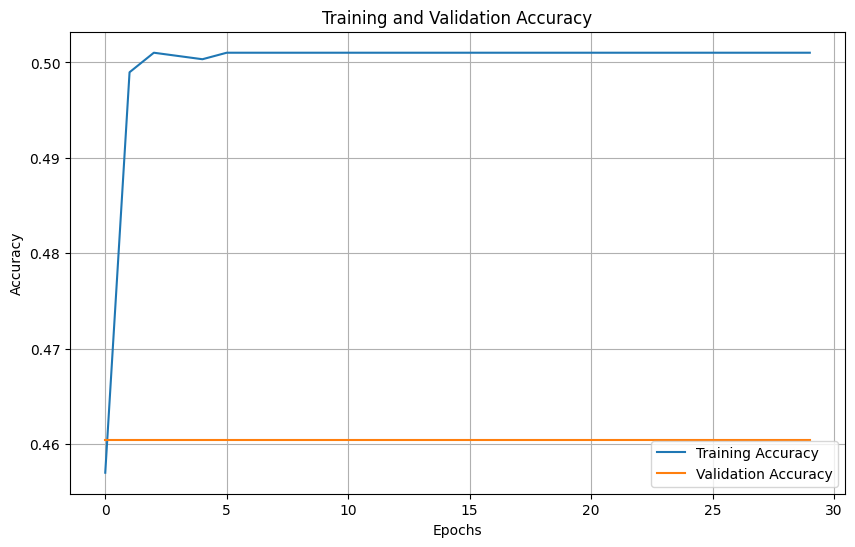

In [15]:
import matplotlib.pyplot as plt

#학습 및 검증 정확도 시각화
plt.figure(figsize=(10, 6))  #그래프 크기 설정
plt.plot(history.history['accuracy'], label='Training Accuracy')  #학습 정확도 플롯
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  #검증 정확도 플롯
plt.xlabel('Epochs')  #x축: 에포크
plt.ylabel('Accuracy')  # y축: 정확도
plt.title('Training and Validation Accuracy')  #그래프 제목
plt.legend()  # 범례 추가
plt.grid(True)  #격자 추가
plt.show()


# → 에포크마다 기록된 학습 정확도와 검증 정확도를 한 그래프에 두 선으로 그려 비교하겠다

위 코드에서 `plt.plot`을 사용하여 학습 정확도와 검증 정확도의 변화를 선 그래프로 표현합니다. 그래프의 x축은 에포크(epoch)를, y축은 정확도(accuracy)를 나타냅니다. `plt.legend`로 두 그래프를 구분하는 범례를 추가하여 학습 정확도와 검증 정확도를 명확히 구분할 수 있습니다.

시각화된 그래프를 통해 학습 성능을 분석할 수 있습니다. 학습이 적절히 이루어진 경우, 학습 정확도와 검증 정확도가 에포크가 진행됨에 따라 점진적으로 증가하며 수렴하는 경향을 보입니다. 만약 학습 정확도는 높아지는데 검증 정확도가 감소한다면 이는 과적합이 발생했음을 의미하며, 학습률 조정이나 Dropout 등의 기법을 적용해 개선할 수 있습니다. 반대로 학습 정확도와 검증 정확도가 모두 낮다면 이는 과소적합을 나타내며, 모델의 구조를 개선하거나 데이터를 추가로 증강해야 할 수 있습니다.

이러한 시각화는 모델 학습의 품질과 성능을 직관적으로 이해할 수 있도록 도와주며, 학습 과정에서 발생할 수 있는 문제를 사전에 탐지하고 해결하는 데 유용합니다.

**그래프 읽는 법 — 세 가지 대표 모양**

| 모양 | 뜻 | 할 일 |
|---|---|---|
| 두 선이 함께 오르다 비슷한 높이에서 평평해짐 | 잘 학습됨 | 그대로 사용 |
| 학습 선은 계속 오르는데 검증 선은 어느 순간부터 내려가거나 멈춤, 두 선 사이가 벌어짐 | **과적합**: 학습 사진만 외우기 시작함 | Dropout·증강 늘리기, 학습 일찍 멈추기(EarlyStopping) |
| 두 선 모두 낮은 곳에서 평평함 | **과소적합**: 모델이 아직 패턴을 못 배움 | 더 오래 학습, 더 큰 모델, 학습률 조정 |

이 데이터는 정상 사진이 약 49%이므로, 정확도가 **0.49 근처에서 움직이지 않으면** 모델이 모든 사진을 "정상"으로만 찍고 있다는 신호입니다.

**결과 해석 — 학습·검증 정확도 그래프**

- **파란 선(학습)**: 첫 에포크 0.46에서 2에포크 만에 0.50으로 오른 뒤 30에포크까지 평평합니다. "모두 정상"으로 답하는 상태에 도달한 순간입니다.
- **주황 선(검증)**: 처음부터 끝까지 0.4604로 일직선입니다.
- y축 눈금이 0.46∼0.50으로 아주 좁게 잡혀 있어서 그래프가 크게 움직이는 것처럼 보이지만, 실제 차이는 4%p 정도입니다. 그래프를 읽을 때는 **축의 범위부터 확인**해야 합니다.
- 잘 학습되는 모델이라면 두 선이 함께 올라가다가, 과적합이 시작되면 학습 선만 계속 오르고 검증 선은 멈추거나 내려갑니다. 여기서는 두 선 모두 처음부터 평평하므로 **과적합이 아니라 학습 자체가 일어나지 않은 상태**입니다.

### 7. 개선 사항

CNN 모델 학습과 J48 분류기 훈련은 복잡한 연산을 포함하므로 상당한 학습 시간과 컴퓨팅 리소스를 요구할 수 있습니다. CNN 모델은 대규모 데이터를 처리하고 이미지의 고차원 특징을 학습하며, J48 결정 트리는 이 특징을 기반으로 최적의 분류 경로를 찾기 위해 많은 계산을 수행합니다. 이러한 과정에서 학습 시간이 과도하게 길어지거나 리소스 소모가 높아질 수 있으므로, 학습 과정 최적화와 하이퍼파라미터 튜닝이 필요합니다.

먼저, CNN 모델 학습 시간을 단축하기 위해 <strong>미리 훈련된 모델(Pre-trained Model)</strong>을 사용하는 전이 학습(Transfer Learning)을 고려할 수 있습니다. 예를 들어, Inception-v3, VGG16과 같은 사전 학습된 모델을 사용하면 초기 단계의 특징 학습을 건너뛰고, DR 분류에 특화된 후반부 층만 재학습하여 학습 시간을 단축할 수 있습니다.

또한, **학습률(Learning Rate)** 조정은 학습 최적화에 중요한 요소입니다. 학습률이 너무 높으면 모델이 최적화되지 않고 발산할 수 있으며, 너무 낮으면 학습 시간이 길어질 수 있습니다. ReduceLROnPlateau와 같은 동적 학습률 감소 기법을 사용하면 손실 감소가 정체된 경우 학습률을 자동으로 줄여 학습 효율을 높일 수 있습니다.

데이터 처리 단계에서는 <strong>데이터 배치 크기(Batch Size)</strong>를 조정하여 학습 시간을 최적화할 수 있습니다. 배치 크기가 너무 작으면 모델 학습이 느려지고, 너무 크면 메모리 부족 문제가 발생할 수 있습니다. 적절한 배치 크기를 선택하여 모델 학습의 속도와 메모리 사용 간 균형을 맞출 수 있습니다.

J48 결정 트리의 학습 과정도 최적화가 필요합니다. **특징 차원 축소**를 통해 입력 데이터의 복잡성을 줄이고 트리의 크기를 제한하여 계산 비용을 줄일 수 있습니다. 또한, J48 결정 트리의 하이퍼파라미터(예: 최대 깊이, 최소 샘플 분할 수)를 조정하여 모델 학습 속도와 성능을 균형 있게 맞출 수 있습니다.

마지막으로, 하드웨어 리소스를 효율적으로 사용하기 위해 **GPU 또는 TPU**를 활용하면 학습 속도를 크게 향상시킬 수 있습니다. CNN 모델의 병렬 계산 구조는 GPU와 매우 잘 맞으며, 대규모 데이터 처리에서 특히 유리합니다. 학습 시간과 리소스를 최적화하기 위해 전이 학습, 동적 학습률 조정, 배치 크기 조정, 특징 차원 축소, 그리고 GPU 활용 등의 전략을 통합적으로 적용하는 것이 필요합니다. 이러한 접근법은 모델 학습 시간을 단축하면서도 높은 성능을 유지하도록 도와줍니다.

**참고 — 결정 트리 하이퍼파라미터 예시**

책에서 말한 "최대 깊이, 최소 샘플 분할 수"는 scikit-learn에서 다음처럼 지정합니다. 깊이를 제한하면 트리가 학습 데이터를 끝까지 외우는 것(과적합)을 막을 수 있습니다.

```python
DecisionTreeClassifier(max_depth=10, min_samples_split=20, random_state=42)
```

| 매개변수 | 뜻 |
|---|---|
| `max_depth` | 질문(가지)을 최대 몇 단계까지 할지. 작을수록 단순한 트리 |
| `min_samples_split` | 한 마디(노드)에 사진이 이 개수 이상 있어야 더 나눔 |
| `random_state` | 같은 결과가 다시 나오게 하는 고정값 |

## Step 6. 코드 자세히 살펴보기

책의 이 부분은 페이지 머리에 "CNN을 이용한 코드 자세히 살펴보기"라는 제목이 붙어 있으며, Step 5에서 개요로 보았던 **커스텀 CNN + J48 결정 트리** 코드를 한 단계씩 자세히 설명합니다. 원래 코드는 Kaggle 노트북에서 시작해 로컬 PC(`D:/Dataset`)로 옮겨 실행한 흔적이 섞여 있어, 같은 라이브러리를 여러 번 불러오는 등 중복이 많습니다. 책의 흐름을 그대로 따라가되, 실행이 안 되는 부분만 고쳤습니다.

> Step 6만 따로 실행할 수도 있도록 실행 설정 셀을 한 번 더 넣었습니다. Step 5에서 이미 실행했다면 다시 실행해도 결과는 같습니다.

In [16]:
# [추가] 실행 설정 — 에포크 수, 데이터 경로, 모델 저장 경로를 이 셀 한 곳에서 관리


import os
import glob

# ===== Epochs =====
# EPOCHS: 이 노트북의 모든 학습(fit)에 쓰는 에포크 수
# 책 원래 값: Step 5는 epochs=50, Step 6·7은 epochs=100
# Kaggle은 한 번 실행이 최대 12시간이라, 학습 5번(Step 5 CNN, Step 6 CNN, InceptionV3, VGG16, 앙상블)이 그 안에 끝나도록 줄여서 사용
EPOCHS = 30

# ===== Paths =====
# glob('/kaggle/input/**/train.csv', recursive=True): /kaggle/input 아래 모든 하위 폴더를 뒤져 train.csv 경로를 찾음
# 그중 옆에 train_images 폴더가 있는 것만 고름 (다른 데이터셋의 train.csv와 헷갈리지 않도록)
found = [p for p in glob.glob('/kaggle/input/**/train.csv', recursive=True)
         if os.path.isdir(os.path.join(os.path.dirname(p), 'train_images'))]
# DATA_DIR: Kaggle이면 찾은 폴더, 아니면(내 PC) C:/Dataset (책은 D:/Dataset)
DATA_DIR = os.path.dirname(found[0]) if found else 'C:/Dataset'
# SAVE_DIR: Kaggle에서 파일을 저장할 수 있는 곳은 /kaggle/working 뿐. 내 PC면 C:/testRun (책은 D:/testRun)
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else 'C:/testRun'

# os.makedirs(..., exist_ok=True): 저장 폴더가 없으면 새로 만들고, 이미 있으면 그냥 넘어감
os.makedirs(SAVE_DIR, exist_ok=True)

# ===== Image cache =====
# 원본 사진은 한 장이 가로 2,000~4,000픽셀이라, 학습 시간 대부분이 에포크마다 큰 사진을 다시 읽는 데 쓰임
# 처음 한 번만 긴 변 512픽셀로 줄여 따로 저장해 두고, 이후에는 이 작은 사진을 읽게 함 (모델 입력은 어차피 227·224)
import cv2
import shutil
from concurrent.futures import ThreadPoolExecutor

# CACHE_DIR: 줄인 사진을 둘 곳. Kaggle은 /tmp(실행이 끝나면 지워지는 임시 폴더), 내 PC는 C:/Dataset_512
CACHE_DIR = '/tmp/aptos_512' if found else 'C:/Dataset_512'
SRC_DIR = DATA_DIR

def shrink_image(name):
    dst = os.path.join(CACHE_DIR, 'train_images', name)
    # 이미 줄여 둔 사진이면 건너뜀 → 이 셀을 다시 실행해도(Step 6·7) 금방 끝남
    if os.path.exists(dst):
        return
    img = cv2.imread(os.path.join(SRC_DIR, 'train_images', name))
    h, w = img.shape[:2]
    # scale: 긴 변이 512가 되도록 줄이는 비율 (가로세로 비율은 그대로 유지)
    scale = 512 / max(h, w)
    if scale < 1:
        # INTER_AREA: 사진을 줄일 때 화질 손실이 가장 적은 방식
        img = cv2.resize(img, (round(w * scale), round(h * scale)), interpolation=cv2.INTER_AREA)
    cv2.imwrite(dst, img)

if os.path.exists(f'{SRC_DIR}/train.csv'):
    os.makedirs(f'{CACHE_DIR}/train_images', exist_ok=True)
    # train.csv도 같은 폴더에 복사해 두어, 아래 코드의 f'{DATA_DIR}/...' 경로를 그대로 쓸 수 있게 함
    shutil.copy(f'{SRC_DIR}/train.csv', f'{CACHE_DIR}/train.csv')
    names = os.listdir(f'{SRC_DIR}/train_images')
    # ThreadPoolExecutor: CPU 코어 수만큼 동시에 사진을 줄여 시간을 아낌
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
        list(ex.map(shrink_image, names))
    # 이후 모든 코드는 줄인 사진 폴더를 데이터 폴더로 사용
    DATA_DIR = CACHE_DIR
    print('줄인 사진 수:', len(os.listdir(f'{CACHE_DIR}/train_images')))
print('EPOCHS  :', EPOCHS)
print('DATA_DIR:', DATA_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('원본 위치:', SRC_DIR)
# os.path.exists(): 그 경로에 파일이 실제로 있는지 True/False로 알려 줌
print('train.csv 있음:', os.path.exists(f'{DATA_DIR}/train.csv'))
print('train_images 폴더 있음:', os.path.exists(f'{DATA_DIR}/train_images'))


# → Kaggle에서는 데이터 위치를 자동으로 찾고, 내 PC에서는 C:/Dataset을 쓰도록 하겠다
# → 처음 실행할 때 사진 3,662장을 긴 변 512픽셀로 줄여 두고(Kaggle 기준 몇 분), 이후 학습은 작은 사진을 읽어 훨씬 빠르게 하겠다
# → 모든 학습의 에포크 수를 EPOCHS 하나로 관리해, 시간이 넉넉하면 이 숫자만 100으로 바꾸면 되게 하겠다
# → 마지막 두 줄이 모두 True가 나와야 아래 셀들이 정상적으로 실행된다

줄인 사진 수: 3662
EPOCHS  : 30
DATA_DIR: /tmp/aptos_512
SAVE_DIR: /kaggle/working
원본 위치: /kaggle/input/competitions/aptos2019-blindness-detection
train.csv 있음: True
train_images 폴더 있음: True


### 1. 모듈 임포트

아래 코드는 CNN 모델 학습을 위한 필수 라이브러리와 환경을 설정하는 과정으로, 텐서플로(TensorFlow)와 케라스(Keras)를 기반으로 작성되었습니다.

In [17]:
#!/usr/bin/env python
# coding: utf-8

import os
import numpy as np
# [개선] 기존: pip uninstall tf-nightly → 파이썬 코드 줄이 아니라서 SyntaxError. 필요할 때만 주석(#)을 풀어 실행
# !pip uninstall -y tf-nightly
import tensorflow as tf
# [개선] 기존: tf.config.list_physical_devices(GPU) → 'GPU'에 따옴표가 없어 NameError. print로 결과를 보이게 함
print(tf.config.list_physical_devices('GPU'))
# [개선] 기존: tf.test.is_gpu_available() → 더 이상 권장되지 않는 함수(아래 본문 설명 참고). 위 줄로 대신함
import tensorflow as tf
from sklearn.model_selection import train_test_split
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam


# → 파일·배열·딥러닝 도구를 불러오고, 사용할 수 있는 GPU 목록을 출력하겠다
# → 출력이 []이면 GPU가 없거나 인식되지 않은 것이고, 이 경우 CPU로 학습하므로 시간이 오래 걸린다

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


먼저, `os`와 `numpy` 모듈을 임포트하여 파일 관리 및 배열 연산을 처리합니다. `os`는 데이터 파일의 경로를 탐색하거나 관리하는 데 사용되며, `numpy`는 학습 데이터의 수치 연산과 배열 변환에 필수적인 라이브러리입니다.

다음으로, `pip uninstall tf-nightly` 명령은 TensorFlow의 nightly 버전을 제거하기 위한 명령으로 보입니다. 이는 TensorFlow 안정 버전과의 충돌을 방지하기 위함입니다.

이후, TensorFlow를 임포트하여 GPU 환경을 확인하는 코드가 포함되어 있습니다. `tf.config.list_physical_devices('GPU')`는 시스템에 GPU가 감지되었는지 확인하는 데 사용되며, `tf.test.is_gpu_available()`은 TensorFlow에서 GPU 사용 가능 여부를 확인합니다. 이 과정은 CNN 모델 학습에서 GPU를 활용하여 계산 속도를 높이기 위한 환경 설정 단계입니다.

`train_test_split`은 사이킷런(Scikit-learn)의 데이터 분할 함수로, 데이터를 학습용과 테스트용으로 나누는 데 사용됩니다. 이는 모델의 학습과 평가를 위해 필수적인 단계입니다.

`ImageDataGenerator`는 Keras의 이미지 데이터 증강 도구로, 학습 데이터셋을 실시간으로 변형하여 학습의 다양성을 제공합니다. 회전, 확대, 반전 등의 증강 기법을 통해 모델의 일반화 성능을 향상시킬 수 있습니다.

Keras의 `VGG16`은 전이 학습에 자주 사용되는 사전 학습된 모델로, 복잡한 이미지 분류 작업에서 우수한 성능을 보입니다. `Sequential`은 Keras의 모델 생성 클래스 중 하나로, 층을 순차적으로 쌓아 간단하게 모델을 구성할 수 있습니다. `Flatten`, `Dense`, `Dropout`은 모델의 레이어 구성 요소로, 입력 데이터를 펼치거나(Flatten) 연결 층을 추가하고(Dense) 과적합을 방지하는(Dropout) 역할을 합니다.

마지막으로, `ModelCheckpoint`는 학습 중 가장 좋은 성능의 모델을 저장하는 콜백이며, `Adam` 옵티마이저는 모델 학습 과정에서 가중치를 업데이트하는 데 사용됩니다. 이 모든 요소는 CNN 모델의 학습 과정에서 필수적인 설정들로, 모델의 성능을 극대화하기 위한 환경을 준비합니다.

> **개선 사항 — `pip` 명령과 `keras.preprocessing.image`**
>
> - `pip uninstall tf-nightly`는 **터미널(명령 프롬프트)에서 치는 명령어**라서 파이썬 코드 셀에 그대로 쓰면 `SyntaxError`가 납니다. 노트북에서 실행하려면 앞에 `!`를 붙여야 합니다(`!pip ...`). 또 `-y`를 붙이지 않으면 "정말 지울까요? [y/n]" 질문에서 멈춰 버립니다. tf-nightly(매일 밤 나오는 개발용 버전)를 설치한 적이 없다면 실행할 필요가 없으므로 주석으로 남겨 두었습니다.
> - Keras 3(TensorFlow 2.16 이상)부터 `ImageDataGenerator`는 옛날 방식(legacy)으로 분류되어 `keras.preprocessing.image`에서 빠졌습니다. `tensorflow.keras.preprocessing.image`에서는 아직 불러올 수 있으므로 경로만 바꿨습니다. 이 노트북 전체에서 같은 방법으로 고쳤습니다.

아래 코드는 Kaggle의 Python 환경에서 데이터를 처리하고 분석하기 위해 필요한 라이브러리를 임포트하는 초기 설정을 보여줍니다.

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# → Kaggle 노트북을 새로 만들면 자동으로 들어 있는 첫 셀이다. numpy와 pandas를 불러오겠다

아래 코드는 Kaggle 환경에서 데이터를 탐색하고 파일 경로를 출력하는 데 사용됩니다. Kaggle의 데이터는 보통 읽기 전용 디렉터리(`../input/`)에 저장되어 있으며, 이를 확인하기 위해 Python의 `os` 모듈과 `os.walk` 함수를 활용합니다.

In [19]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    # [개선] 기존: for filename in filenames: print(os.path.join(dirname, filename))
    #        → Kaggle에서는 사진 경로가 5,600줄 가까이 출력되어 노트북·HTML이 매우 길어짐. 폴더별 파일 개수만 출력
    print(dirname, '→ 파일', len(filenames), '개')


# → /kaggle/input 폴더와 그 안의 모든 하위 폴더를 돌며, 폴더마다 파일이 몇 개 있는지 출력하겠다

/kaggle/input → 파일 0 개
/kaggle/input/competitions → 파일 0 개
/kaggle/input/competitions/aptos2019-blindness-detection → 파일 3 개
/kaggle/input/competitions/aptos2019-blindness-detection/train_images → 파일 3662 개
/kaggle/input/competitions/aptos2019-blindness-detection/test_images → 파일 1928 개


> **참고 — 이 셀은 어디서 실행하느냐에 따라 결과가 다릅니다**
>
> - **내 PC(Windows)**: `/kaggle/input` 폴더가 없으므로 아무것도 출력하지 않고 조용히 끝납니다. 오류가 아닙니다.
> - **Kaggle**: 원래 코드대로라면 APTOS 데이터의 파일 경로가 **5,600줄 가까이**(학습 사진 3,662장 + 테스트 사진 1,928장 + csv 파일들) 출력되어 노트북과 HTML이 매우 길어집니다. 그래서 이 노트북에서는 **폴더마다 파일 개수만** 출력하도록 바꿨습니다. `train_images → 파일 3662 개`가 보이면 데이터가 제대로 연결된 것입니다.

아래 코드는 데이터 분석, 전처리, 시각화, 머신러닝, 그리고 딥러닝 모델 학습에 필요한 다양한 라이브러리를 임포트하고, 초기 환경을 설정합니다. 이 설정은 데이터 처리에서부터 CNN 기반 딥러닝 모델 구현에 이르는 전 과정을 지원합니다.

In [20]:
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import random
import os
import gc # garbage collector
import datetime
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint, TensorBoard
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import backend as K
from keras import Input
from keras.models import Model
from keras.utils import *
from keras.layers import *
import tensorflow
tensorflow.random.set_seed(2)
import matplotlib.pyplot as plt
np.random.seed(0)
import os
import gc


# → 표·배열·그래프·이미지 처리·평가 지표·딥러닝 층과 콜백을 한꺼번에 불러오겠다
# → 난수 시드(seed)를 고정해, 다시 실행해도 무작위 결과가 최대한 같게 나오도록 하겠다

먼저, `pandas`와 `numpy`는 데이터 처리와 배열 연산을 위한 필수 라이브러리로, 데이터프레임 관리와 수학적 계산을 간단하게 수행할 수 있습니다. `matplotlib.pyplot`과 `seaborn`은 데이터 시각화를 위한 라이브러리로, 그래프와 플롯을 통해 데이터를 분석합니다. `cm`은 matplotlib의 컬러맵을 활용하기 위한 모듈입니다.

`random`은 무작위 데이터 생성에, `os`는 파일 및 디렉터리 관리에, 그리고 `gc`는 가비지 컬렉터를 활용한 메모리 관리를 위해 사용됩니다. `datetime`은 시간 관련 데이터를 처리하며, `tqdm`은 반복 작업의 진행 상황을 시각적으로 표시하는 유용한 도구입니다.

`cv2`는 OpenCV 라이브러리로 이미지 처리 작업에 사용됩니다. 이미지를 읽고 변환하며 다양한 처리 기법을 지원합니다. `train_test_split`은 데이터를 학습용과 테스트용으로 분리하며, `accuracy_score`, `confusion_matrix`, `f1_score`는 모델 성능 평가를 위한 사이킷런의 메트릭입니다.

텐서플로(TensorFlow)와 케라스(Keras)는 딥러닝 모델 구현에 필요한 주요 라이브러리입니다. CNN 모델 구성에 필요한 다양한 레이어(`Conv2D`, `Dense`, `Flatten` 등)와 콜백(`EarlyStopping`, `ModelCheckpoint` 등)을 제공합니다. 또한, `ImageDataGenerator`는 이미지 데이터 증강과 전처리를 간편하게 수행할 수 있습니다.

`tensorflow.random.set_seed(2)`와 `numpy.random.seed(0)`는 재현 가능한 결과를 얻기 위해 난수 시드를 설정합니다. 이는 실험 반복 시 일관된 결과를 보장하는 데 유용합니다.

전체적으로, 이 코드는 머신러닝과 딥러닝 기반의 데이터 분석 및 모델 학습 워크플로를 지원하는 데 필요한 모든 설정을 포함하고 있습니다. 이를 통해 데이터 준비, 전처리, 모델 구현, 학습, 평가까지 전 과정을 체계적으로 수행할 수 있습니다.

> **참고 — `from keras.layers import *`의 `*`**
>
> `*`는 "그 모듈에 있는 이름을 전부 가져오라"는 뜻입니다. 편하지만, 어떤 이름이 들어왔는지 코드만 봐서는 알 수 없고, 앞에서 불러온 같은 이름(예: `Input`, `Model`)을 조용히 덮어쓸 수 있습니다. 실무에서는 필요한 이름만 적어서 불러오는 방식을 권장합니다. 책 코드를 살리기 위해 그대로 두었습니다.

아래 코드는 Python 환경에서 데이터 분석과 작업 효율성을 높이기 위해 필요한 라이브러리를 설치하는 과정입니다. 먼저, Seaborn은 통계적 데이터 시각화 라이브러리로, 다양한 그래프를 간단하게 생성하여 데이터의 분포와 관계를 명확히 이해할 수 있도록 돕습니다. 예를 들어, 히트맵이나 카운트 플롯과 같은 그래프를 쉽게 작성할 수 있어 데이터 분석 과정에서 유용합니다.

In [21]:
# [개선] 기존: pip install seaborn / pip install matplotlib / pip install tqdm
#        → 파이썬 코드가 아니라 SyntaxError. 노트북에서는 %pip를 붙여야 하며, 이미 설치되어 있으면 실행할 필요 없음
# %pip install seaborn matplotlib tqdm


# → 세 라이브러리가 없을 때만 위 줄의 주석(#)을 풀어 한 번 설치하겠다

다음으로, Matplotlib은 가장 널리 사용되는 시각화 라이브러리 중 하나로, 선 그래프, 산점도, 히스토그램 등 다양한 그래프를 생성할 수 있습니다. 데이터를 시각적으로 표현함으로써 분석 과정에서 중요한 패턴이나 추세를 식별하는 데 도움을 줍니다.

마지막으로, TQDM은 작업 진행 상황을 실시간으로 표시하는 라이브러리로, 대량 데이터를 처리하거나 반복 작업을 수행하는 동안 현재 작업의 진행률을 시각적으로 모니터링할 수 있습니다. 이를 통해 긴 작업의 예상 소요 시간을 파악하고 효율적으로 관리할 수 있습니다.

이 모든 라이브러리는 데이터 분석, 머신러닝, 딥러닝 모델 학습 등 다양한 작업에서 필수적이며, Python 환경의 생산성을 크게 향상시킵니다. 설치 과정은 간단하며, 이후 작업에 즉시 활용할 수 있습니다.

> **실행 전 주의 — `%pip install`**
>
> - 인터넷에서 패키지를 내려받아 **지금 쓰고 있는 파이썬 환경에 설치**합니다. 아나콘다를 쓴다면 지금 선택된 가상환경(커널)에 설치됩니다.
> - `!pip`보다 `%pip`가 안전합니다. `%pip`는 노트북이 실제로 쓰는 파이썬에 정확히 설치하고, `!pip`는 컴퓨터에 파이썬이 여러 개 있으면 엉뚱한 곳에 설치될 수 있습니다.
> - 설치 후에는 **커널 재시작**(Kernel → Restart)을 해야 새 패키지가 확실히 반영됩니다.

아래 코드는 이미지 처리, 데이터 전처리, 시각화, 그리고 딥러닝 모델 학습을 위한 다양한 라이브러리와 모듈을 포함합니다. 이 코드는 데이터 분석과 CNN 기반 모델 구현의 전반적인 과정을 지원하도록 설계되었습니다.

In [22]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers
from tensorflow.keras.optimizers import Adam
# [개선] 기존 책 인쇄본: from keras.callbacks Callback,ModelCheckpoint,ReduceLROnPlateau → import가 빠져 SyntaxError
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
# [개선] 기존: from keras.wrappers.scikit_learn import KerasClassifier
#        → Keras 3에서 keras.wrappers.scikit_learn이 삭제되어 ModuleNotFoundError. 이 장에서 쓰지 않으므로 주석 처리
# from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K
#import tensorflow_addons as tfa
#from tensorflow.keras.metrics import Metric
#from tensorflow_addons.utils.types import AcceptableDTypes, FloatTensorLike
#from typeguard import typechecked
from typing import Optional
# [개선] 기존: get_ipython().run_line_magic('matplotlib', 'inline') → 노트북에서 쓰는 같은 뜻의 매직 명령으로 바꿈
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# → 이미지 처리·평가 지표·전이 학습 모델·콜백 도구를 불러오고, 그래프 스타일과 경고 숨기기를 설정하겠다

코드의 첫 부분에서는 파일 관리(`os`), 이미지 처리(`cv2`), 난수 생성(`random`), 경고 제어(`warnings`), 배열 연산(`numpy`), 데이터프레임 관리(`pandas`), 데이터 시각화(`seaborn`, `matplotlib`), 그리고 머신러닝 평가 지표(`confusion_matrix`, `cohen_kappa_score`)와 관련된 라이브러리를 임포트합니다. 이러한 라이브러리는 데이터 준비와 탐색적 데이터 분석(EDA)에 사용됩니다.

다음으로, 딥러닝 모델 구현을 위해 텐서플로(TensorFlow)와 케라스(Keras) 관련 모듈이 포함됩니다. 텐서플로는 딥러닝 프레임워크로, 이미지 데이터를 처리하고 CNN 모델을 학습시키는 데 사용됩니다. 케라스는 텐서플로의 고수준 API로, 모델 설계와 학습 과정을 간단하게 구성할 수 있도록 지원합니다. 이를 통해 합성곱 레이어(`Conv2D`), 풀링 레이어(`MaxPool2D`), 정규화(`BatchNormalization`), 드롭아웃(`Dropout`), 완전 연결층(`Dense`) 등 CNN 모델의 주요 구성 요소를 손쉽게 정의할 수 있습니다.

또한, 전이 학습(Transfer Learning)을 위해 ResNet50과 같은 사전 학습된 모델을 포함하고, 이미지 데이터 증강을 위한 `ImageDataGenerator`를 활용합니다. 이는 데이터를 실시간으로 변환하여 학습 데이터의 다양성을 증가시키고 모델의 일반화 성능을 향상시킵니다.

콜백 함수로는 학습 조기 종료를 위한 `EarlyStopping`, 학습률 동적 조정을 위한 `ReduceLROnPlateau`, 최적의 모델 저장을 위한 `ModelCheckpoint`가 포함되어 있어, 학습 과정을 효율적으로 관리할 수 있습니다.

이 외에도, 케라스를 사이킷런과 통합하여 사용하기 위한 `KerasClassifier`, 범주형 데이터를 변환하기 위한 `to_categorical` 등이 포함되어 있으며, 모델 학습의 재현성을 보장하기 위해 난수 시드가 설정되어 있습니다.

전반적으로, 이 코드는 데이터 준비, 모델 설계, 학습, 평가, 그리고 전이 학습에 필요한 모든 기능을 통합하여 딥러닝 기반 이미지 분석 프로젝트를 효과적으로 지원합니다.

> **개선 사항 — Keras 3에서 사라진 `keras.wrappers`**
>
> `KerasClassifier`는 Keras 모델을 scikit-learn의 `cross_val_score` 같은 도구에 넣을 수 있게 감싸 주는 도구였는데, Keras 3에서 삭제되었습니다(같은 기능은 별도 패키지 `scikeras`로 옮겨 갔습니다). 이 장의 코드에서는 실제로 쓰이지 않으므로 주석 처리했습니다. 주석으로 되어 있는 `tensorflow_addons`도 2024년에 개발이 끝난 패키지라 최신 TensorFlow와 함께 설치되지 않습니다.

아래 코드는 데이터 처리와 GPU 환경 설정을 위해 사용됩니다.

In [23]:
import pandas as pd #For reading csv files.
# [개선] 기존: tf.config.list_physical_devices(GPU') → 따옴표 짝이 맞지 않아 SyntaxError
print(tf.config.list_physical_devices('GPU'))
tf.test.is_gpu_available()


# → GPU 목록을 출력하고, TensorFlow가 GPU를 쓸 수 있는지 True/False로 확인하겠다

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

먼저, `pandas` 라이브러리를 사용하여 CSV 파일을 읽고 관리할 수 있습니다. 이는 데이터 분석 작업에서 필수적인 라이브러리로, CSV 파일로부터 데이터를 가져와 데이터프레임 형태로 변환하여 효율적으로 처리할 수 있도록 지원합니다.

이후 텐서플로(TensorFlow)를 활용해 GPU 환경을 확인합니다. `tf.config.list_physical_devices('GPU')`는 현재 시스템에서 사용 가능한 GPU 장치를 나열하여, 학습 과정에서 사용할 GPU 자원이 있는지 확인합니다. 이는 CNN 모델과 같은 복잡한 딥러닝 작업에서 중요한 단계로, GPU를 사용할 수 있으면 학습 속도가 크게 향상됩니다.

마지막으로, `tf.test.is_gpu_available()` 함수는 텐서플로에서 GPU가 실제로 사용 가능한지 여부를 반환합니다. 이를 통해 TensorFlow가 GPU를 감지하고 활용할 준비가 되었는지 확인할 수 있습니다. 이 설정은 딥러닝 모델의 학습 효율성을 높이기 위한 필수 단계로, 특히 대규모 데이터셋을 처리할 때 유용합니다.

In [24]:
import tensorflow as tf
tf.test.is_gpu_available(
    cuda_only=False, min_cuda_compute_capability=None
)


# → CUDA 여부와 GPU 성능 조건을 따지지 않고, 쓸 수 있는 GPU가 하나라도 있으면 True를 돌려받겠다

True

아래 코드는 TensorFlow에서 GPU 사용 가능 여부를 확인하기 위해 사용됩니다. 이 코드는 시스템에 설치된 GPU가 TensorFlow와 호환되는지, 그리고 딥러닝 작업에 활용될 수 있는지를 판단합니다.

`tf.test.is_gpu_available` 함수는 GPU의 가용성을 확인하며, 두 가지 주요 매개변수를 포함합니다.

- **`cuda_only=False`**: 이 설정은 CUDA가 설치되지 않은 경우에도 GPU 가용성을 확인할 수 있도록 합니다. 즉, CUDA 환경 외에도 OpenCL과 같은 다른 GPU 플랫폼의 사용 가능성을 점검합니다.
- **`min_cuda_compute_capability=None`**: GPU의 최소 연산 능력을 지정하지 않는 설정으로, 모든 GPU를 대상으로 가용성을 확인합니다. CUDA 연산 능력은 GPU 모델에 따라 다르며, 연산 능력이 높을수록 더 빠른 계산을 지원합니다.

이 함수는 GPU가 사용 가능한 경우 `True`를, 그렇지 않은 경우 `False`를 반환합니다. 결과적으로, GPU가 TensorFlow 작업에 활용 가능한지 확인할 수 있습니다. 딥러닝 모델의 학습이나 추론 속도를 높이는 데 GPU는 매우 중요하며, 이를 확인하는 과정은 모델 학습 환경을 설정하는 필수 단계입니다. 다만, 이 함수는 TensorFlow 2.0 이후 버전에서는 더 이상 권장되지 않으며, 대신 `tf.config.list_physical_devices('GPU')`와 같은 새로운 메서드를 사용하는 것이 권장됩니다. 이 새로운 방법은 보다 정확하고 체계적으로 GPU 정보를 제공합니다.

> **참고 — `is_gpu_available`을 실행하면 경고가 함께 나옵니다**
>
> 위 두 셀은 책 설명을 따라가기 위해 남겨 두었지만, 실행하면 "이 함수는 앞으로 없어질 예정이니 `tf.config.list_physical_devices('GPU')`를 쓰라"는 경고(WARNING) 문구가 함께 출력됩니다. 오류가 아니므로 무시해도 됩니다. 앞으로 직접 코드를 짤 때는 `list_physical_devices` 한 줄만 쓰면 됩니다.
>
> 용어: **CUDA**는 NVIDIA가 만든 "GPU로 일반 계산을 하게 해 주는 도구 모음"입니다. TensorFlow는 NVIDIA GPU를 쓸 때 CUDA를 통해 계산합니다.

### 2. 데이터 읽어오기 및 전처리

아래 코드는 학습 데이터셋을 불러오고, 데이터의 기본적인 정보를 확인하는 과정을 보여줍니다. 이 코드는 데이터 분석 및 모델 학습을 준비하기 위한 필수 단계입니다.

In [25]:
# [개선] 기존: PATH = 'D:/Dataset', pd.read_csv('D:/Dataset/train.csv') → 실행 설정 셀의 DATA_DIR 사용
PATH = DATA_DIR
train = pd.read_csv(f'{DATA_DIR}/train.csv')
# [개선] 기존: print(Number of train samples:', ...) → 여는 따옴표가 빠져 SyntaxError
print('Number of train samples:', train.shape[0])
display(train.head())
display(train.tail())


# → train.csv를 읽어 전체 사진 수를 출력하고, 표의 맨 앞 5줄과 맨 뒤 5줄을 보여 주겠다

Number of train samples: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


,id_code,diagnosis
3657,ffa47f6a7bf4,2
3658,ffc04fed30e6,0
3659,ffcf7b45f213,2
3660,ffd97f8cd5aa,0
3661,ffec9a18a3ce,2


먼저, `PATH` 변수는 데이터셋이 저장된 디렉터리 경로를 설정합니다. 이 경로를 기반으로 `train.csv` 파일을 읽어오며, `pandas` 라이브러리의 `read_csv` 함수를 사용하여 데이터를 데이터프레임 형태로 로드합니다. 데이터프레임은 행(row)과 열(column)로 구성된 표 형식의 데이터 구조로, 데이터 조작과 분석에 매우 유용합니다.

`train.shape[0]`는 데이터프레임의 행 개수를 반환하여, 학습 데이터셋에 포함된 샘플의 총 개수를 출력합니다. 이를 통해 데이터의 전체 크기를 확인할 수 있습니다.

`display(train.head())`와 `display(train.tail())`는 데이터프레임의 첫 5개 행과 마지막 5개 행을 각각 출력합니다. 이를 통해 데이터의 기본 구조와 각 열의 값 분포를 확인할 수 있습니다. 데이터셋의 형식과 내용에 대한 초기 탐색을 돕는 중요한 단계입니다.

이 코드는 데이터셋을 성공적으로 불러오고 간단히 탐색하는 과정을 포함하며, 모델 학습을 위한 데이터 전처리와 분석의 기초 작업을 제공합니다. 이를 통해 데이터셋의 크기와 구성을 파악하고, 이후 단계에서 필요한 전처리 작업을 계획할 수 있습니다.

> **결과 미리 보기** — 데이터가 제대로 있다면 `Number of train samples: 3662`가 출력되고, 그 아래에 `id_code`(파일 이름)와 `diagnosis`(0∼4) 두 열짜리 표가 앞뒤 5줄씩 나옵니다. `print`와 달리 `display`는 표를 노트북에서 보기 좋은 칸 모양으로 그려 줍니다.

아래 코드는 학습 데이터셋의 탐색과 시각화를 수행하여 데이터의 분포와 이미지 내용을 분석하는 과정을 보여줍니다. 이 과정은 데이터의 구성과 품질을 이해하는 데 중요한 역할을 합니다.

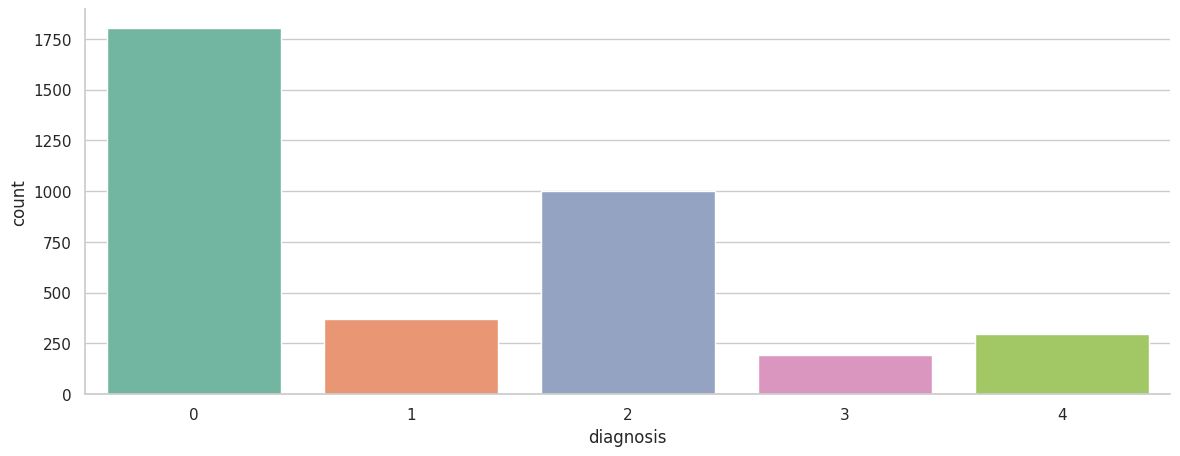

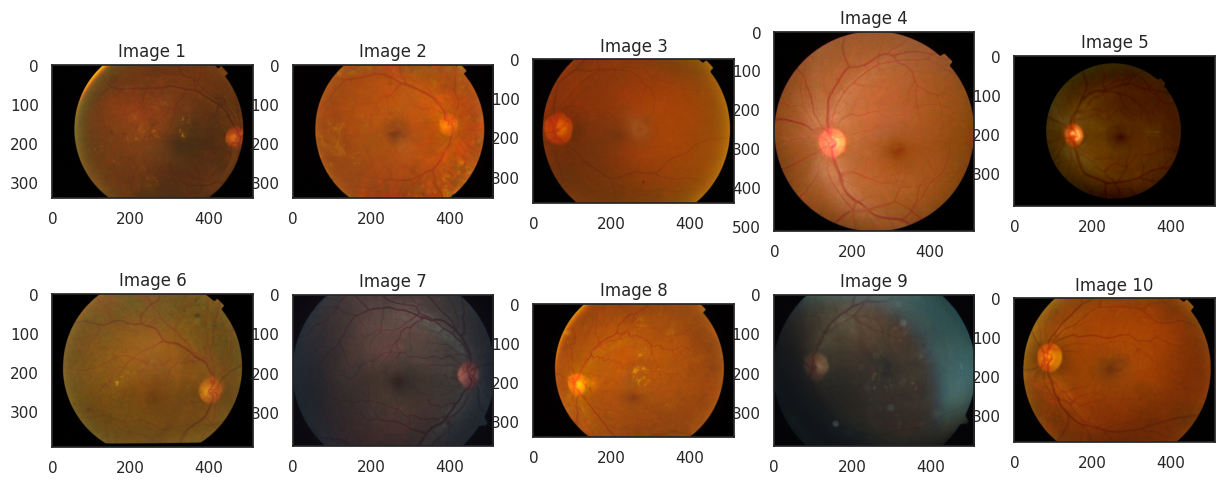

In [26]:
f, ax = plt.subplots(figsize=(14, 5))
# [개선] 기존: sns.countplot(x="diagnosis", data=train, palette="Set2")
#        → 최신 seaborn은 hue 없이 palette만 주면 FutureWarning. 같은 그림이 나오도록 hue와 legend=False 지정
ax = sns.countplot(x="diagnosis", hue="diagnosis", data=train, palette="Set2", legend=False)
sns.despine()
plt.show()

sns.set_style("white")
# [개선] 기존: count = =1 → SyntaxError
count = 1
plt.figure(figsize=[15, 15])
# [개선] 기존: for img_name in trainlid_code'][:10]: → 인쇄된 기호가 깨진 것으로 train['id_code']가 맞음
for img_name in train['id_code'][:10]:
    #img = cv2.imread("../input/aptos2019-blindness-detection/train_images/%s.png" % img_name)[..., [2, 1, 0]]
    img = cv2.imread(f"{DATA_DIR}/train_images/%s.png" % img_name)[..., [2, 1, 0]]
    plt.subplot(5, 5, count)
    plt.imshow(img)
    plt.title("Image %s" % count)
    count += 1

plt.show()


# → 진단 단계(0~4)별 사진 수를 막대그래프로 그려 불균형 정도를 확인하겠다
# → 표의 처음 10장을 읽어 5×5 격자에 차례로 그려, 사진이 실제로 어떻게 생겼는지 눈으로 보겠다

먼저, 학습 데이터의 진단 값(`diagnosis`) 분포를 시각화합니다. `sns.countplot`을 사용하여 각 진단 단계별 샘플 수를 막대그래프로 표시하며, `palette="Set2"`로 그래프의 색상을 설정합니다. 그래프의 크기는 `figsize=(14, 5)`로 설정하여 가독성을 높입니다. 이 과정은 데이터셋이 클래스 불균형 문제를 가지고 있는지 확인하는 데 유용하며, 이후 모델 학습에서 데이터 증강이나 클래스 가중치 조정이 필요한지 판단하는 기준을 제공합니다. `sns.despine()`은 그래프 테두리의 불필요한 축선을 제거하여 깔끔한 시각화를 돕습니다.

다음으로, 학습 데이터에서 첫 10개의 이미지를 시각화합니다. `train['id_code']`에서 이미지 파일 이름을 가져와, `cv2.imread`로 해당 이미지를 불러옵니다. 이미지의 색상 순서를 맞추기 위해 `[..., [2, 1, 0]]`을 사용하여 RGB로 변환합니다. `plt.subplot`으로 5x5 격자형 서브플롯을 생성하여 이미지를 배치하고, `plt.title`로 각 이미지에 번호를 부여하여 표시합니다. `plt.figure(figsize=[15, 15])`는 전체 플롯의 크기를 설정하여 모든 이미지가 명확히 보이도록 합니다.

이 코드는 데이터셋의 구성과 품질을 확인하기 위해, 각 클래스의 샘플 분포와 이미지 내용을 시각적으로 분석합니다. 이를 통해 데이터가 학습에 적합한지, 전처리 또는 증강이 필요한지를 판단할 수 있습니다. 클래스 불균형 문제가 있을 경우, 데이터 증강이나 클래스 가중치 설정 등의 해결 방법을 고려해야 합니다. 또한, 이미지를 확인하면서 데이터에 손상된 이미지나 노이즈가 포함되어 있는지도 확인할 수 있습니다. 이 과정은 모델 학습 전에 데이터셋을 이해하고 준비하는 데 필수적입니다.

**결과 미리 보기 — 막대그래프**

APTOS 2019 학습 데이터의 실제 분포는 다음과 같습니다. 그래프에서도 0번 막대가 압도적으로 길게 나옵니다.

| 단계 | 0 정상 | 1 경증 | 2 중등도 | 3 중증 | 4 증식성 | 합계 |
|---|---|---|---|---|---|---|
| 사진 수 | 1,805 | 370 | 999 | 193 | 295 | 3,662 |
| 비율 | 49.3% | 10.1% | 27.3% | 5.3% | 8.1% | 100% |

중증(3)은 정상(0)의 약 1/9밖에 안 됩니다. 모델이 아무 생각 없이 전부 "정상"이라고 답해도 정확도가 약 49%가 나오므로, **정확도 50% 근처는 사실상 아무것도 배우지 못한 수준**이라는 기준으로 삼으면 됩니다.

**코드 설명 — `[..., [2, 1, 0]]`**: `cv2.imread`는 사진을 BGR(파랑·초록·빨강) 순서로 읽고, `plt.imshow`는 RGB 순서로 그립니다. `[..., [2, 1, 0]]`은 "앞의 차원(세로·가로)은 그대로(`...`) 두고, 색 채널만 2번·1번·0번 순서로 다시 줄 세우라"는 뜻이라 BGR이 RGB로 바뀝니다. 이걸 빼면 붉은 망막이 파랗게 보입니다.

**결과 해석 — 단계별 사진 수와 사진 미리보기**

- 막대그래프는 위 **결과 미리 보기**의 표와 똑같은 모양입니다. 0단계(정상) 1,805장이 압도적으로 많고, 3단계(중증) 193장이 가장 적습니다. 앞의 Step 5 CNN이 기록한 정확도 0.46∼0.50이 바로 <strong>"전부 정상이라고 답하는 수준"</strong>이었다는 것을 이 그래프로 다시 확인할 수 있습니다.
- 미리보기 사진 10장은 **밝기·색·가로세로 비율이 제각각**입니다(사진마다 축 눈금이 다름). 7번처럼 어둡고 푸른빛이 도는 사진, 9번처럼 테두리가 잘린 사진도 있습니다. 병원마다 촬영 장비와 조명이 다르기 때문이며, 바로 아래의 Ben Graham 전처리가 이 차이를 줄이기 위한 과정입니다.
- 이 사진들은 실행 설정 셀에서 긴 변 512픽셀로 줄인 사진이라 축 눈금이 500 안팎까지만 나옵니다. 원본은 가로 2,000∼4,000픽셀입니다.

아래 코드는 데이터셋의 진단 클래스 개수를 파악하고, 학습 데이터의 형식을 모델 학습에 적합하도록 변환하는 과정을 보여줍니다.

In [27]:
# [개선] 기존: train[diagnosis'].nunique) → 따옴표와 괄호가 빠짐
N_CLASSES = train['diagnosis'].nunique()
N_CLASSES

NUM_CLASSS = 5
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")
train['diagnosis'] = train['diagnosis'].astype('str')
display(train.head())
display(train.tail())


# → 정답 종류가 몇 개인지 세고(5), 파일 이름에 .png를 붙이고 정답을 글자로 바꾼 뒤 결과를 확인하겠다

,id_code,diagnosis
0,000c1434d8d7.png,2
1,001639a390f0.png,4
2,0024cdab0c1e.png,1
3,002c21358ce6.png,0
4,005b95c28852.png,0


,id_code,diagnosis
3657,ffa47f6a7bf4.png,2
3658,ffc04fed30e6.png,0
3659,ffcf7b45f213.png,2
3660,ffd97f8cd5aa.png,0
3661,ffec9a18a3ce.png,2


먼저, `train['diagnosis'].nunique()`는 데이터셋에서 고유한 진단 클래스의 개수를 계산합니다. 이 값은 `N_CLASSES`에 저장되며, 모델의 출력층에서 분류해야 하는 클래스 수와 동일합니다. 또한, `NUM_CLASSS = 5`로 전체 진단 클래스의 개수를 명시적으로 설정하여 모델 학습에 활용할 수 있도록 준비합니다.

다음으로, 이미지 파일 이름에 확장자를 추가하는 변환을 수행합니다. `train["id_code"].apply(lambda x: x+".png")`는 각 `id_code` 값에 `".png"`를 추가하여 이미지 파일 경로로 변환합니다. 이는 이미지 데이터를 불러오는 과정에서 사용됩니다.

진단 데이터를 문자열 형식으로 변환하기 위해 `train['diagnosis'] = train['diagnosis'].astype('str')`를 사용합니다. 이는 이미지 데이터 증강 라이브러리(ImageDataGenerator)나 모델 학습에 적합한 데이터 형식을 보장하기 위한 단계입니다.

마지막으로, `train.head()`와 `train.tail()`을 사용하여 데이터프레임의 앞부분과 뒷부분을 확인합니다. 이를 통해 변환 작업이 제대로 수행되었는지, 데이터 형식이 모델 학습에 적합한지 점검할 수 있습니다.

이 코드는 데이터셋을 모델 학습 준비 상태로 변환하고, 진단 클래스 정보를 명확히 정의하여 이후 작업을 원활히 진행할 수 있도록 도와줍니다. 이러한 데이터 변환은 모델이 데이터를 효율적으로 처리할 수 있도록 보장하는 중요한 전처리 과정입니다.

> **참고 — 셀 안에서 값만 적은 줄은 마지막 줄만 화면에 나옵니다**
>
> 책 코드는 `N_CLASSES`, `train.head()`, `train.tail()`을 한 셀에 그냥 나열했는데, 노트북은 **셀의 마지막 줄 값만** 자동으로 보여 줍니다. 그래서 원래대로라면 `N_CLASSES`(5)와 `train.head()`는 화면에 나오지 않고 `train.tail()`만 보입니다. 앞뒤를 모두 확인할 수 있도록 `display()`로 감쌌습니다.
>
> **주의** — 이 셀을 **두 번 실행하면** 파일 이름이 `000c1434d8d7.png.png`처럼 확장자가 두 번 붙어서, 다음 단계에서 사진을 하나도 찾지 못합니다("Found 0 validated image filenames"). 다시 실행해야 한다면 위의 `train.csv` 읽기 셀부터 다시 실행하세요.

In [28]:
IMG_SIZE = 227
BATCH_SIZE = 16

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if (check_shape == 0):
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def load_ben_color(image, sigmaX=10):
    image = crop_image_from_gray(image).astype('uint8')
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    return image.astype('float32') / 255.

def preprocessing(image, sigmaX=10):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = crop_image_from_gray(image).astype('uint8')
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    # plt.imshow(image, cmap='gray')
    # [개선] 기존: 주석 없이 ax.set_title(...) → 함수 안에 ax가 없어 사진마다 NameError. 시각화용 코드라 주석 처리
    # ax.set_title('Label: %d-%d-%s' % (class_id, idx, row['id_code']))
    return image.astype('float32') / 255.


# → 검은 배경을 잘라 내는 함수, Ben Graham 기법 함수, 그리고 실제 학습에 쓸 preprocessing 함수를 정의하겠다
# → preprocessing은 BGR로 바꾸기 → 배경 자르기 → 227×227 → Ben Graham → 0~1 정규화 순서로 사진 한 장을 바꾼다

아래 코드는 이미지 전처리를 위한 함수들을 정의하며, CNN 모델 학습에 적합한 형태로 데이터를 준비하는 데 사용됩니다. 이 과정은 데이터의 품질을 개선하고, 모델이 이미지의 중요한 특징에 더 잘 집중하도록 돕습니다.

먼저, `IMG_SIZE`와 `BATCH_SIZE`는 이미지를 CNN 입력 크기에 맞게 조정하고 배치 크기를 설정합니다. 모든 이미지는 `(227, 227)` 크기로 변환되며, 각 배치에는 16개의 이미지가 포함됩니다.

**`crop_image_from_gray` 함수**는 이미지를 회색조로 변환한 후, 특정 임계값(`tol`) 이상인 영역만 추출합니다. 이미지가 단색(2차원)일 경우, 임계값보다 큰 픽셀로 구성된 마스크를 생성하고, 마스크가 참인 영역만 남깁니다. 이미지가 컬러(3차원)일 경우, 회색조 변환 후 마스크를 생성하여 RGB 채널 각각에 적용합니다. 이를 통해 이미지의 불필요한 배경을 제거하고 관심 영역을 강조합니다.

**`load_ben_color` 함수**는 Ben Graham 기법을 적용하여 이미지의 밝기와 대비를 조정합니다. 이 함수는 이미지를 회색조로 처리한 후, Gaussian Blur를 사용하여 부드럽게 처리합니다. 이후 원본 이미지와 가중치를 조합하여 명도와 대비를 향상시키고, `(227, 227)` 크기로 리사이즈합니다. 결과 이미지는 0∼1 범위로 정규화되어 반환됩니다. 이 과정은 조명 조건의 영향을 최소화하고, 모델 학습에 적합한 데이터 품질을 보장합니다.

**`preprocessing` 함수**는 추가적인 전처리를 수행하며, 이미지를 RGB에서 BGR로 변환합니다. 이후 `crop_image_from_gray`와 Gaussian Blur를 적용하여 이미지의 노이즈를 줄이고 주요 특징을 강조합니다. 마지막으로 이미지를 리사이즈하고 정규화하여 CNN 입력에 적합한 형태로 반환합니다.

이 함수들은 데이터 전처리 과정에서 조명 조건, 노이즈, 그리고 불필요한 배경의 영향을 줄이는 데 중점을 둡니다. 이렇게 처리된 이미지는 CNN 모델 학습에서 높은 성능을 발휘하도록 도와주며, 다양한 조명과 배경 조건에서도 일관된 결과를 제공할 수 있도록 준비됩니다. 이러한 전처리 과정은 모델 학습의 필수적인 준비 단계로, 데이터 품질이 최종 모델 성능에 크게 기여합니다.

**코드 설명 — Step 5의 자르기 함수와 다른 점**

| 코드 | 하는 일 |
|---|---|
| `img.ndim == 2` | `ndim`은 배열의 차원 수입니다. 2차원이면 흑백 사진(세로 × 가로), 3차원이면 컬러 사진(세로 × 가로 × 색)입니다. 흑백이면 회색 변환 없이 바로 마스크를 만듭니다. |
| `check_shape == 0` | 잘라 낸 결과의 세로 길이가 0이면(= 밝은 부분이 하나도 없는 사진) 자르지 않고 원본을 돌려줍니다. Step 5의 `if mask.any()`와 같은 역할입니다. |

또 책 본문은 `load_ben_color`가 "회색조로 처리한다"고 설명하지만, 실제 코드는 회색조 사진을 **자를 위치를 찾는 데만** 쓰고, Ben Graham 기법은 컬러 사진 3채널 각각에 적용합니다. 결과 사진은 회색 톤으로 보이지만 색 정보는 남아 있습니다. 아래 학습에서 실제로 쓰이는 함수는 `preprocessing`이고, `load_ben_color`는 정의만 되고 쓰이지 않습니다.

#### [추가] 전처리 전·후 사진 비교

책 Step 3에는 원본 사진(Original Image)과 전처리 후 사진(After Pre-processing)을 나란히 놓은 그림이 있습니다. 아래 셀은 방금 정의한 `preprocessing` 함수로 실제 APTOS 사진 4장을 바꿔서 같은 그림을 직접 만들어 봅니다. 학습 중에는 이 변환이 눈에 보이지 않게 일어나므로, 모델이 실제로 어떤 사진을 보고 배우는지 확인하는 데 도움이 됩니다.

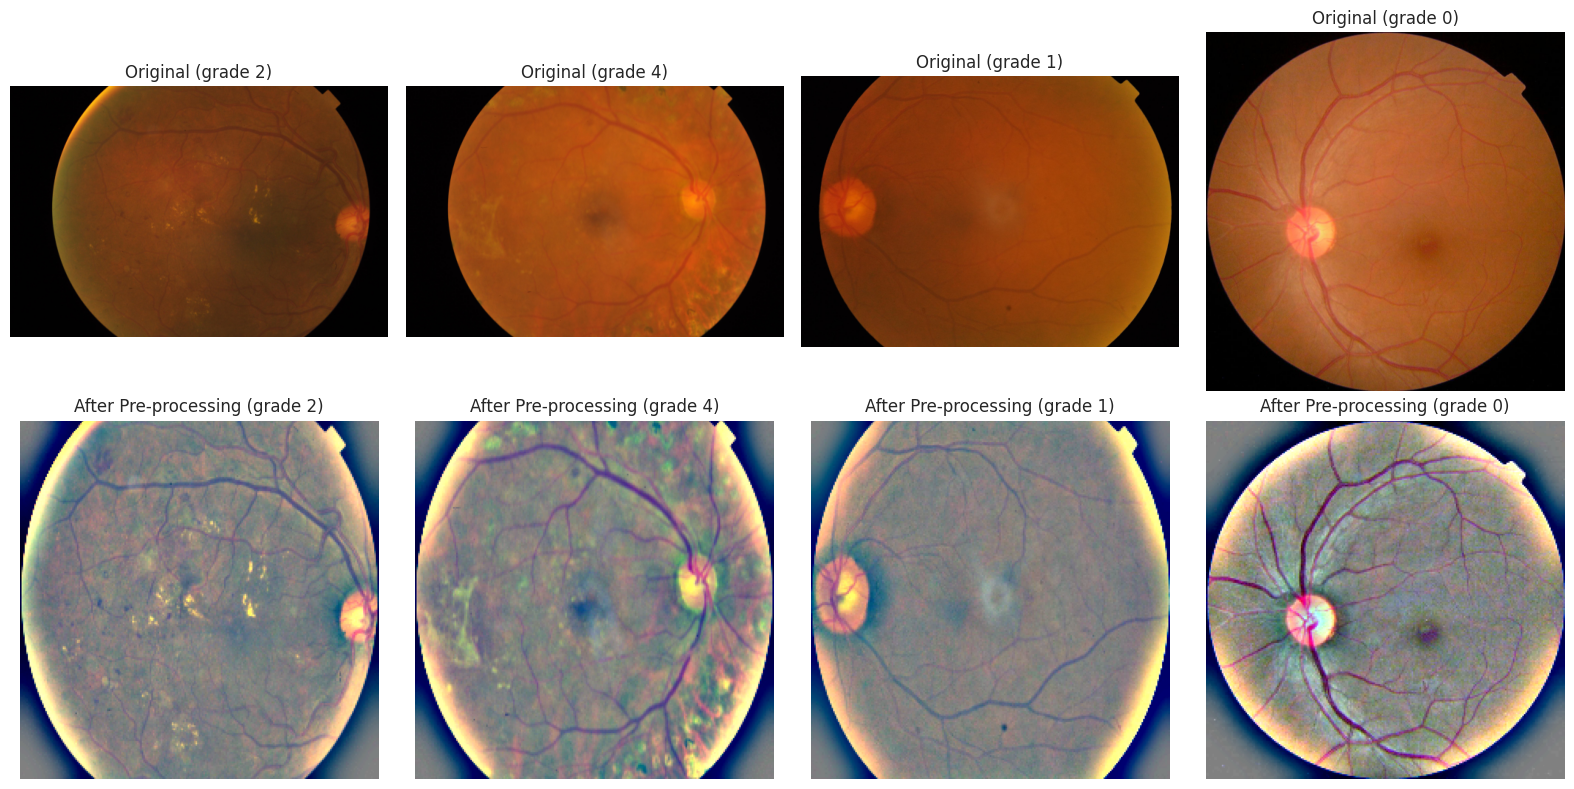

In [29]:
# [추가] 전처리 전·후 비교 — 책 Step 3의 "Original Image / After Pre-processing" 그림을 직접 만들어 보기


# ===== Sample images =====
# 정상(0)부터 증식성(4)까지 단계가 다른 사진을 고르기 위해, 단계별로 첫 사진을 하나씩 가져옴 (최대 4장)
sample = train.groupby('diagnosis').head(1).head(4)

plt.figure(figsize=(16, 8))
for i, (name, label) in enumerate(zip(sample['id_code'], sample['diagnosis'])):
    # cv2.imread: 사진을 BGR 순서로 읽음 → [..., ::-1]로 RGB로 뒤집어, ImageDataGenerator가 넘겨주는 순서와 맞춤
    # astype('float32'): ImageDataGenerator도 소수(float32)로 넘겨주므로 똑같은 조건을 만듦
    img = cv2.imread(f"{DATA_DIR}/train_images/{name}")[..., ::-1].astype('float32')
    # preprocessing: 배경 자르기 → 227×227 → Ben Graham → 0~1 정규화 (결과는 BGR 순서)
    after = preprocessing(img)

    # 윗줄: 원본 (0~255 정수로 바꿔야 imshow가 색을 제대로 그림)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.astype('uint8'))
    plt.title(f'Original (grade {label})')
    plt.axis('off')

    # 아랫줄: 전처리 후 (BGR → RGB로 다시 뒤집어 화면 색을 맞춤)
    plt.subplot(2, 4, i + 5)
    plt.imshow(after[..., ::-1])
    plt.title(f'After Pre-processing (grade {label})')
    plt.axis('off')

plt.tight_layout()
plt.show()


# → 단계가 다른 사진 4장을 골라, 윗줄에는 원본을, 아랫줄에는 preprocessing을 거친 모습을 나란히 그리겠다

> **그림 읽는 법**
>
> - **윗줄(원본)**: 사진마다 밝기와 색이 제각각이고, 망막 바깥에 검은 배경이 넓게 있습니다. 카메라·조명·환자에 따라 찍힌 조건이 다르다는 뜻입니다.
> - **아랫줄(전처리 후)**: 검은 배경이 잘려 나가 망막이 화면을 꽉 채우고, 전체가 회색 톤으로 바뀝니다. Ben Graham 기법이 조명 차이를 지우고(원본 − 흐린 사진) 주변과 다른 부분만 4배로 키웠기 때문에, **혈관과 점 모양의 병변(출혈·삼출물)이 또렷하게** 드러납니다.
> - 단계(grade)가 높은 사진일수록 아랫줄에서 밝거나 어두운 점·얼룩이 많이 보이는지 비교해 보세요. 모델은 이런 차이를 보고 단계를 구분하도록 배웁니다.
> - 원형 가장자리에 밝은 테두리가 생기는 것은 Ben Graham 기법의 부작용입니다. 망막과 검은 배경의 경계에서 밝기 차이가 커서 생기는 것으로, 병변이 아닙니다.

**결과 해석 — 전처리 전·후 비교**

- 이번 실행에서 무작위로 뽑힌 사진은 2·4·1·0단계입니다. 위의 **그림 읽는 법**대로, 아랫줄에서는 네 장 모두 색조가 회색 톤으로 통일되고 혈관(보라색 선)이 또렷해졌습니다.
- <strong>0단계(정상)</strong>는 깨끗한 혈관만 보이고 점이 거의 없는 반면, **2단계·4단계**에는 노란 점(삼출물)과 얼룩이 흩어져 있습니다. 원본(윗줄)에서는 거의 보이지 않던 차이입니다. 모델이 배워야 할 단서가 바로 이것입니다.
- <strong>1단계(경증)</strong>는 원본과 전처리 후 모두 정상과 구분하기 어렵습니다. 경증의 징후인 미세동맥류는 아주 작은 점이라, 512픽셀로 줄이고 다시 224·227픽셀로 줄이는 과정에서 거의 사라집니다. 뒤의 혼동행렬에서 경증 재현율이 낮게 나오는 이유 중 하나입니다.

### 3. 데이터 증강

아래 코드는 CNN 모델 학습에 적합한 형태로 데이터를 준비하기 위해 데이터 증강과 전처리를 수행합니다. 이를 위해 `ImageDataGenerator`를 사용하여 이미지 데이터를 실시간으로 변형하고, 다양한 조건에서 학습할 수 있도록 데이터를 준비합니다.

In [30]:
train_datagen = ImageDataGenerator(
    # [개선] 기존: rescale=1./255 → preprocessing이 이미 0~1로 만든 값을 또 255로 나눔 (Step 5 1번 개선 사항 참고)
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=360,
    zoom_range=0.2,
    shear_range=0.1,
    preprocessing_function=preprocessing
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    #directory='.',
    x_col="id_code",
    y_col="diagnosis",
    batch_size=16,
    class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE),
    subset='training'
)


# → 학습용 사진을 무작위로 뒤집고·돌리고·확대·기울인 뒤 preprocessing을 거쳐 16장씩 꺼내 주는 로더를 만들겠다

Found 2930 validated image filenames belonging to 5 classes.


`ImageDataGenerator`는 학습 데이터의 다양성을 증가시키는 동시에 정규화를 수행합니다. 먼저, `rescale=1./255`를 설정하여 모든 이미지 픽셀 값을 0에서 1 사이로 정규화하여 모델 학습에 적합하도록 변환합니다. 또한, `validation_split=0.2`를 사용하여 데이터의 20%를 검증용으로 분리하여 모델의 성능을 독립적으로 평가할 수 있는 환경을 만듭니다. 데이터 증강 기법으로는 `horizontal_flip`과 `vertical_flip`을 설정하여 이미지를 좌우 및 상하로 뒤집어 다양한 시각적 패턴을 학습할 수 있게 합니다. `rotation_range=360`은 이미지를 360도 범위에서 임의로 회전하여 모델이 다양한 방향성을 학습하도록 돕습니다. 이 외에도 `zoom_range=0.2`는 이미지 크기를 조정하고, `shear_range=0.1`은 이미지를 비대칭으로 기울여 데이터의 변형을 추가하여 모델의 일반화 성능을 높이는 데 기여합니다.

이와 함께 `preprocessing_function=preprocessing`을 설정하여 사용자 정의 전처리 함수인 `preprocessing`을 통합합니다. 이 함수는 Ben Graham 기법과 Gaussian Blur를 적용하여 이미지의 품질을 개선하며, 불필요한 배경을 제거하여 모델이 중요한 특징에 집중하도록 도와줍니다.

이후 `flow_from_dataframe`을 사용하여 학습 데이터를 배치 형태로 로드할 수 있는 데이터 로더를 생성합니다. 데이터는 `train` 데이터프레임에서 이미지 파일 경로와 라벨 정보를 가져오며, `directory`를 통해 이미지 파일의 위치를 지정합니다. `x_col`과 `y_col`은 각각 이미지 파일 이름과 라벨을 나타내며, `batch_size=16`으로 배치 크기를 설정합니다. `class_mode="categorical"`을 통해 다중 클래스 분류 문제를 지정하며, `target_size=(IMG_SIZE, IMG_SIZE)`는 이미지 크기를 `(227, 227)`로 조정하여 CNN 모델의 입력 크기에 맞춥니다. 마지막으로, `subset="training"`은 학습 데이터만 로드하도록 설정합니다.

이 코드는 데이터 증강과 전처리를 통해 학습 데이터의 품질과 다양성을 보장하며, CNN 모델이 더 나은 일반화 성능을 발휘할 수 있도록 준비합니다. 이를 통해 다양한 조건에서의 학습 데이터를 모델에 제공하여 과적합을 방지하고 학습의 효과를 극대화합니다.

> **개선 사항** — 위 본문은 원래 코드 기준이라 `rescale=1./255`를 설명하지만, 이 노트북에서는 Step 5와 같은 이유(0∼1로 만든 값을 한 번 더 255로 나누는 문제)로 `rescale`을 뺐습니다. 0∼1 정규화는 `preprocessing` 함수의 마지막 줄 `image.astype('float32') / 255.`에서 한 번만 일어납니다.

아래 코드는 검증 데이터를 처리하고 CNN 모델 학습 중 성능 평가에 사용할 데이터 로더를 생성하는 과정입니다. 이를 위해 `ImageDataGenerator`의 `flow_from_dataframe` 메서드를 사용하여 데이터를 실시간으로 로드하고 전처리합니다.

In [31]:
# [추가] 검증용: 증강 없이 전처리만 하는 생성기 (validation_split은 학습용과 똑같이 0.2)
valid_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=preprocessing
)

# [개선] 기존: train_datagen.flow_from_dataframe(preprocessing_function=preprocessing, ...)
#        → ① 검증 데이터에도 회전·반전 증강이 걸림 → valid_datagen으로 바꿈
#        → ② flow_from_dataframe은 preprocessing_function을 받지 않음(오류 없이 무시됨) → 삭제
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    batch_size=16,
    class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE),
    subset='validation'
)


# → 학습용과 겹치지 않는 20%의 사진을, 증강 없이 전처리만 해서 16장씩 꺼내 주는 검증용 로더를 만들겠다

Found 732 validated image filenames belonging to 5 classes.


검증 데이터는 학습 데이터와 별도로 설정되며, 모델의 일반화 성능을 평가하는 데 중요한 역할을 합니다. `subset='validation'`을 통해 `ImageDataGenerator`에서 미리 정의한 검증 데이터 분할을 가져옵니다. 이 데이터는 `validation_split=0.2`로 설정된 학습 데이터의 20%를 포함하며, 학습 데이터와 겹치지 않도록 분리됩니다.

`preprocessing_function=preprocessing`을 설정하여 사용자 정의 전처리 함수인 `preprocessing`을 활용합니다. 이 함수는 이미지를 전처리하여 학습 모델에 적합한 품질로 변환합니다. Ben Graham 기법과 Gaussian Blur를 적용하여 이미지의 품질을 높이고, 불필요한 배경을 제거하여 모델이 중요한 특징에 집중할 수 있도록 도와줍니다.

`flow_from_dataframe` 메서드는 검증 데이터를 배치 형태로 로드합니다. `dataframe`은 데이터 파일 이름과 라벨 정보를 포함한 `train` 데이터프레임을 지정하며, `directory`는 이미지 파일의 실제 저장 경로를 나타냅니다. `x_col`은 이미지 파일 이름을, `y_col`은 진단 라벨을 지정합니다. `batch_size=16`은 데이터 배치를 16개 단위로 분할하며, 모델이 한 번에 처리할 데이터의 크기를 조정합니다. `class_mode="categorical"`을 설정하여 다중 클래스 분류 문제로 지정하며, `target_size=(IMG_SIZE, IMG_SIZE)`은 이미지 크기를 `(227, 227)`로 조정하여 모델 입력 크기와 맞춥니다.

이 설정은 검증 데이터를 정규화하고 전처리하여 학습 모델의 성능 평가에 사용할 준비를 마칩니다. 검증 데이터는 학습 중 모델의 일반화 성능을 확인하는 데 사용되며, 과적합 여부를 판단하고 학습 과정을 조정하는 데 중요한 역할을 합니다. 이 데이터 로더를 통해 모델 학습 중 검증 데이터에서의 성능을 실시간으로 모니터링할 수 있습니다.

> **개선 사항 — `preprocessing_function`을 넣는 위치**
>
> `preprocessing_function`은 **`ImageDataGenerator(...)`를 만들 때** 넣는 설정이고, `flow_from_dataframe(...)`에는 이런 이름의 매개변수가 없습니다. 그런데도 원래 코드가 오류 없이 돌아갔던 이유는, `flow_from_dataframe`이 모르는 이름의 값을 **조용히 무시**하기 때문입니다. 원래 코드에서 검증 사진에 전처리가 적용된 것은 이 줄 덕분이 아니라 `train_datagen`에 이미 전처리가 들어 있었기 때문입니다. 오해를 줄이기 위해 이 줄을 지우고, 전처리는 `valid_datagen`에 넣었습니다.
>
> 또 Keras는 `validation_split`으로 나눌 때 표의 **앞쪽 20%를 검증용, 나머지 80%를 학습용**으로 씁니다. 무작위로 고르는 것이 아니므로, 같은 `validation_split` 값을 준 두 생성기는 항상 같은 사진들로 나뉩니다.

### 4. CNN 모델

아래 코드는 CNN(합성곱 신경망) 모델을 설계하는 과정으로, 입력 이미지를 기반으로 5개의 클래스(정상, 경증, 중등도, 중증, 증식성 DR)를 분류하는 다중 클래스 분류 모델을 정의합니다. 모델은 Keras의 `Sequential` 클래스를 기반으로 작성되었으며, 합성곱 층, 풀링 층, 그리고 완전 연결 층으로 구성됩니다.

In [32]:
from keras.layers import Conv2D, MaxPooling2D

model0 = Sequential()

# [개선] 기존: 첫 Conv2D에 input_shape=(IMG_SIZE, IMG_SIZE, 3) → Keras 3 권장 방식인 Input 층으로 바꿈
model0.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Convolutional layers
model0.add(Conv2D(32, (3, 3), activation='relu'))
model0.add(Conv2D(32, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

model0.add(Conv2D(64, (5, 5), activation='relu'))
model0.add(Conv2D(64, (5, 5), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

model0.add(Conv2D(128, (5, 5), activation='relu'))
model0.add(Conv2D(128, (5, 5), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

model0.add(Conv2D(256, (3, 3), activation='relu'))
model0.add(Conv2D(256, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

model0.add(Conv2D(512, (3, 3), activation='relu'))
model0.add(Conv2D(512, (3, 3), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))

model0.add(Conv2D(1024, (1, 1), activation='relu'))
model0.add(Conv2D(1024, (1, 1), activation='relu'))
model0.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(MaxPooling2D(pool_size=(3, 3)))

# Flatten layer
model0.add(Flatten())

# Dense layers
model0.add(Dense(32, activation='relu'))
model0.add(Dropout(0.5))

# Output layer with 5 classes
model0.add(Dense(5, activation='softmax'))

# [개선] 기존: model0.summary) → 여는 괄호가 빠짐
model0.summary()


# → Step 5의 5블록 CNN에 1×1 합성곱 1024개짜리 블록을 하나 더 붙인 6블록 CNN을 만들겠다
# → 마지막에 Dense(32) → Dropout → Dense(5, softmax)로 5단계 확률을 내겠다

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 225, 225, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 223, 223, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 107, 107, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 103, 103, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 47, 47, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 43, 43, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 19, 19, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 1024)     │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 2, 2, 1024)     │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,621 (25.98 MB)

 Trainable params: 6,811,621 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

모델의 첫 부분은 합성곱 블록으로 구성됩니다. 각 블록은 두 개의 `Conv2D` 레이어와 하나의 `MaxPooling2D` 레이어를 포함합니다. 합성곱 층은 이미지의 지역적 특징을 학습하며, 각 레이어는 필터 크기와 개수를 점진적으로 증가시켜 이미지의 저차원부터 고차원 특징까지 학습할 수 있도록 설계되었습니다. 첫 번째 블록에서는 32개의 `(3, 3)` 필터를 사용하며, 이후 블록에서는 필터 개수를 64, 128, 256, 512, 1024로 점진적으로 증가시킵니다. 이 과정에서 필터 크기는 `(3, 3)`과 `(5, 5)`를 혼합하여 다양한 크기의 특징을 학습하도록 설정하였습니다. 각 블록의 마지막에 있는 풀링 층(MaxPooling2D)은 공간적 크기를 축소하여 계산량을 줄이고, 모델이 학습하는 주요 특징을 강조합니다.

다음으로, `Flatten` 층은 합성곱과 풀링 과정을 거쳐 생성된 3차원 특징 맵을 펼쳐 1차원 벡터로 변환합니다. 이 벡터는 완전 연결 층(`Dense`)에 전달되어 최종 분류 작업을 수행합니다. 완전 연결 층은 32개의 뉴런을 가지며, `ReLU` 활성화 함수를 통해 비선형성을 추가합니다. 과적합을 방지하기 위해 `Dropout` 층이 추가되어 일부 뉴런의 출력을 랜덤하게 0으로 설정합니다. 마지막 출력 층은 5개의 뉴런을 가지며, `softmax` 활성화 함수를 사용하여 각 클래스에 대한 확률 분포를 반환합니다.

이 모델 구조는 입력 이미지를 단계적으로 처리하며, 중요한 특징을 학습하고 이를 기반으로 정확한 예측을 수행하도록 설계되었습니다. 마지막으로 `model0.summary()`를 호출하여 모델의 전체 구조와 각 층의 세부 정보를 출력합니다. 이 CNN 모델은 당뇨병성 망막병증(DR) 진단과 같은 복잡한 이미지 분류 문제를 해결하기 위한 강력한 구조를 제공합니다.

**코드 설명 — 6번째 블록(1×1 합성곱)이 하는 일**

Step 5 3번의 크기 표와 같은 계산으로 5번째 블록 뒤의 크기는 **2 × 2 × 512**입니다. 여기에 6번째 블록이 붙습니다.

| 층 | 출력 크기 | 설명 |
|---|---|---|
| Conv2D(1024, 1×1) × 2 | 2 × 2 × 1024 | 1×1 필터는 가로·세로는 그대로 두고, **같은 위치의 채널 512개를 섞어** 1024개의 새 특징을 만듭니다. |
| MaxPooling2D(2, 2) | 1 × 1 × 1024 | 2×2 중 최댓값만 남겨 위치 정보가 사라지고, "이 사진에 어떤 특징이 있는가"만 남습니다. |
| Flatten | 1,024 | 위 표(Step 3 커스텀 CNN 표)의 FC_1(1024 × 1)과 숫자가 맞아떨어집니다. |

파라미터 수가 가장 많은 층은 `Conv2D(1024, 1×1)` 두 번째 층(1024 × 1024 + 1024 = 약 105만 개)입니다. `summary()` 표의 `Param #` 열에서 확인할 수 있습니다.

### 5. 모델 학습 및 성능 평가

아래 코드는 F1 점수를 계산하기 위한 사용자 정의 함수로, 모델의 정밀도와 재현율을 결합하여 성능을 평가합니다. F1 점수는 특히 데이터가 불균형한 상황에서 유용한 지표로, 모델의 예측 성능을 종합적으로 나타냅니다.

In [33]:
from keras import ops

#taken from old keras source code
# [개선] 기존: K.sum, K.round, K.clip → Keras 3의 keras.backend(K)에서 삭제된 함수라 호출하면 AttributeError
#        같은 계산을 하는 keras.ops 함수로 바꿈 (K.epsilon()은 Keras 3에도 남아 있음)
def f1_score(y_true, y_pred):
    true_positives = ops.sum(ops.round(ops.clip(y_true * y_pred, 0, 1)))
    possible_positives = ops.sum(ops.round(ops.clip(y_true, 0, 1)))
    predicted_positives = ops.sum(ops.round(ops.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    # [개선] 기존: K.epsilon) → 여는 괄호가 빠짐
    f1_val = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_val


# → 정답과 예측을 0/1로 반올림해 맞힌 개수(TP)를 세고, 정밀도·재현율을 구한 뒤 그 조화평균(F1)을 돌려주겠다
# → 0으로 나누는 일을 막기 위해 분모마다 아주 작은 수 K.epsilon()(약 0.0000001)을 더하겠다

이 함수는 먼저 모델이 올바르게 예측한 긍정 클래스의 수를 계산하여 `true_positives`에 저장합니다. 이는 실제 값(`y_true`)과 예측 값(`y_pred`)의 곱을 이용해 얻으며, 값을 0과 1로 제한한 후 반올림합니다. 이후, 실제 긍정 클래스의 전체 개수를 `possible_positives`에, 모델이 긍정으로 예측한 전체 개수를 `predicted_positives`에 각각 계산합니다.

정밀도는 모델이 긍정으로 예측한 값 중 실제로 긍정인 비율로, `true_positives`를 `predicted_positives`로 나누어 계산합니다. 재현율은 실제 긍정 클래스 중 모델이 올바르게 예측한 비율로, `true_positives`를 `possible_positives`로 나누어 구합니다. 마지막으로, 정밀도와 재현율의 조화 평균을 계산하여 F1 점수를 반환합니다. 이 값은 모델이 긍정 클래스를 얼마나 잘 예측하는지 종합적으로 보여줍니다.

또한, 함수는 Keras 백엔드의 `K.epsilon()`을 사용하여 0으로 나누는 상황을 방지합니다. 이 함수는 모델 학습 과정에서 사용자 정의 메트릭으로 설정되어, 정확도 이외의 성능을 평가하거나 과적합과 과소적합을 판단하는 데 중요한 정보를 제공합니다. F1 점수는 특히 분류 문제에서 모델의 예측 성능을 더 균형 잡힌 방식으로 측정하는 데 유용합니다.

> **참고 — 이 함수는 정의만 되고 실제로는 쓰이지 않습니다**
>
> 책 본문은 "사용자 정의 메트릭으로 설정되어"라고 하지만, 아래 `compile`의 `metrics=METRICS`에는 `f1_score`가 들어 있지 않습니다. 쓰고 싶다면 `METRICS` 리스트 끝에 `f1_score`를 추가하면 됩니다.
>
> 이름도 주의하세요. 이 셀이 위 1번에서 불러온 scikit-learn의 `f1_score`(`from sklearn.metrics import ... f1_score`)를 **같은 이름으로 덮어씁니다.** 이 셀 이후에 `f1_score(y_test, y_pred)`처럼 scikit-learn 방식으로 쓰면 다른 함수가 불려 나옵니다.
>
> **`keras.ops`란?** Keras 3는 TensorFlow뿐 아니라 PyTorch·JAX 위에서도 돌아가도록 바뀌면서, 텐서 계산 함수를 `keras.ops`라는 한 곳에 모았습니다. `ops.sum`(합), `ops.round`(반올림), `ops.clip`(범위 자르기)은 옛 `K.sum`, `K.round`, `K.clip`과 같은 일을 합니다.

아래 코드는 모델 학습 과정에서 성능 평가와 학습률 조정을 효율적으로 수행하기 위해 설정된 메트릭 및 콜백을 보여줍니다.

In [34]:
METRICS = [
    # [개선] 기존: tf.keras.metrics.BinaryAccuracy(name='accuracy')
    #        → 5단계 분류(원-핫 정답)에서는 칸마다 0/1을 맞혔는지 따로 세어 정확도가 부풀려짐. 아래 개선 사항 참고
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
]

lrd = ReduceLROnPlateau(monitor='val_loss', patience=2, verbose=1, factor=0.8, min_lr=1e-6)


# → 학습 중 정확도·정밀도·재현율·AUC 네 가지를 함께 기록하고, 검증 손실이 2에포크 연속 안 줄면 학습률을 80%로 낮추겠다

먼저, `METRICS` 리스트는 모델 학습 중 평가에 사용될 다양한 지표를 정의합니다. 이러한 메트릭은 모델 성능을 다각도로 분석하는 데 도움이 됩니다.

- **`BinaryAccuracy`**: 전체 예측 중에서 올바르게 분류된 비율을 나타냅니다. 이름을 `'accuracy'`로 설정하여 학습 과정에서 확인할 수 있습니다.
- **`Precision`**: 모델이 긍정 클래스로 예측한 것 중 실제로 긍정 클래스인 샘플의 비율을 계산합니다.
- **`Recall`**: 실제 긍정 클래스 샘플 중에서 모델이 올바르게 예측한 비율을 나타냅니다.
- **`AUC`**: ROC(Receiver Operating Characteristic) 곡선 아래 영역으로, 분류 경계의 민감도와 특이도 간의 균형을 평가합니다.

이러한 메트릭은 각각 모델의 정확도, 세부 분류 성능, 재현율, 그리고 전체적인 분류 능력을 평가하는 데 사용되며, 학습 중 출력되어 모델 성능을 실시간으로 모니터링할 수 있습니다.

다음으로, `ReduceLROnPlateau`는 학습 중 검증 손실(`val_loss`)이 개선되지 않을 경우 학습률을 동적으로 조정하는 콜백입니다.

- <strong>`monitor='val_loss'`</strong>는 검증 손실을 모니터링하도록 설정합니다.
- <strong>`patience=2`</strong>는 손실이 개선되지 않는 에포크 수를 2로 설정하여, 2회 연속 개선이 없을 경우 학습률을 조정합니다.
- <strong>`factor=0.8`</strong>는 학습률을 기존의 80%로 감소시켜 모델이 더 세밀하게 최적화를 수행하도록 돕습니다.
- <strong>`min_lr=1e-6`</strong>는 학습률이 너무 작아져 학습이 중단되지 않도록 최소 학습률을 설정합니다.

`ReduceLROnPlateau`는 학습 초기에는 빠르게, 후반에는 느리게 학습하는 데 유용하며, 특히 손실 감소가 정체될 때 모델이 더욱 효과적으로 최적화를 계속할 수 있도록 합니다. 이러한 메트릭과 콜백 설정은 모델 학습의 안정성과 효율성을 보장하는 데 중요한 역할을 합니다.

**개선 사항 — 5단계 분류에 `BinaryAccuracy`를 쓰면 정확도가 부풀려지는 이유**

`BinaryAccuracy`는 예측 확률을 0.5 기준으로 0/1로 바꾼 뒤 **칸마다** 정답과 같은지 세어 평균을 냅니다. 원-핫 정답은 5칸 중 4칸이 0이므로, 모델이 아무것도 모르고 <strong>모든 칸을 0으로 예측해도 5칸 중 4칸을 맞혀 정확도 80%</strong>가 나옵니다.

| 정답(중등도) | 예측 확률 | 0.5 기준 | 칸별로 맞았나 |
|---|---|---|---|
| `[0, 0, 1, 0, 0]` | `[0.4, 0.1, 0.3, 0.1, 0.1]` | `[0, 0, 0, 0, 0]` | ○ ○ × ○ ○ |

이 사진은 실제로는 **틀렸는데**(가장 높은 확률은 정상 0.4) `BinaryAccuracy`로는 80% 맞은 것으로 계산됩니다. `CategoricalAccuracy`는 **가장 확률이 높은 칸이 정답 칸과 같은지**만 보므로 이 사진은 0점입니다. 5단계 중 하나를 고르는 이 문제에는 `CategoricalAccuracy`가 맞는 지표라서 바꿨습니다(이름은 `'accuracy'` 그대로라 아래 그래프 코드는 바꿀 필요가 없습니다). Step 5에서 쓴 문자열 `'accuracy'`도 Keras가 자동으로 `CategoricalAccuracy`로 계산합니다.

`Precision`, `Recall`, `AUC`는 이런 문제가 없는 것은 아니지만(5칸을 모두 합쳐 하나의 이진 문제처럼 계산함), 모델끼리 비교하는 용도로는 쓸 만하므로 책 그대로 두었습니다.

아래 코드는 딥러닝 모델을 학습하는 과정에서 중간 결과물을 안전하게 보관하기 위한 설정을 하는 코드입니다.

In [35]:
# [개선] 기존: mcp = 'D:/testRun/CNN.hdf5' → Keras 3는 .hdf5 확장자를 허용하지 않아 ValueError. 같은 형식의 .h5로 바꿈
mcp = f'{SAVE_DIR}/CNN.h5'
# [개선] 기존: ModelCheckpoint(mcp, verbose=1, period=20, save_freq='epoch')
#        → period는 Keras 3에서 삭제되어 TypeError. 검증 손실이 가장 낮을 때만 저장하도록 바꿈(아래 개선 사항 참고)
modelcheckpoint = ModelCheckpoint(mcp, verbose=1, monitor='val_loss', save_best_only=True, save_freq='epoch')


# → 매 에포크가 끝날 때 검증 손실을 확인해, 지금까지 중 가장 낮으면 SAVE_DIR/CNN.h5에 모델을 덮어써서 저장하겠다
# → 이 파일은 Step 7의 앙상블에서 다시 불러온다

구체적으로는 D 드라이브의 `testRun` 폴더 안에 `CNN.hdf5`라는 이름으로 모델 파일이 저장되도록 경로를 지정합니다. 이때 HDF5 형식을 사용하는데, 이는 대용량의 딥러닝 모델 데이터를 저장하기에 적합한 파일 형식입니다. ModelCheckpoint 기능을 통해 학습 중인 모델의 상태를 주기적으로 저장하게 되는데, 20번의 학습 주기(에포크)마다 한 번씩 자동으로 저장이 이루어집니다. 또한 저장이 진행될 때마다 콘솔 창에 진행 상황이 표시되어 사용자가 저장 시점을 실시간으로 확인할 수 있습니다. 이러한 주기적인 저장은 긴 학습 과정 중에 예기치 않은 시스템 오류가 발생하더라도 중간 결과물을 안전하게 보존할 수 있게 해주며, 필요할 때 이전 상태의 모델을 다시 불러와 학습을 재개하거나 모델을 재사용할 수 있게 해줍니다.

**개선 사항 — `period=20`과 `.hdf5`**

| 기존 | 문제 | 개선 |
|---|---|---|
| `'CNN.hdf5'` | Keras 3는 모델 전체를 저장할 때 `.keras`(새 형식) 또는 `.h5`(옛 HDF5 형식)만 허용하므로 `ValueError` | `'CNN.h5'` — `.hdf5`와 `.h5`는 이름만 다를 뿐 **같은 HDF5 형식**입니다. Step 7에서 `load_model`로 그대로 불러올 수 있습니다. |
| `period=20` | "20에포크마다 저장" 설정은 TensorFlow 2.x 초기에 이미 없어질 예정이었고 Keras 3에서 삭제되어 `TypeError` | `save_best_only=True` — 매 에포크 검증 손실을 보고, **가장 좋았던 모델만** 남깁니다. |

`save_best_only=True`를 고른 이유: 20에포크마다 저장하면 마지막 파일은 100에포크째 모델인데, 그 사이 과적합이 생겼다면 그 모델이 가장 좋은 모델이 아닐 수 있습니다. Step 7의 앙상블은 이 파일을 불러와 쓰므로, **검증 성적이 가장 좋았던 순간의 모델**을 쓰는 편이 책의 의도("최적의 모델 저장")에도 맞습니다.

본문의 "HDFS 형식"은 HDF5의 오타입니다. HDF5(Hierarchical Data Format 5)는 큰 숫자 배열을 폴더 구조처럼 정리해 담는 파일 형식이고, HDFS는 하둡(Hadoop)의 분산 파일 시스템이라는 전혀 다른 기술입니다.

아래 코드는 딥러닝 모델의 학습 과정을 설정하고 실행하는 부분입니다. 먼저 EarlyStopping을 통해 모델의 성능이 2번의 에포크 동안 개선되지 않으면 학습을 조기 종료하도록 설정합니다.

In [36]:
#es = EarlyStopping(verbose=1, patience=2)

# [개선] 기존: metrics METRICS) → = 가 빠짐
model0.compile(optimizer='Adam', loss="categorical_crossentropy", metrics=METRICS)

# [개선] 기존: STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size (2930 // 16 = 183)
#        → 실제 묶음은 184개(마지막 묶음 2장). Keras 3는 남은 1묶음을 다음 에포크로 넘기고 그 에포크를
#          1묶음만 학습한 채 끝내서, 에포크가 '전체 → 1묶음 → 전체 → …'로 번갈아 반쪽이 됨 (Kaggle 실행 기록 13번)
#        → len(생성기)로 묶음 수를 그대로 써서 매 에포크 사진 전체를 한 바퀴씩 보게 함
STEP_SIZE_TRAIN = len(train_generator)
STEP_SIZE_VALID = len(valid_generator)

# [개선] 기존: model0.fit_generator(generator=train_generator, ...)
#        → fit_generator는 Keras 3에서 삭제되어 AttributeError. fit이 생성기를 그대로 받으므로 이름만 바꿈
# [개선] 에포크: 기존 epochs=100 → 실행 설정 셀의 EPOCHS 사용 / verbose=2: 에포크당 한 줄만 출력
history0 = model0.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN, validation_data=valid_generator, validation_steps=STEP_SIZE_VALID, epochs=EPOCHS, verbose=2, callbacks=[lrd, modelcheckpoint])


# → Adam과 categorical_crossentropy로 모델을 준비하고, EPOCHS(책: 100)에포크 동안 학습하면서 학습률 조정과 최고 모델 저장을 함께 하겠다
# → 에포크마다의 손실과 지표 기록은 history0에 담기고, 아래 그래프 셀에서 사용한다

Epoch 1/30

Epoch 1: val_loss improved from None to 1.33947, saving model to /kaggle/working/CNN.h5

Epoch 1: finished saving model to /kaggle/working/CNN.h5
184/184 - 93s - 507ms/step - accuracy: 0.4464 - auc: 0.7282 - loss: 1.4465 - precision: 0.4812 - recall: 0.0437 - val_accuracy: 0.4604 - val_auc: 0.7391 - val_loss: 1.3395 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 1.33947 to 1.33043, saving model to /kaggle/working/CNN.h5

Epoch 2: finished saving model to /kaggle/working/CNN.h5
184/184 - 78s - 425ms/step - accuracy: 0.4792 - auc: 0.7616 - loss: 1.3415 - precision: 0.5136 - recall: 0.1485 - val_accuracy: 0.4604 - val_auc: 0.7565 - val_loss: 1.3304 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_loss improved from 1.33043 to 1.32092, saving model to /kaggle/working/CNN.h5

Epoch 3: finished saving model to /kaggle/working/CNN.h5
184/184 - 78s - 424ms/

모델의 컴파일 과정에서는 Adam 옵티마이저와 `categorical_crossentropy` 손실 함수를 사용하며, 평가 지표로는 `METRICS`에 정의된 항목들을 사용합니다. 학습 데이터와 검증 데이터의 배치 크기를 계산하여 `STEP_SIZE_TRAIN`과 `STEP_SIZE_VALID` 변수에 저장합니다. 이후 `model.fit_generator`를 통해 실제 학습을 진행하는데, 훈련 데이터 생성기(`train_generator`)와 검증 데이터 생성기(`valid_generator`)를 사용하여 100 에포크 동안 학습을 수행합니다.

이 과정에서 학습률 조정(`lrd`)과 모델 체크포인트(`modelcheckpoint`) 콜백 함수들이 함께 적용되어 학습 과정을 모니터링하고 최적화합니다. 학습이 완료된 후의 전체 학습 기록은 `history0` 변수에 저장됩니다.

**참고 — 본문과 코드가 다른 점: EarlyStopping**

본문은 "EarlyStopping을 통해 … 조기 종료하도록 설정한다"고 하지만, 책 코드의 `es` 줄은 맨 앞에 `#`이 붙은 **주석**이라 실행되지 않고, `callbacks=[lrd, modelcheckpoint]`에도 들어 있지 않습니다. 그래서 실제로는 100에포크를 끝까지 학습합니다. 책 코드를 그대로 두었습니다.

조기 종료를 쓰고 싶다면 아래처럼 바꾸면 됩니다. 다만 `patience=2`는 `ReduceLROnPlateau`(역시 2)와 같아서, 학습률을 낮춰 볼 기회도 없이 멈출 수 있습니다. 조기 종료의 `patience`는 학습률 조정보다 넉넉하게(예: 6) 잡는 것이 일반적입니다.

```python
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
history0 = model0.fit(..., callbacks=[lrd, modelcheckpoint, es])
```

`restore_best_weights=True`는 멈출 때 가장 좋았던 에포크의 가중치로 되돌려 놓으라는 설정입니다.

**결과 해석 — Step 6 CNN 학습 로그**

| 에포크 | accuracy | val_accuracy | loss | val_loss | val_precision |
|---|---|---|---|---|---|
| 1 | 0.45 | 0.4604 | 1.45 | 1.34 | 0 |
| 30 | 0.5010 | 0.4604 | 1.30 | 1.32 | 0 |

- Step 6의 CNN은 Step 5에 1×1 합성곱 블록을 하나 더 붙인 구조인데, 결과는 **Step 5와 완전히 같습니다.** 검증 정확도 0.4604(= 모두 정상), 학습 정확도 0.5010(= 학습 데이터의 정상 비율), 손실 약 1.30(= 비율만 외운 모델의 손실)입니다.
- 층을 더 깊게 쌓는다고 해결되지 않았다는 점이 중요합니다. 문제는 깊이가 아니라 <strong>처음부터 학습하는 깊은 CNN을 안정시키는 장치(BatchNormalization, 알맞은 학습률, 클래스 불균형 처리)</strong>가 없다는 데 있습니다.

아래 코드는 학습이 완료된 CNN 모델을 사용하여 특징을 추출하는 과정입니다.

In [37]:
# [추가] 특징 추출용 데이터 로더: 증강 없이, 순서를 섞지 않고(shuffle=False) 읽음 (Step 5 5번 개선 사항 참고)
train_eval_generator = valid_datagen.flow_from_dataframe(
    dataframe=train, directory=f"{DATA_DIR}/train_images/",
    x_col="id_code", y_col="diagnosis", batch_size=16, class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE), subset='training', shuffle=False
)
valid_eval_generator = valid_datagen.flow_from_dataframe(
    dataframe=train, directory=f"{DATA_DIR}/train_images/",
    x_col="id_code", y_col="diagnosis", batch_size=16, class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE), subset='validation', shuffle=False
)

# [개선] 출력층(확률 5개) 대신 바로 앞 Dense(32) 층의 출력을 특징으로 사용 (뒤에서 세 번째 층)
feature_extractor = Model(inputs=model0.inputs, outputs=model0.layers[-3].output)

# Extract features from the trained CNN model
# [개선] 기존: mode10.predict(train_generator) → 인쇄본의 model0 오타. 증강·셔플이 없는 로더와 특징 추출기로 바꿈
train_features = feature_extractor.predict(train_eval_generator)
valid_features = feature_extractor.predict(valid_eval_generator)


# → 학습이 끝난 CNN을 Dense(32) 층까지만 잘라, 학습용·검증용 사진을 각각 32개 숫자(특징)로 바꾸겠다
# → shuffle=False이므로 특징이 표의 순서대로 나와 정답(.labels)과 짝이 맞는다

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.
184/184 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step


`model0.predict` 함수를 사용하여 훈련 데이터셋(`train_generator`)과 검증 데이터셋(`valid_generator`)에서 특징을 추출합니다. 추출된 특징들은 각각 `train_features`와 `valid_features` 변수에 저장됩니다. 이렇게 추출된 특징들은 후속 분석이나 다른 머신러닝 모델의 입력으로 활용될 수 있으며, 데이터의 고차원적인 패턴을 압축된 형태로 표현합니다.

> **개선 사항** — Step 5의 5번에서 설명한 두 가지 문제(① 셔플·증강 때문에 특징과 정답의 순서가 어긋남, ② `predict`가 특징이 아니라 5단계 확률을 돌려줌)가 이 코드에도 똑같이 있어서 같은 방법으로 고쳤습니다. 자세한 이유는 Step 5의 **5. 특징 추출 및 J48 분류기 학습** 아래 개선 사항 블록을 참고하세요.

아래 코드는 CNN 모델에서 추출한 특징들을 결정 트리 분류기에 입력하기 위해 평탄화(flatten)하는 과정입니다.

In [38]:
# Flatten the features for input to the decision tree classifier
# [개선] 기존: train_features_flattened np.reshape(...) → = 가 빠짐
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
valid_features_flattened = np.reshape(valid_features, (valid_features.shape[0], -1))

print(train_features_flattened.shape, valid_features_flattened.shape)


# → 특징 배열을 (사진 수, 특징 수) 모양의 2차원 표로 펴고, 그 모양을 출력해 확인하겠다

(2930, 32) (732, 32)


`numpy`의 `reshape` 함수를 사용하여 다차원 구조의 특징 데이터를 2차원 배열로 변환합니다. 훈련 데이터(`train_features`)와 검증 데이터(`valid_features`)를 각각 평탄화하여 `train_features_flattened`와 `valid_features_flattened`에 저장합니다. 이렇게 변환된 데이터는 첫 번째 차원은 샘플의 수를 유지하고, 나머지 차원들은 하나의 긴 벡터로 펼쳐져 결정 트리와 같은 전통적인 머신러닝 알고리즘의 입력으로 사용하기 적합한 형태가 됩니다.

> **코드 설명 — `reshape(..., (개수, -1))`의 `-1`**
>
> `-1`은 "나머지는 알아서 맞춰라"는 뜻입니다. 사진 수(`shape[0]`)는 그대로 두고, 나머지 차원을 전부 곱해 한 줄로 폅니다. Dense(32) 층의 출력은 이미 `(2930, 32)` 모양의 2차원이라 이 셀을 지나도 모양이 바뀌지 않지만, 합성곱 층 출력처럼 `(사진 수, 세로, 가로, 채널)` 모양의 특징을 쓸 때를 대비한 안전장치입니다. 출력은 `(2930, 32) (732, 32)`처럼 나옵니다.

아래 코드는 J48 결정 트리 분류기를 생성하고 학습시키는 과정을 나타내는 중요한 부분입니다. 먼저 `DecisionTreeClassifier()`를 호출하여 J48 결정 트리 알고리즘을 기반으로 한 분류기를 초기화합니다. 이 분류기는 데이터를 트리 구조로 표현하여 분류 결정을 내리는 알고리즘입니다.

In [39]:
# [개선] 기존 셀에는 import가 없어 NameError(이 Step의 1번 import 목록에도 없음) → 불러오기 추가
from sklearn.tree import DecisionTreeClassifier

# Train a J48 decision tree classifier
# [개선] 기존: Decision TreeClassifier() → 인쇄본의 띄어쓰기 오타
j48_classifier = DecisionTreeClassifier()
# [개선] 기존: train_generator.labels → 특징을 뽑은 순서와 같은 train_eval_generator.labels 사용
j48_classifier.fit(train_features_flattened, train_eval_generator.labels)


# → 사진마다 32개 특징과 정답(0~4)을 짝지어 결정 트리를 학습시키겠다

DecisionTreeClassifier()

`fit` 메서드를 사용하여 분류기를 학습시키는데, 이때 두 가지 중요한 입력이 사용됩니다. 첫 번째는 `train_features_flattened`로, 이는 앞서 CNN에서 추출하고 평탄화한 특징 데이터입니다. 두 번째는 `train_generator.labels`로, 각 데이터의 실제 클래스 레이블을 나타냅니다.

학습 과정에서 결정 트리는 데이터의 특징들을 분석하여 가장 효과적인 분류 기준을 자동으로 찾아냅니다. 이는 마치 스무고개 게임처럼 각 노드에서 '예/아니오' 질문을 통해 데이터를 점차적으로 분류해나가는 구조를 만듭니다. 이렇게 학습된 결정 트리는 CNN의 복잡한 특징 추출 결과를 사람이 이해하기 쉬운 규칙 기반 구조로 변환해주는 역할을 합니다.

이는 특히 머신러닝 모델의 결정 과정을 해석하고 설명해야 하는 의료, 금융 등의 분야에서 매우 유용하게 활용될 수 있습니다. CNN이 추출한 고차원의 추상적인 특징들을 결정 트리가 논리적인 규칙으로 재해석함으로써, 모델의 판단 근거를 보다 명확하게 이해할 수 있게 해주기 때문입니다.

> **참고 — "해석 가능하다"의 한계**
>
> 결정 트리의 규칙은 "특징 17번 값이 0.83보다 크면 → 중등도" 같은 모양입니다. 규칙 자체는 읽을 수 있지만, **"특징 17번"이 망막의 무엇(출혈? 혈관?)을 뜻하는지는 CNN 안에 숨어 있어서** 사람이 바로 알 수는 없습니다. 그래서 의료 AI에서 판단 근거를 보여 줄 때는 Grad-CAM(사진의 어느 부분을 보고 판단했는지 색으로 칠해 보여 주는 방법)처럼 사진 위에 직접 표시하는 방법을 함께 쓰는 경우가 많습니다.

아래 코드는 학습된 J48 결정 트리 분류기의 성능을 평가하는 과정입니다. `score` 메서드를 사용하여 훈련 데이터와 검증 데이터에 대한 정확도를 각각 계산합니다.

In [40]:
# [개선] 기존: train_generator.labels / valid_generator.labels → 특징과 순서가 같은 eval 로더의 labels 사용
train_accuracy = j48_classifier.score(train_features_flattened, train_eval_generator.labels)
valid_accuracy = j48_classifier.score(valid_features_flattened, valid_eval_generator.labels)

# [개선] 기존: {:2f}(점 빠짐), valid_accuracy 100(곱하기 빠짐) → {:.2f}, * 100
print("J48 Classifier Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("J48 Classifier Validation Accuracy: {:.2f}%".format(valid_accuracy * 100))


# → 학습용·검증용 특징으로 결정 트리의 정확도를 각각 구해, 소수점 둘째 자리까지 백분율로 출력하겠다

J48 Classifier Training Accuracy: 50.10%
J48 Classifier Validation Accuracy: 46.04%


훈련 데이터에 대한 정확도는 평탄화된 훈련 특징(`train_features_flattened`)과 해당 레이블(`train_generator.labels`)을 사용하여 측정하고, 이를 `train_accuracy`에 저장합니다. 마찬가지로 검증 데이터에 대한 정확도는 평탄화된 검증 특징(`valid_features_flattened`)과 해당 레이블(`valid_generator.labels`)을 사용하여 측정하고, `valid_accuracy`에 저장합니다.

마지막으로 `format` 함수를 사용하여 계산된 정확도를 백분율로 변환하고 소수점 둘째 자리까지 표시하여 출력합니다. 이 결과를 통해 모델이 훈련 데이터와 처음 보는 검증 데이터에 대해 얼마나 잘 분류하는지 비교할 수 있으며, 이는 모델의 일반화 성능을 평가하는 중요한 지표가 됩니다.

> **결과 읽는 법** — 깊이 제한이 없는 결정 트리는 학습 데이터를 끝까지 갈라 외울 수 있어서 <strong>학습 정확도는 거의 100%</strong>가 나오는 것이 정상입니다. 중요한 것은 **검증 정확도**이고, 두 값의 차이가 클수록 과적합이 심하다는 뜻입니다. 검증 정확도를 CNN 자체의 `val_accuracy`(history0의 마지막 값들)와 비교해 보면, 결정 트리를 덧붙인 것이 실제로 도움이 되었는지 판단할 수 있습니다.

**결과 해석 — Step 6 J48**

| | 학습 데이터 | 검증 데이터 |
|---|---|---|
| J48 정확도 | 50.10% | **46.04%** |

위 **결과 읽는 법**에서는 "학습 정확도는 거의 100%가 정상"이라고 했지만, 실제로는 <strong>50.10%</strong>에 그쳤습니다. Step 5와 같은 이유로, CNN의 `Dense(32)` 층이 사진이 달라도 거의 같은 32개 숫자만 내놓아서 결정 트리가 나눌 기준을 찾지 못한 것입니다. 검증 정확도 46.04%도 "모두 정상" 수준입니다.

특징 추출기(CNN)가 제대로 학습되지 않으면 그 뒤에 붙인 분류기도 성능을 낼 수 없다는 점을 두 번 확인한 셈입니다. "CNN으로 특징을 뽑고 J48로 분류한다"는 책의 아이디어는, CNN이 먼저 사진을 구분하는 법을 배운 뒤에야 의미가 있습니다.

아래 코드는 딥러닝 모델의 학습 과정에서 기록된 정확도 변화를 시각화하는 그래프를 생성하는 과정입니다.

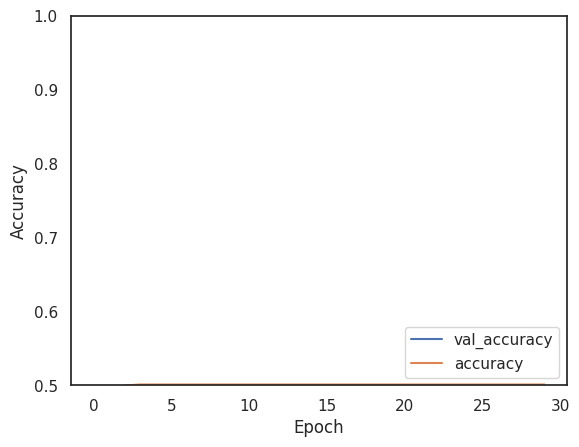

In [41]:
# [개선] 기존: history.history[...] → 이 Step에서 학습 기록을 담은 변수는 history0 (history는 Step 5의 변수)
plt.plot(history0.history['val_accuracy'], label='val_accuracy')
plt.plot(history0.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()


# → 에포크마다 기록된 학습 정확도와 검증 정확도를 선 두 개로 그려, y축은 0.5~1 구간만 보이게 하겠다

matplotlib의 `plot` 함수를 사용하여 에포크에 따른 훈련 정확도와 검증 정확도를 함께 그래프로 표시합니다. 파란색 선은 훈련 데이터에 대한 정확도(accuracy)를, 주황색 선은 검증 데이터에 대한 정확도(val_accuracy)를 나타냅니다. x축은 'Epoch'로 학습 진행 단계를, y축은 'Accuracy'로 정확도를 표시하며, y축의 범위는 0.5에서 1.0으로 설정되어 있습니다. 그래프의 오른쪽 아래에는 범례가 위치하여 각 선이 어떤 정확도를 나타내는지 구분할 수 있게 해줍니다. 이 시각화를 통해 모델의 학습 진행 상황과 과적합 여부를 쉽게 파악할 수 있습니다.

> **참고 — 선 색깔과 y축 범위**
>
> - matplotlib은 먼저 그린 선을 파란색, 두 번째 선을 주황색으로 칠합니다. 코드에서 `val_accuracy`를 먼저 그리므로 실제로는 **파란색 = 검증 정확도, 주황색 = 학습 정확도**입니다. 본문의 색 설명은 반대로 되어 있으니 범례를 보고 구분하세요.
> - `plt.ylim([0.5, 1])`은 y축을 0.5∼1만 보여 줍니다. 앞에서 본 것처럼 이 데이터는 정확도 0.49가 "아무것도 못 배운 수준"이라, 학습 초반이나 학습이 잘 안 된 경우에는 **선이 그래프 아래로 사라져 보이지 않을 수 있습니다.** 그럴 때는 이 줄을 지우고 다시 그려 보세요.

**결과 해석 — 그래프가 비어 보이는 이유**

바로 위 **참고 — 선 색깔과 y축 범위**에서 말한 일이 실제로 일어났습니다. 오류가 아니라 **y축 범위 때문**입니다.

- 책 코드는 `plt.ylim([0.5, 1])`로 y축을 0.5∼1로 고정합니다.
- 학습 정확도(주황)는 0.45∼0.50이라 그래프 **바닥 테두리에 겹쳐** 잘 보이지 않고, 검증 정확도(파랑)는 0.4604라서 **범위 밖**이라 아예 그려지지 않습니다.
- `plt.ylim([0.4, 0.6])`으로 바꿔 다시 그리면 Step 5와 같은 평평한 두 선이 나타납니다. 책 코드를 그대로 두었으므로, 이 그래프는 "모델이 정확도 0.5를 넘지 못했다"는 결과로 읽으면 됩니다.

#### [추가] CNN 성적표 — 혼동행렬과 단계별 정밀도·재현율

책은 학습 곡선과 결정 트리 정확도까지만 보여 주지만, 의료 진단 모델은 **어떤 단계를 어떤 단계로 헷갈리는지**를 꼭 확인해야 합니다. 1장에서 했던 것처럼 혼동행렬과 단계별 성적표(classification report)를 만들어 봅니다. 마지막 에포크의 모델이 아니라, `ModelCheckpoint`가 저장해 둔 **검증 손실이 가장 낮았던 모델**(`CNN.h5`)로 평가합니다.

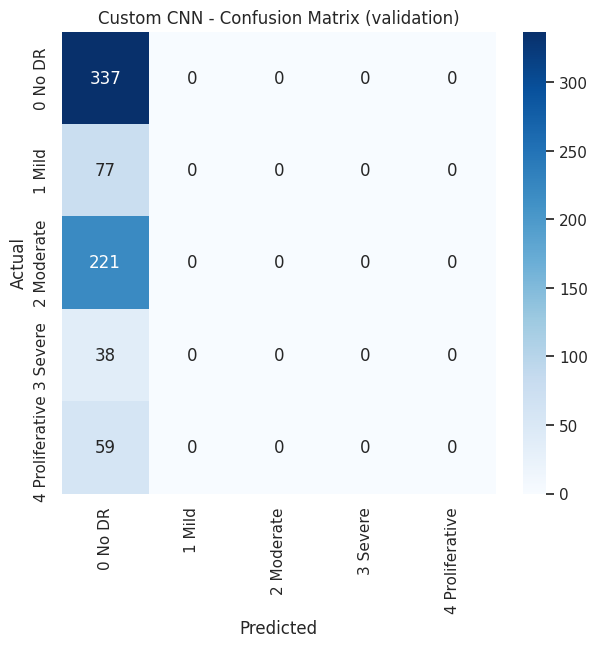

                 precision    recall  f1-score   support

        0 No DR      0.460     1.000     0.630       337
         1 Mild      0.000     0.000     0.000        77
     2 Moderate      0.000     0.000     0.000       221
       3 Severe      0.000     0.000     0.000        38
4 Proliferative      0.000     0.000     0.000        59

       accuracy                          0.460       732
      macro avg      0.092     0.200     0.126       732
   weighted avg      0.212     0.460     0.290       732



In [42]:
# [추가] 저장된 최고 CNN으로 검증 데이터를 평가해 혼동행렬과 단계별 성적표를 만듦


from sklearn.metrics import classification_report, confusion_matrix

# ===== Predict =====
# 학습 중 검증 손실이 가장 낮았던 모델을 파일에서 불러옴
best_cnn = load_model(mcp)
# predict(verbose=0): 진행 막대 없이 예측. 결과는 사진마다 5단계 확률 (사진 수, 5)
cnn_probs = best_cnn.predict(valid_eval_generator, verbose=0)
# argmax(axis=1): 5개 확률 중 가장 큰 칸 번호 = 예측한 단계
cnn_pred = cnn_probs.argmax(axis=1)
# labels: shuffle=False인 로더라서 예측 순서와 같은 순서의 정답
y_valid = np.array(valid_eval_generator.labels)

# 그래프에 쓸 단계 이름 (한글 폰트가 없는 Kaggle에서도 깨지지 않도록 영어로)
GRADE_NAMES = ['0 No DR', '1 Mild', '2 Moderate', '3 Severe', '4 Proliferative']

# ===== Confusion matrix =====
# labels=range(5): 혹시 어떤 단계가 예측에 한 번도 안 나와도 5×5 표를 유지
cm = confusion_matrix(y_valid, cnn_pred, labels=range(5))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GRADE_NAMES, yticklabels=GRADE_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Custom CNN - Confusion Matrix (validation)')
plt.show()

# ===== Classification report =====
# 단계마다 정밀도(precision)·재현율(recall)·F1·사진 수(support)를 표로 출력
# zero_division=0: 어떤 단계를 한 번도 예측하지 않아 분모가 0이 되면 경고 대신 0으로 표시
print(classification_report(y_valid, cnn_pred, labels=range(5), target_names=GRADE_NAMES, digits=3, zero_division=0))


# → 검증 손실이 가장 낮았던 CNN으로 검증 사진 732장을 예측하겠다
# → 실제 단계(세로)와 예측 단계(가로)를 5×5 표로 세어 색으로 칠하고, 단계별 정밀도·재현율·F1을 표로 출력하겠다

**혼동행렬·성적표 읽는 법**

| 보는 곳 | 뜻 |
|---|---|
| 대각선 칸(왼쪽 위 → 오른쪽 아래) | 맞힌 사진 수. 진할수록 좋습니다. |
| 대각선 바로 옆 칸 | 한 단계 차이로 헷갈린 경우(예: 중등도 → 중증). DR은 단계가 이어져 있어서 바로 옆 단계와 헷갈리는 건 비교적 흔합니다. |
| 대각선에서 먼 칸 | 크게 틀린 경우. 특히 **아래쪽 행(실제 중증·증식성)이 왼쪽 열(예측 정상)에 있으면** 위험한 환자를 정상으로 놓친 것이라 가장 주의해야 합니다. |
| `recall`(재현율) | 그 단계의 실제 사진 중 몇 %를 맞혔나. 사진 수가 적은 중증(3)은 보통 가장 낮게 나옵니다. |
| `precision`(정밀도) | 그 단계라고 예측한 사진 중 몇 %가 진짜였나 |
| `macro avg` | 다섯 단계 점수의 단순 평균. 사진이 적은 단계도 똑같이 반영되어 불균형 데이터의 실제 실력을 잘 보여 줍니다. |
| `weighted avg` | 사진 수로 가중한 평균. 정상(0)이 많아서 `macro avg`보다 높게 나오는 것이 보통입니다. |

**결과 해석 — 저장된 최고 CNN의 혼동행렬과 성적표**

<strong>혼동행렬(confusion matrix)</strong>은 세로줄이 실제 단계, 가로줄이 모델이 예측한 단계인 표입니다. 대각선 칸이 맞힌 개수입니다.

- 모든 사진이 맨 왼쪽 열(**예측 = 0 No DR**)에만 모여 있습니다: 실제 정상 337, 경증 77, 중등도 221, 중증 38, 증식성 59장이 전부 "정상"으로 예측되었습니다.
- 성적표에서 `0 No DR`의 재현율(recall)은 **1.000**(정상 337장을 모두 맞힘)이지만, 정밀도(precision)는 0.460입니다(정상이라고 한 732장 중 진짜 정상은 337장). 나머지 단계는 정밀도·재현율이 모두 0입니다.
- **macro avg**(다섯 단계 점수의 단순 평균)의 F1은 0.126, **weighted avg**(사진 수만큼 가중 평균)는 0.290입니다. 정확도 46%만 보면 "절반 가까이 맞힌다"고 오해하기 쉽지만, 단계별로 보면 병이 있는 사진은 **한 장도 찾아내지 못한** 모델입니다. 의료 데이터에서 정확도 하나만 보면 안 되는 대표적인 예입니다.

## Step 7. CNN을 이용한 코드 자세히 살펴보기

Step 6이 직접 설계한 CNN(커스텀 CNN)을 다뤘다면, Step 7은 ImageNet으로 미리 학습된 **InceptionV3와 VGG16을 가져와 전이 학습**시키고, 마지막에 Step 6의 CNN까지 세 모델을 합친 **앙상블 모델**을 만듭니다. Step 3의 시스템 구성도에서 오른쪽 절반(세 베이스 모델 → 앙상블)에 해당하는 부분입니다.

> **실행 순서 주의** — 6번(앙상블)은 Step 6에서 저장한 `CNN.h5`와 이 Step의 5번에서 저장하는 `inception.h5`, `model2.h5`를 불러옵니다. Step 6을 먼저 끝까지 실행해 두어야 합니다. 또 InceptionV3·VGG16은 처음 만들 때 ImageNet 가중치 파일(InceptionV3 약 90MB, VGG16 약 60MB)을 인터넷에서 내려받습니다.

In [43]:
# [추가] 실행 설정 — 에포크 수, 데이터 경로, 모델 저장 경로를 이 셀 한 곳에서 관리


import os
import glob

# ===== Epochs =====
# EPOCHS: 이 노트북의 모든 학습(fit)에 쓰는 에포크 수
# 책 원래 값: Step 5는 epochs=50, Step 6·7은 epochs=100
# Kaggle은 한 번 실행이 최대 12시간이라, 학습 5번(Step 5 CNN, Step 6 CNN, InceptionV3, VGG16, 앙상블)이 그 안에 끝나도록 줄여서 사용
EPOCHS = 30

# ===== Paths =====
# glob('/kaggle/input/**/train.csv', recursive=True): /kaggle/input 아래 모든 하위 폴더를 뒤져 train.csv 경로를 찾음
# 그중 옆에 train_images 폴더가 있는 것만 고름 (다른 데이터셋의 train.csv와 헷갈리지 않도록)
found = [p for p in glob.glob('/kaggle/input/**/train.csv', recursive=True)
         if os.path.isdir(os.path.join(os.path.dirname(p), 'train_images'))]
# DATA_DIR: Kaggle이면 찾은 폴더, 아니면(내 PC) C:/Dataset (책은 D:/Dataset)
DATA_DIR = os.path.dirname(found[0]) if found else 'C:/Dataset'
# SAVE_DIR: Kaggle에서 파일을 저장할 수 있는 곳은 /kaggle/working 뿐. 내 PC면 C:/testRun (책은 D:/testRun)
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else 'C:/testRun'

# os.makedirs(..., exist_ok=True): 저장 폴더가 없으면 새로 만들고, 이미 있으면 그냥 넘어감
os.makedirs(SAVE_DIR, exist_ok=True)

# ===== Image cache =====
# 원본 사진은 한 장이 가로 2,000~4,000픽셀이라, 학습 시간 대부분이 에포크마다 큰 사진을 다시 읽는 데 쓰임
# 처음 한 번만 긴 변 512픽셀로 줄여 따로 저장해 두고, 이후에는 이 작은 사진을 읽게 함 (모델 입력은 어차피 227·224)
import cv2
import shutil
from concurrent.futures import ThreadPoolExecutor

# CACHE_DIR: 줄인 사진을 둘 곳. Kaggle은 /tmp(실행이 끝나면 지워지는 임시 폴더), 내 PC는 C:/Dataset_512
CACHE_DIR = '/tmp/aptos_512' if found else 'C:/Dataset_512'
SRC_DIR = DATA_DIR

def shrink_image(name):
    dst = os.path.join(CACHE_DIR, 'train_images', name)
    # 이미 줄여 둔 사진이면 건너뜀 → 이 셀을 다시 실행해도(Step 6·7) 금방 끝남
    if os.path.exists(dst):
        return
    img = cv2.imread(os.path.join(SRC_DIR, 'train_images', name))
    h, w = img.shape[:2]
    # scale: 긴 변이 512가 되도록 줄이는 비율 (가로세로 비율은 그대로 유지)
    scale = 512 / max(h, w)
    if scale < 1:
        # INTER_AREA: 사진을 줄일 때 화질 손실이 가장 적은 방식
        img = cv2.resize(img, (round(w * scale), round(h * scale)), interpolation=cv2.INTER_AREA)
    cv2.imwrite(dst, img)

if os.path.exists(f'{SRC_DIR}/train.csv'):
    os.makedirs(f'{CACHE_DIR}/train_images', exist_ok=True)
    # train.csv도 같은 폴더에 복사해 두어, 아래 코드의 f'{DATA_DIR}/...' 경로를 그대로 쓸 수 있게 함
    shutil.copy(f'{SRC_DIR}/train.csv', f'{CACHE_DIR}/train.csv')
    names = os.listdir(f'{SRC_DIR}/train_images')
    # ThreadPoolExecutor: CPU 코어 수만큼 동시에 사진을 줄여 시간을 아낌
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
        list(ex.map(shrink_image, names))
    # 이후 모든 코드는 줄인 사진 폴더를 데이터 폴더로 사용
    DATA_DIR = CACHE_DIR
    print('줄인 사진 수:', len(os.listdir(f'{CACHE_DIR}/train_images')))
print('EPOCHS  :', EPOCHS)
print('DATA_DIR:', DATA_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('원본 위치:', SRC_DIR)
# os.path.exists(): 그 경로에 파일이 실제로 있는지 True/False로 알려 줌
print('train.csv 있음:', os.path.exists(f'{DATA_DIR}/train.csv'))
print('train_images 폴더 있음:', os.path.exists(f'{DATA_DIR}/train_images'))


# → Kaggle에서는 데이터 위치를 자동으로 찾고, 내 PC에서는 C:/Dataset을 쓰도록 하겠다
# → 처음 실행할 때 사진 3,662장을 긴 변 512픽셀로 줄여 두고(Kaggle 기준 몇 분), 이후 학습은 작은 사진을 읽어 훨씬 빠르게 하겠다
# → 모든 학습의 에포크 수를 EPOCHS 하나로 관리해, 시간이 넉넉하면 이 숫자만 100으로 바꾸면 되게 하겠다
# → 마지막 두 줄이 모두 True가 나와야 아래 셀들이 정상적으로 실행된다

줄인 사진 수: 3662
EPOCHS  : 30
DATA_DIR: /tmp/aptos_512
SAVE_DIR: /kaggle/working
원본 위치: /kaggle/input/competitions/aptos2019-blindness-detection
train.csv 있음: True
train_images 폴더 있음: True


### 1. 모듈 임포트

아래 코드는 딥러닝 프로젝트에 필요한 주요 라이브러리들을 임포트하는 과정입니다.

In [44]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam


# → 파일·배열·표 처리 도구와 전이 학습에 쓸 VGG16, 모델을 쌓는 층·콜백·옵티마이저를 불러오겠다

우선 기본적인 파일 및 데이터 처리를 위해 운영체제 관련 기능을 제공하는 `os`, 수치 연산을 위한 `numpy`, 데이터 프레임 처리를 위한 `pandas`를 임포트합니다. 머신러닝 데이터 분할을 위해 `sklearn`에서 `train_test_split`을 가져오고, 이미지 데이터 전처리와 증강을 위해 keras의 `ImageDataGenerator`를 임포트합니다.

딥러닝 모델 구성을 위해서는 사전 학습된 `VGG16` 모델과 `Sequential` 모델을 임포트하고, 모델 구조에 필요한 `Flatten`, `Dense`, `Dropout` 층들도 함께 가져옵니다. 또한 학습 과정에서 모델을 저장하기 위한 `ModelCheckpoint`와 모델 최적화를 위한 `Adam` 옵티마이저도 임포트합니다. 이러한 라이브러리들은 이미지 분류를 위한 딥러닝 모델을 구축하고 훈련하는데 필수적인 도구들입니다.

아래 코드는 데이터 분석과 처리에 필수적인 두 가지 핵심 라이브러리를 임포트하는 과정입니다.

In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# → Kaggle 노트북 기본 셀처럼 numpy와 pandas를 불러오겠다

`numpy` 라이브러리는 `np`라는 별칭으로 임포트되며, 주석에 표시된 것처럼 선형대수 연산을 위해 사용됩니다. 이는 행렬 연산, 다차원 배열 처리 등의 수치 계산에 특화되어 있습니다. `pandas` 라이브러리는 `pd`라는 별칭으로 임포트되며, 데이터 처리와 CSV 파일의 입출력을 담당합니다. 특히 pandas는 데이터프레임이라는 구조를 통해 표 형태의 데이터를 효율적으로 다룰 수 있게 해주며, CSV 파일을 읽고 쓰는 기능을 제공합니다.

아래 코드는 특정 디렉토리 경로에 있는 모든 파일들을 탐색하고 출력하는 과정입니다. `os.walk` 함수를 사용하여 `/kaggle/input` 디렉토리와 그 하위 디렉토리들을 순회합니다.

In [46]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    # [개선] 기존: for filename in filenames: print(os.path.join(dirname, filename))
    #        → Kaggle에서는 사진 경로가 5,600줄 가까이 출력되어 노트북·HTML이 매우 길어짐. 폴더별 파일 개수만 출력
    print(dirname, '→ 파일', len(filenames), '개')


# → /kaggle/input 아래 폴더마다 파일 개수를 출력하겠다 (내 PC에서는 폴더가 없어 아무것도 출력되지 않음)

/kaggle/input → 파일 0 개
/kaggle/input/competitions → 파일 0 개
/kaggle/input/competitions/aptos2019-blindness-detection → 파일 3 개
/kaggle/input/competitions/aptos2019-blindness-detection/train_images → 파일 3662 개
/kaggle/input/competitions/aptos2019-blindness-detection/test_images → 파일 1928 개


이때 `os.walk`는 각 디렉토리에 대해 디렉토리 경로(`dirname`), 하위 디렉토리 목록(`_`), 파일 목록(`filenames`)을 반환합니다. 중첩된 for 루프를 통해 각 디렉토리의 모든 파일에 대해 `os.path.join`을 사용하여 전체 경로를 생성하고, 이를 출력합니다. 이 코드는 주로 데이터 분석 프로젝트에서 사용 가능한 데이터 파일들을 확인하는데 활용됩니다.

> **용어 풀이 — 변수 이름 `_`** — 파이썬에서 `_`는 "값을 받긴 하지만 쓰지 않겠다"는 표시로 쓰는 관례적인 이름입니다. `os.walk`는 매번 (폴더 경로, 하위 폴더 목록, 파일 목록) 세 개를 돌려주는데, 여기서는 하위 폴더 목록이 필요 없어서 `_`로 받았습니다.

아래 코드는 딥러닝과 데이터 분석 프로젝트에 필요한 다양한 라이브러리들을 임포트하는 광범위한 설정 과정입니다. 이를 주요 카테고리별로 나누어 설명하면 다음과 같습니다.

In [47]:
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import random
import os
import gc # garbage collector
import datetime
from tqdm import tqdm
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint, TensorBoard
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import backend as K
from keras import Input
from keras.models import Model
from keras.utils import *
from keras.layers import *
import tensorflow
tensorflow.random.set_seed(2)
import matplotlib.pyplot as plt
np.random.seed(0)
import os
import gc
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers
from tensorflow.keras.optimizers import Adam
# [개선] 기존 책 인쇄본: from keras.callbacks Callback, ModelCheckpoint, ReduceLROnPlateau → import가 빠져 SyntaxError
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
# [개선] 기존: from keras.wrappers.scikit_learn import KerasClassifier → Keras 3에서 삭제되어 ModuleNotFoundError
# from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K
from typing import Optional
# [개선] 기존: get_ipython().run_line_magic('matplotlib', 'inline') → 같은 뜻의 매직 명령으로 바꿈
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")
# [개선] 기존: from keras.preprocessing.image import ImageDataGenerator → Keras 3에서 ImportError
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# → Step 6에서 여러 셀로 나눠 불러왔던 라이브러리를 한 셀에 모두 불러오고, 난수 시드·그래프 스타일·경고 숨기기를 설정하겠다

기본적인 데이터 처리와 시각화를 위해 `pandas`, `numpy`, `matplotlib`, `seaborn` 라이브러리를 임포트합니다. 이들은 데이터 조작, 수치 계산, 그래프 생성에 필수적입니다.

시스템 및 유틸리티 기능을 위해 `random`, `os`, `gc`(가비지 컬렉터), `datetime`, `tqdm` 라이브러리를 가져옵니다. 이들은 파일 처리, 메모리 관리, 진행 상황 표시 등을 담당합니다.

이미지 처리와 머신러닝을 위해 OpenCV(`cv2`)와 scikit-learn의 다양한 도구들을 임포트합니다. 이들은 이미지 처리와 모델 평가에 사용됩니다.

딥러닝 모델 구축을 위해 TensorFlow와 Keras의 다양한 컴포넌트들을 가져옵니다. 여기에는 모델 구조, 레이어, 콜백 함수, 데이터 전처리 도구들이 포함됩니다. 또한 ResNet50과 같은 사전 학습된 모델도 임포트됩니다.

마지막으로 코드의 안정성과 재현성을 위해 랜덤 시드를 설정하고, 경고 메시지를 숨기며, 시각화 스타일을 설정합니다. 이러한 포괄적인 라이브러리 설정은 복잡한 딥러닝 프로젝트를 수행하는데 필요한 모든 도구를 사용할 수 있게 해줍니다.

> **개선 사항** — Step 6의 1번과 같은 이유로 `keras.preprocessing.image`(4곳), `keras.wrappers.scikit_learn`, 빠진 `import`, `get_ipython()` 줄을 고쳤습니다. 책 원래 코드에 들어 있던 중복 import(같은 라이브러리를 여러 번 불러오는 줄)는 실행에 문제가 없어서 그대로 두었습니다. 파이썬은 이미 불러온 모듈을 다시 불러오라고 하면 저장해 둔 것을 그대로 쓰므로 시간도 거의 들지 않습니다.

### 2. 데이터 로드 및 전처리

아래 코드는 데이터셋을 불러오고 기본적인 정보를 확인하는 과정입니다. 먼저 `'D:/Dataset'`을 기본 경로로 설정하고, 같은 위치에 있는 `train.csv` 파일을 pandas의 `read_csv` 함수를 사용하여 불러와 `train` 변수에 저장합니다.

In [48]:
# [개선] 기존: PATH = 'D:/Dataset', pd.read_csv(D:/Dataset/train.csv') → 따옴표 누락 수정, 실행 설정 셀의 DATA_DIR 사용
PATH = DATA_DIR
train = pd.read_csv(f'{DATA_DIR}/train.csv')
print('Number of train samples:', train.shape[0])
display(train.head())
display(train.tail())


# → train.csv를 새로 읽어 사진 수를 출력하고, 표의 앞뒤 5줄을 보여 주겠다

Number of train samples: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


,id_code,diagnosis
3657,ffa47f6a7bf4,2
3658,ffc04fed30e6,0
3659,ffcf7b45f213,2
3660,ffd97f8cd5aa,0
3661,ffec9a18a3ce,2


그 다음으로 훈련 데이터의 샘플 수를 확인하기 위해 `train.shape[0]`을 출력합니다. `shape[0]`은 데이터프레임의 행 수를 반환하므로, 이를 통해 전체 훈련 데이터의 크기를 알 수 있습니다.

마지막으로 `display` 함수를 사용하여 데이터프레임의 처음 5개 행(head)과 마지막 5개 행(tail)을 출력합니다. 이를 통해 데이터의 구조와 내용을 빠르게 파악할 수 있으며, 데이터가 올바르게 로드되었는지 확인할 수 있습니다.

아래 코드는 의료 진단 데이터의 분포를 시각화하고 데이터를 전처리하는 과정입니다.

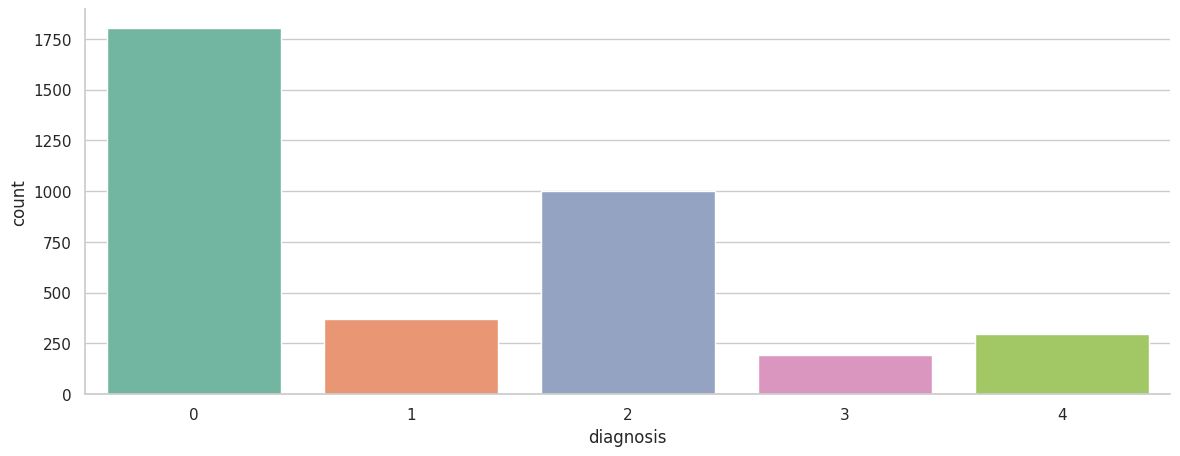

In [49]:
# [개선] 기존: fax = plt.subplots(...) → 인쇄본에서 "f, ax"의 쉼표·공백이 빠진 오타
f, ax = plt.subplots(figsize=(14, 5))
# [개선] 기존: palette만 지정 → 최신 seaborn의 FutureWarning을 없애려고 hue와 legend=False 추가 (그림은 같음)
ax = sns.countplot(x="diagnosis", hue="diagnosis", data=train, palette="Set2", legend=False)
sns.despine()
plt.show()

# [개선] 기존: train['diagnosis'].nunique) → 여는 괄호 누락
N_CLASSES = train['diagnosis'].nunique()
NUM_CLASSS = 5
# [개선] 기존: lambda x: x+ .png → ".png"를 따옴표로 감싸야 함 (SyntaxError)
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")
train['diagnosis'] = train['diagnosis'].astype(str)


# → 진단 단계별 사진 수를 막대그래프로 그리고, 파일 이름에 .png를 붙이고 정답을 글자로 바꿔 학습 준비를 하겠다

먼저 seaborn과 matplotlib을 사용하여 진단(diagnosis) 범주별 빈도를 막대 그래프로 표시합니다. `figsize=(14, 5)`로 그래프의 크기를 설정하고, `countplot` 함수를 사용하여 각 진단 범주의 빈도수를 시각화합니다. `"Set2"` 팔레트를 사용하여 색상을 지정하고, `despine` 함수로 그래프의 위쪽과 오른쪽 테두리를 제거하여 시각적으로 깔끔하게 만듭니다.

다음으로 데이터 전처리를 수행합니다. `train['diagnosis']`의 고유값 개수를 확인하여 `N_CLASSES` 변수에 저장하고, `NUM_CLASSS` 변수는 5로 설정합니다. 이미지 파일과 매칭을 위해 `id_code` 열의 각 값에 `".png"` 확장자를 추가하고, `diagnosis` 열의 데이터 타입을 문자열로 변환합니다. 이러한 전처리는 후속 딥러닝 모델 학습을 위한 데이터 준비 과정입니다.

아래 코드는 이미지 전처리를 위한 두 가지 중요한 함수를 정의하는 과정입니다.

In [50]:
IMG_SIZE = 224
BATCH_SIZE = 16

# [개선] 기존: crop_image_from_gray(img.tol=7) → 쉼표가 마침표로 인쇄된 오타
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        # [개선] 기존: img(np.ix_(...)] → 여는 괄호가 대괄호여야 함
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if (check_shape == 0):
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def load_ben_color(image, sigmaX=10):
    # [개선] 기존: imagecrop_image_from_gray(image).astype(uint8') → "image =" 누락, 따옴표 누락
    image = crop_image_from_gray(image).astype('uint8')
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    return image.astype('float32') / 255.


# → Step 6과 같은 배경 자르기·Ben Graham 함수를 정의하되, 이번에는 이미지 크기를 224×224로 맞추겠다

먼저 전역 변수로 이미지 크기(`IMG_SIZE`)를 224×224 픽셀로, 배치 크기(`BATCH_SIZE`)를 16으로 설정합니다. `crop_image_from_gray`는 이미지에서 의미 있는 부분을 추출하는 역할을 합니다. 이 함수는 grayscale 값이 특정 임계값(`tol=7`) 이상인 영역만을 남기고 나머지 부분을 제거합니다. 2차원(흑백) 이미지와 3차원(컬러) 이미지 모두를 처리할 수 있으며, 3차원 이미지의 경우 각 색상 채널별로 처리를 수행합니다. `load_ben_color`는 이미지의 최종 전처리를 담당합니다.

> **참고 — 왜 Step 6은 227, Step 7은 224인가**
>
> 227×227은 AlexNet(2012년 이미지 인식 대회 우승 모델)에서 유래한 크기이고, 224×224는 VGG16·ResNet 등이 ImageNet을 학습할 때 쓴 표준 크기입니다. 사전 학습 모델은 학습했던 크기에 가까운 사진을 넣어야 미리 배운 특징이 잘 맞기 때문에 Step 7은 224를 씁니다. 이 차이 때문에 6번 앙상블에서 Step 6의 CNN을 그대로 붙이면 입력 크기가 맞지 않는 문제가 생기는데, 그 해결 방법은 6번에서 설명합니다.

아래 코드는 딥러닝 모델에 입력하기 전에 이미지를 효과적으로 전처리하는 통합 함수를 정의하고 있습니다.

In [51]:
def preprocessing(image, sigmaX=10):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image = crop_image_from_gray(image).astype('uint8')
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    # plt.imshow(image, cmap='gray')
    # [개선] 기존: 주석 없이 ax.set_title(...) → 함수 안에 ax·class_id·idx·row가 없어 NameError. 주석 처리
    # ax.set_title('Label: %d-%d-%s' % (class_id, idx, row['id_code']))
    return image.astype('float32') / 255.


# → 사진 한 장을 BGR로 바꾸고, 배경을 잘라 224×224로 맞춘 뒤, Ben Graham 기법을 적용하고 0~1로 정규화하겠다

`preprocessing`이라는 이름의 이 함수는 입력받은 이미지에 대해 여러 가지 중요한 전처리 과정을 순차적으로 적용합니다. 먼저 이미지의 색상 공간을 RGB에서 BGR로 변환한 후, `crop_image_from_gray` 함수를 사용하여 의미 있는 영역만을 추출하고 이를 8비트 부호 없는 정수형으로 변환합니다. 그 다음 모든 이미지를 동일한 크기로 만들기 위해 미리 정의된 `IMG_SIZE` 크기로 조정합니다. 이미지의 특징을 더 명확하게 만들기 위해 가우시안 블러와 이미지 강조 기법을 조합하여 적용하는데, 이는 원본 이미지를 강조하고 블러 처리된 버전을 감산하는 방식으로 작동합니다. 마지막으로 딥러닝 모델의 학습을 안정화하기 위해 모든 픽셀 값을 0에서 1 사이의 값으로 정규화하여 최종 결과를 반환합니다. 이러한 전처리 과정을 통해 이미지의 중요한 특징들이 강조되고, 모델이 더 효과적으로 학습할 수 있는 형태로 데이터가 준비됩니다.

> **용어 풀이 — "8비트 부호 없는 정수형"(`uint8`)**
>
> `uint8`은 **u**nsigned(부호 없음, 음수 없음) **int**eger(정수) **8**비트의 줄임말로, 0∼255 사이의 정수만 담는 자료형입니다. 사진 픽셀 값을 저장하는 표준 형식이라 OpenCV 함수들이 이 형식을 기대합니다. `ImageDataGenerator`는 사진을 소수(float32)로 넘겨주므로 `astype('uint8')`로 바꿔서 OpenCV에 넣고, 마지막에 다시 `float32`로 바꿔 0∼1로 나눕니다.
>
> `cv2.addWeighted`는 계산 결과가 0보다 작으면 0, 255보다 크면 255로 잘라서(포화 연산) `uint8` 범위를 지킵니다. Ben Graham 기법에서 `4 × (원본 − 흐린 사진) + 128`이 범위를 넘어도 오류가 나지 않는 이유입니다.

### 3. 데이터 증강

아래 코드는 딥러닝 모델 훈련을 위한 데이터 증강(Data Augmentation)과 데이터 생성기를 설정하는 과정입니다.

In [52]:
train_datagen = ImageDataGenerator(
    # [개선] 기존: rescale=1./255 → preprocessing에서 이미 0~1로 만든 값을 또 255로 나눔 (Step 5 1번 개선 사항 참고)
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=360,
    zoom_range=0.2,
    shear_range=0.1,
    preprocessing_function=preprocessing
)

train_generator = train_datagen.flow_from_dataframe(
    # [개선] 기존: dataframe-train → = 가 - 로 인쇄된 오타
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    #directory='.',
    x_col="id_code",
    y_col="diagnosis",
    batch_size=16,
    class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE),
    subset='training'
)


# → 학습용 80%의 사진을 무작위 증강 + preprocessing을 거쳐 224×224 크기로 16장씩 꺼내 주는 로더를 만들겠다

Found 2930 validated image filenames belonging to 5 classes.


`ImageDataGenerator`를 사용하여 다양한 데이터 증강 기법을 적용하는데, 먼저 픽셀값을 0∼1 사이로 정규화하고 전체 데이터의 20%를 검증 데이터로 분리합니다. 이미지 증강 기법으로는 수평 및 수직 뒤집기, 360도 회전, 20% 범위 내의 확대/축소, 10% 범위 내의 전단 변환을 적용하며, 앞서 정의한 `preprocessing` 함수도 전처리 과정에 포함시킵니다.

`train_generator`는 이러한 설정을 바탕으로 실제 훈련 데이터를 생성합니다. 데이터프레임에서 이미지 파일명(`id_code`)과 진단 결과(`diagnosis`)를 참조하여 `D:/Dataset/train_images/` 디렉토리에서 이미지를 읽어옵니다. 배치 크기는 16으로 설정되어 있으며, 다중 클래스 분류를 위해 `class_mode`를 `"categorical"`로 지정합니다. 모든 이미지는 미리 정의된 `IMG_SIZE` 크기로 조정되며, `'training'` subset으로 지정하여 훈련용 데이터만을 생성합니다.

아래 코드는 딥러닝 모델의 검증 데이터를 생성하는 과정입니다. 앞서 설정한 `train_datagen`을 사용하여 검증 데이터 생성기(`valid_generator`)를 구성합니다.

In [53]:
# [추가] 검증용: 증강 없이 전처리만 하는 생성기
valid_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=preprocessing
)

# [개선] 기존: train_datagen.flow_from_dataframe(preprocessing_function=preprocessing, ...)
#        → 검증 데이터에도 증강이 걸리고, flow_from_dataframe은 preprocessing_function을 받지 않음(무시됨) (Step 6 3번 참고)
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    batch_size=16,
    class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE),
    subset='validation'
)


# → 학습용과 겹치지 않는 20%를 증강 없이 전처리만 해서 16장씩 꺼내 주는 검증용 로더를 만들겠다

Found 732 validated image filenames belonging to 5 classes.


이 생성기는 앞서 정의한 `preprocessing` 함수를 전처리 과정에 적용하며, 훈련 데이터프레임에서 이미지 파일명(`id_code`)과 진단 결과(`diagnosis`)를 참조합니다. `D:/Dataset/train_images/` 디렉토리에서 이미지를 읽어오며, 배치 크기는 16으로 설정됩니다. 다중 클래스 분류 문제이므로 `class_mode`를 `"categorical"`로 지정하고, 모든 이미지는 `IMG_SIZE`로 지정된 크기로 조정됩니다. `subset`을 `'validation'`으로 설정하여 앞서 `ImageDataGenerator`에서 분리해둔 20%의 검증 데이터만을 사용하도록 합니다. 이렇게 생성된 검증 데이터는 모델의 성능을 객관적으로 평가하는 데 사용됩니다.

### 4. InceptionV3 모델

아래 코드는 전이학습(Transfer Learning)을 위한 InceptionV3 모델을 설정하는 과정입니다. 먼저 `Input` 함수를 사용하여 224×224 크기의 3채널(RGB) 이미지를 입력받을 수 있는 입력 텐서를 정의합니다.

In [54]:
# [개선] 기존: input_tensor == Input(...) → == 는 "같은가?" 비교라서 변수가 만들어지지 않음(NameError). = 로 수정
input_tensor = Input(shape=(224, 224, 3))

base_model = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    #input_tensor=None,
    input_tensor=input_tensor,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)


# → 224×224 컬러 사진을 받는 입력을 만들고, ImageNet으로 학습된 InceptionV3를 마지막 분류층만 빼고(include_top=False) 가져오겠다
# → 처음 실행할 때 가중치 파일을 인터넷에서 내려받는다

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


그 다음으로 TensorFlow의 Keras 응용 프로그램에서 제공하는 InceptionV3 모델을 기본 모델로 불러옵니다. 이때 몇 가지 중요한 매개변수를 설정하는데, `include_top=False`로 설정하여 기존 모델의 완전 연결 계층을 제외하고, `weights="imagenet"`을 통해 ImageNet 데이터셋으로 사전 학습된 가중치를 사용합니다.

앞서 정의한 `input_tensor`를 모델의 입력으로 지정하고, `classes=1000`으로 설정하여 ImageNet의 1000개 클래스를 인식할 수 있도록 합니다. 마지막 활성화 함수는 softmax로 지정되어 다중 클래스 분류를 수행할 수 있도록 합니다. 이러한 설정을 통해 이미 학습된 강력한 특징 추출기를 새로운 분류 작업에 활용할 수 있게 됩니다.

**참고 — `include_top=False`일 때 무시되는 매개변수**

`classes=1000`과 `classifier_activation="softmax"`는 **맨 위 분류층(top)을 만들 때만** 쓰는 설정입니다. `include_top=False`로 분류층을 빼고 가져오므로 이 두 값은 실제로는 아무 영향이 없습니다(책 본문 설명과 달리 이 모델이 1000가지를 인식하지는 않습니다). 우리 문제의 분류층(5단계)은 아래 셀에서 직접 붙입니다.

| 매개변수 | 값 | 의미 |
|---|---|---|
| `include_top` | False | ImageNet용 마지막 분류층(1000가지)을 빼고, 특징 추출부만 가져옴 |
| `weights` | `"imagenet"` | ImageNet으로 학습된 가중치를 내려받아 채움. `None`이면 무작위로 시작(전이 학습이 아님) |
| `input_tensor` | `input_tensor` | 위에서 만든 224×224×3 입력을 모델의 입구로 씀 |
| `pooling` | None | 마지막 특징 맵(5 × 5 × 2048)을 그대로 내보냄. 줄이는 작업은 아래에서 직접 함 |

아래 코드는 전이학습을 위해 InceptionV3 모델을 수정하고 새로운 레이어를 추가하는 과정입니다.

In [55]:
# first: train only the top layers (which were randomly initialized)
# i.e. freeze all convolutional InceptionV3 layers
for layer in base_model.layers:
    layer.trainable = False

# add a global spatial average pooling layer
x = base_model.output
# [개선] 기존: output = BatchNormalization()(x) → 결과를 output에 담고 다음 줄은 x를 써서, 이 층이 모델에서 빠져 버림
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)


# → InceptionV3의 모든 층을 얼려(학습되지 않게) 미리 배운 특징을 보존하겠다
# → 그 출력(5×5×2048)을 배치 정규화한 뒤, 칸마다 평균을 내 2048개 숫자로 줄이겠다

먼저 for 루프를 통해 기본 모델의 모든 레이어를 순회하면서 `trainable = False`로 설정하여 기존 가중치들이 학습 과정에서 변경되지 않도록 고정합니다. 이는 사전 학습된 특징 추출 능력을 보존하기 위한 것입니다.

그 다음으로 모델의 마지막 부분에 새로운 레이어들을 추가합니다. `base_model.output`을 통해 InceptionV3 모델의 출력을 가져온 후, `BatchNormalization` 레이어를 적용하여 특징들을 정규화합니다. 이어서 `GlobalAveragePooling2D` 레이어를 추가하여 특징 맵의 공간적 차원을 줄이고, 이는 후속 분류 작업을 위한 효율적인 특징 표현을 생성합니다.

**개선 사항 — 쓰이지 않던 BatchNormalization 층**

원래 코드는 이랬습니다.

```python
x = base_model.output
output = BatchNormalization()(x)      # 결과를 output이라는 새 변수에 저장
x = GlobalAveragePooling2D()(x)       # 그런데 다음 층은 output이 아니라 원래 x를 받음
```

Keras의 함수형 API(층을 함수처럼 `층(입력)`으로 이어 붙이는 방식)에서는 **최종 출력까지 이어진 층만** 모델에 들어갑니다. `output`은 그 뒤로 아무 데도 연결되지 않으므로 BatchNormalization 층은 모델에서 그냥 빠지고, 본문 설명("BatchNormalization 레이어를 적용하여 특징들을 정규화합니다")과 달리 정규화가 전혀 일어나지 않았습니다. 오류가 나지 않아 알아채기 어려운 문제입니다. 결과를 `x`에 다시 담도록 고쳐 본문 설명대로 동작하게 했습니다. 5번 VGG16도 같은 코드라 똑같이 고쳤습니다.

**용어 풀이**
- **층을 얼린다(`trainable = False`)**: 학습할 때 그 층의 가중치를 고치지 않는다는 뜻입니다. 데이터가 적을 때 사전 학습된 특징이 망가지는 것을 막아 줍니다.
- **BatchNormalization(배치 정규화)**: 배치마다 값의 평균을 0, 분산을 1 근처로 맞춰서, 뒤쪽 층이 받는 값의 크기가 들쭉날쭉하지 않게 합니다. 학습이 안정되고 빨라집니다.
- **GlobalAveragePooling2D**: 5 × 5 × 2048 특징 맵에서 채널(2048개)마다 25칸의 평균 하나만 남겨 **2048개 숫자**로 줄입니다. Flatten(5×5×2048 = 51,200개로 펴기)보다 숫자가 훨씬 적어 과적합 위험이 줄어듭니다.

아래 코드는 전이학습 모델의 분류기 부분을 구성하는 과정입니다. 앞서 생성된 특징들을 바탕으로 여러 개의 완전 연결 계층(Dense layer)과 드롭아웃 계층을 순차적으로 추가합니다.

In [56]:
# let's add a fully-connected layer
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(550, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(400, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(300, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(200, activation='relu')(x)
x = Dropout(0.2)(x)
# and a logistic layer -- let's say we have 200 classes
predictions = Dense(NUM_CLASSS, activation='softmax')(x)

# this is the model we will train
model_1 = Model(inputs=base_model.input, outputs=predictions)
model_1.summary()


# → 2048개 특징을 1024 → 550 → 400 → 300 → 200개로 점점 줄이는 Dense 층을 쌓고, 층 사이마다 Dropout을 넣겠다
# → 마지막에 5단계 확률을 내는 softmax 층을 붙이고, InceptionV3 입력부터 이 출력까지를 model_1이라는 하나의 모델로 묶겠다

Model: "functional_65"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_11… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 24,874,807 (94.89 MB)

 Trainable params: 3,067,927 (11.70 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

구체적으로는 1024, 550, 400, 300, 200개의 뉴런을 가진 Dense 계층들이 차례로 배치되며, 각각의 활성화 함수로는 ReLU를 사용합니다. 각 Dense 계층 뒤에는 과적합을 방지하기 위한 Dropout 계층이 위치하며, 드롭아웃 비율은 각각 0.5, 0.1, 0.3, 0.4, 0.2로 설정됩니다.

마지막으로 `NUM_CLASSS`(분류해야 할 클래스 수)만큼의 뉴런을 가진 출력 계층을 추가하고 softmax 활성화 함수를 적용하여 각 클래스에 대한 확률을 출력하도록 합니다. 이후 `Model` 함수를 사용하여 InceptionV3의 입력부터 새로 추가한 예측 계층까지를 하나의 모델로 통합합니다. 이렇게 구성된 `model_1`은 실제 학습에 사용될 최종 모델이 됩니다.

> **참고** — `# and a logistic layer -- let's say we have 200 classes`는 Keras 공식 문서의 전이 학습 예제(200가지 분류)에서 그대로 가져온 주석입니다. 실제 출력층은 `NUM_CLASSS`(5)개이므로 주석의 "200 classes"는 무시하면 됩니다. `model_1.summary()`를 실행하면 맨 아래에 **Trainable params**(학습되는 가중치: 새로 붙인 Dense 층과 BatchNormalization 일부)와 **Non-trainable params**(얼린 InceptionV3 가중치 약 2,180만 개)가 따로 표시되어, 전이 학습에서 실제로 얼마나 적은 부분만 학습하는지 확인할 수 있습니다.

### 5. VGG16 모델

아래 코드는 전이학습을 위한 VGG16 모델을 설정하는 과정입니다. 먼저 `Input` 함수를 사용하여 224×224 크기의 3채널(RGB) 이미지를 입력받을 수 있는 입력 텐서를 정의합니다.

In [57]:
input_tensor = Input(shape=(224, 224, 3))

base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    #input_tensor=None,
    input_tensor=input_tensor,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)


# → 새 224×224 입력을 만들고, ImageNet으로 학습된 VGG16을 분류층만 빼고 가져오겠다
# → base_model이라는 변수 이름을 다시 쓰므로, 이제 base_model은 InceptionV3가 아니라 VGG16을 가리킨다 (model_1은 그대로 남음)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


그 다음으로 TensorFlow의 Keras 응용 프로그램에서 제공하는 VGG16 모델을 기본 모델로 불러옵니다. 이때 몇 가지 중요한 매개변수를 설정하는데, `include_top=False`로 설정하여 기존 모델의 완전 연결 계층을 제외하고, `weights="imagenet"`을 통해 ImageNet 데이터셋으로 사전 학습된 가중치를 사용합니다. 앞서 정의한 `input_tensor`를 모델의 입력으로 지정하고, `classes=1000`으로 설정하여 ImageNet의 1000개 클래스를 인식할 수 있도록 합니다. 마지막 활성화 함수는 softmax로 지정되어 다중 클래스 분류를 수행할 수 있도록 합니다. 이러한 설정을 통해 이미 학습된 강력한 특징 추출기를 새로운 분류 작업에 활용할 수 있게 됩니다.

아래 코드는 전이학습을 위해 VGG16 모델의 가중치를 고정하는 과정입니다.

In [58]:
# first: train only the top layers (which were randomly initialized)
# i.e. freeze all convolutional InceptionV3 layers
for layer in base_model.layers:
    layer.trainable = False


# → VGG16의 모든 층을 얼려 ImageNet에서 배운 특징을 그대로 보존하겠다 (주석의 InceptionV3는 앞 코드를 복사하며 남은 것)

for 루프를 사용하여 `base_model`의 모든 레이어를 순회하면서 각 레이어의 `trainable` 속성을 `False`로 설정합니다. 이는 VGG16 모델의 사전 학습된 가중치들이 후속 학습 과정에서 변경되지 않도록 고정하는 것을 의미합니다. 이렇게 함으로써 ImageNet 데이터셋에서 학습된 모델의 특징 추출 능력을 그대로 보존하면서, 새로운 분류 작업에 맞게 마지막 레이어들만 학습할 수 있게 됩니다.

아래 코드는 VGG16 모델의 출력부에 새로운 레이어들을 추가하는 과정입니다.

In [59]:
# add a global spatial average pooling layer
x = base_model.output
# [개선] 기존: output = BatchNormalization()(x) → InceptionV3와 같은 문제로 이 층이 모델에서 빠짐. x에 다시 담음
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)


# → VGG16의 마지막 특징 맵(7×7×512)을 배치 정규화하고, 채널마다 평균을 내 512개 숫자로 줄이겠다

먼저 `base_model.output`을 통해 VGG16 모델의 마지막 컨볼루션 레이어의 출력을 가져옵니다. 이 출력에 `BatchNormalization` 레이어를 적용하여 특징들의 분포를 정규화하고 학습을 안정화시킵니다. 그 다음 `GlobalAveragePooling2D` 레이어를 추가하여 특징 맵의 공간적 차원을 줄입니다. 이 과정을 통해 컨볼루션 레이어에서 추출된 특징들을 효율적으로 압축하고, 후속 완전 연결 레이어에서 처리하기 적합한 형태로 변환합니다.

아래 코드는 VGG16 모델의 상단부에 추가할 분류기 네트워크를 구성하는 과정입니다. 완전 연결 계층(Dense layer)과 드롭아웃(Dropout) 계층을 번갈아 가며 쌓아 심층 신경망을 구성합니다.

In [60]:
# let's add a fully-connected layer
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(550, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(400, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(300, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(200, activation='relu')(x)
x = Dropout(0.2)(x)
# and a logistic layer -- let's say we have 200 classes
predictions = Dense(NUM_CLASSS, activation='softmax')(x)


# → InceptionV3와 똑같은 모양의 분류기(1024 → 550 → 400 → 300 → 200 → 5)를 VGG16 위에 쌓겠다

구체적으로는 1024개의 뉴런으로 시작하여, 550, 400, 300, 200개의 뉴런을 가진 Dense 계층들을 순차적으로 배치합니다. 각 Dense 계층은 ReLU 활성화 함수를 사용하여 비선형성을 추가합니다.

각 Dense 계층 뒤에는 과적합을 방지하기 위한 Dropout 계층이 위치하며, 드롭아웃 비율은 각각 0.5, 0.1, 0.3, 0.4, 0.2로 다양하게 설정됩니다. 마지막으로 `NUM_CLASSS` 개수만큼의 뉴런을 가진 출력 계층을 추가하고 softmax 활성화 함수를 적용하여, 입력 이미지가 각 클래스에 속할 확률을 출력하도록 합니다.

아래 코드는 전이 학습을 사용하여 새로운 모델을 생성하는 것입니다.

In [61]:
# this is the model we will train
model_2 = Model(inputs=base_model.input, outputs=predictions)


# → VGG16 입력부터 새로 붙인 5단계 출력까지를 model_2라는 하나의 모델로 묶겠다

코드에서 `Model` 함수를 사용하여 새로운 모델 `model_2`를 정의하고 있습니다. `Model` 함수의 입력으로는 `base_model`의 입력층(input)과 새로 추가할 출력층(predictions)을 지정합니다. 이렇게 함으로써 기존 모델의 구조를 그대로 가져오면서도, 마지막 출력층만 새로운 작업에 맞게 변경할 수 있습니다. 이 방식은 제한된 데이터로도 효과적인 학습이 가능하며, 학습 시간을 크게 단축시킬 수 있다는 장점이 있습니다. `model_2`를 학습시킬 때는 `base_model`의 가중치를 고정시키고(freeze), 새로 추가된 출력층의 가중치만 업데이트하는 것이 일반적입니다.

아래 코드는 Keras 모델의 구조를 요약하여 출력하는 데 사용됩니다. `model_2.summary()`는 모델의 계층 구성과 각 계층의 출력 형태, 매개변수 수를 한눈에 확인할 수 있도록 요약된 정보를 제공합니다.

In [62]:
# [개선] 기존: model_2.summary) → 여는 괄호 누락
model_2.summary()


# → model_2의 층 구성과 학습되는/얼린 가중치 수를 표로 확인하겠다

Model: "functional_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 550)            │       563,75

 Total params: 16,207,703 (61.83 MB)

 Trainable params: 1,491,991 (5.69 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

아래 코드는 기계학습 모델의 성능을 평가하는 데 사용되는 F1 점수를 계산하는 함수를 정의합니다. F1 점수는 정밀도(precision)와 재현율(recall)의 조화 평균으로, 분류 모델의 정확성을 균형 있게 평가하는 지표입니다.

In [63]:
from keras import ops

#taken from old keras source code
# [개선] 기존: K.sum, K.round, K.clip → Keras 3에서 삭제되어 AttributeError. keras.ops로 바꿈 (Step 6 5번 참고)
def f1_score(y_true, y_pred):
    true_positives = ops.sum(ops.round(ops.clip(y_true * y_pred, 0, 1)))
    possible_positives = ops.sum(ops.round(ops.clip(y_true, 0, 1)))
    predicted_positives = ops.sum(ops.round(ops.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_val


# → Step 6과 같은 F1 점수 함수를 정의하겠다 (이 Step에서도 정의만 되고 metrics에는 쓰이지 않음)

함수는 먼저 실제 값(`y_true`)과 예측 값(`y_pred`)을 입력받아 진양성(true positives), 가능한 양성(possible positives), 예측된 양성(predicted positives)을 계산합니다. 이 과정에서 `K.clip` 함수를 사용하여 값을 0과 1 사이로 제한하고, `K.round` 함수로 반올림하여 이진 분류 결과를 얻습니다.

그 다음, 정밀도와 재현율을 계산합니다. 정밀도는 예측한 양성 중 실제 양성의 비율이고, 재현율은 실제 양성 중 정확히 예측한 비율입니다. 이 때 `K.epsilon()` 함수를 사용하여 분모가 0이 되는 것을 방지합니다.

마지막으로, 계산된 정밀도와 재현율을 사용하여 F1 점수를 구합니다. F1 점수는 `2 * (정밀도 * 재현율) / (정밀도 + 재현율)`로 계산되며, 여기서도 `K.epsilon()`을 사용하여 분모가 0이 되는 것을 방지합니다.

이렇게 계산된 F1 점수는 모델의 성능을 단일 숫자로 요약하여 표현하며, 특히 불균형한 데이터셋에서 모델의 성능을 평가할 때 유용합니다.

In [64]:
# [개선] 기존: METRICS = [...] 리스트 하나를 model_1·model_2·앙상블에 함께 사용
#        → 지표 객체는 학습 중 값을 쌓아 두는 "상태"를 가지므로, 모델마다 새로 만들어 주는 함수로 바꿈
#        → BinaryAccuracy도 5단계 분류에 맞는 CategoricalAccuracy로 바꿈 (Step 6 5번 개선 사항 참고)
def get_metrics():
    return [
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]

METRICS = get_metrics()


# → 정확도·정밀도·재현율·AUC 네 지표를 새로 만들어 주는 함수를 정의하고, 모델을 compile할 때마다 새 지표를 넣겠다

> **개선 사항 — 지표 목록을 함수로 바꾼 이유**
>
> Keras의 지표(metric) 객체는 단순한 계산식이 아니라, 에포크 동안 "지금까지 맞힌 개수, 전체 개수" 같은 값을 **안에 쌓아 두는 상자**입니다. 책 코드처럼 `METRICS` 리스트 하나를 `model_1`, `model_2`, 앙상블 모델 세 곳에 함께 넣으면, 세 모델이 **같은 상자**를 나눠 쓰게 됩니다. 한 모델의 학습이 끝난 뒤에는 값이 초기화되므로 차례대로 학습하면 대개 문제가 없지만, 모델을 저장하고 다시 불러오거나 여러 모델을 함께 평가할 때 값이 섞이거나 오류가 날 위험이 있습니다. `get_metrics()`를 부를 때마다 **새 상자**를 만들어 주도록 해서 이런 일을 원천적으로 막았습니다. 책 흐름을 살리기 위해 `METRICS`라는 이름도 남겨 두었습니다.

아래 코드는 Keras의 ReduceLROnPlateau 콜백을 사용하여 학습률 스케줄러를 정의합니다. 이 콜백은 모니터링 중인 지표가 개선되지 않을 때 학습률을 감소시키는 역할을 합니다.

In [65]:
lrd = ReduceLROnPlateau(monitor='val_loss', patience=2, verbose=1, factor=0.8, min_lr=1e-6)


# → 검증 손실이 2에포크 연속 줄지 않으면 학습률에 0.8을 곱하고, 최소 0.000001 밑으로는 내리지 않겠다

콜백은 `'val_loss'`를 모니터링하여 학습률 조정 시기를 결정합니다. 2 에포크 동안 개선이 없으면 학습률을 조정하며, 조정 시 현재 학습률에 0.8을 곱합니다. 학습률은 `1e-6` 이하로 감소하지 않습니다. `verbose=1`로 설정되어 있어 학습률이 감소할 때마다 메시지를 출력합니다.

이러한 동적 학습률 조정은 모델이 학습 과정에서 지역 최소값에 빠지는 것을 방지하고, 더 나은 최소값을 찾을 수 있도록 도와줍니다. 검증 손실이 개선되지 않을 때 학습률을 낮춤으로써 모델이 더 작은 가중치 업데이트를 통해 잠재적으로 더 좋은 최소값을 찾을 수 있게 합니다.

아래 코드는 딥러닝 모델의 학습 과정에서 모델을 저장하고 컴파일하는 과정을 나타냅니다.

In [66]:
# [개선] 기존: mcp = 'D:/testRun/model1.hdfs'
#        → ① .hdfs는 .hdf5의 오타이고, Keras 3는 .hdf5도 허용하지 않음 → .h5
#        → ② 6번 앙상블은 'inception.hdf5'를 불러오는데 여기서는 'model1'로 저장해 파일 이름이 맞지 않음 → inception.h5로 통일
mcp = f'{SAVE_DIR}/inception.h5'
# [개선] 기존: period=10 → Keras 3에서 삭제되어 TypeError. 검증 손실이 가장 낮을 때만 저장 (Step 6 5번 참고)
modelcheckpoint = ModelCheckpoint(mcp, verbose=1, monitor='val_loss', save_best_only=True, save_freq='epoch')

model_1.compile(optimizer='Adam', loss="categorical_crossentropy", metrics=get_metrics())


# → InceptionV3 모델(model_1)의 최고 기록을 SAVE_DIR/inception.h5에 저장하도록 설정하고, Adam·categorical_crossentropy로 학습 준비를 하겠다

먼저, `ModelCheckpoint` 콜백을 설정합니다. 이 콜백은 모델의 가중치를 주기적으로 저장하는 역할을 합니다. `'D:/testRun/model1.hdf5'` 경로에 모델을 저장하도록 지정되어 있습니다. `verbose=1` 옵션은 저장 과정에 대한 정보를 출력하도록 설정합니다. `period=10`은 10 에포크마다 모델을 저장하라는 의미입니다. `save_freq='epoch'`는 에포크 단위로 저장 주기를 설정한다는 뜻입니다.

다음으로, `model_1.compile()` 메서드를 사용하여 모델을 컴파일합니다. 이 과정에서 모델의 학습 방식을 정의합니다. optimizer로는 `'Adam'`을 사용하여 모델의 가중치를 최적화합니다. loss 함수로는 `"categorical_crossentropy"`를 사용하는데, 이는 다중 클래스 분류 문제에 적합한 손실 함수입니다. metrics 파라미터에는 `METRICS`라는 사전에 정의된 평가 지표 리스트를 사용하여 모델의 성능을 평가합니다.

이렇게 설정함으로써, 모델은 10 에포크마다 가중치를 저장하면서 Adam 옵티마이저와 categorical crossentropy 손실 함수를 사용하여 학습을 진행하게 됩니다. 또한 `METRICS`에 정의된 여러 평가 지표를 통해 모델의 성능을 다각도로 분석할 수 있게 됩니다.

**개선 사항 — 저장 파일 이름 맞추기**

책 코드에서 저장하는 이름과 6번 앙상블에서 불러오는 이름이 서로 달라서, 그대로 실행하면 6번에서 "파일을 찾을 수 없다"는 오류가 납니다.

| 모델 | 책에서 저장하는 이름 | 책 6번에서 불러오는 이름 | 이 노트북 |
|---|---|---|---|
| 커스텀 CNN (Step 6) | `CNN.hdf5` | `CNN.hdf5` | `CNN.h5` |
| InceptionV3 (`model_1`) | `model1.hdfs` | `inception.hdf5` | `inception.h5` |
| VGG16 (`model_2`) | `model2.hdfs` | `model2.hdf5` | `model2.h5` |

확장자는 Keras 3가 허용하는 `.h5`로, 이름은 불러오는 쪽에 맞춰 통일했습니다.

아래 코드는 딥러닝 모델을 컴파일하는 과정을 보여줍니다. `model_2`라는 이름의 모델에 대해 옵티마이저, 손실 함수, 그리고 평가 지표를 설정합니다.

In [67]:
model_2.compile(optimizer='Adam', loss="categorical_crossentropy", metrics=get_metrics())


# → VGG16 모델(model_2)도 같은 옵티마이저·손실 함수·지표로 학습 준비를 하겠다

옵티마이저로는 `'Adam'`을 사용합니다. Adam은 적응적 학습률 조정 기법을 사용하는 효과적인 최적화 알고리즘으로, 많은 딥러닝 모델에서 좋은 성능을 보입니다.

손실 함수로는 `"categorical_crossentropy"`를 선택했습니다. 이 함수는 다중 클래스 분류 문제에 적합하며, 모델의 예측과 실제 레이블 간의 차이를 측정합니다.

평가 지표로는 `METRICS`라는 변수에 정의된 여러 지표들을 사용합니다. 이 지표들은 모델의 성능을 다양한 각도에서 평가하는 데 사용될 것입니다. 일반적으로 정확도, 정밀도, 재현율 등이 포함될 수 있습니다. 이렇게 컴파일된 모델은 학습 데이터로 훈련될 준비가 된 상태입니다.

아래 코드는 CNN 모델을 학습시키기 위한 설정과 학습 과정을 실행하는 내용을 포함하고 있습니다. 학습 데이터와 검증 데이터는 각각 `train_generator`와 `valid_generator`로부터 배치 단위로 로드되며, 모델은 지정된 에포크 동안 데이터를 반복 학습합니다.

In [68]:
# [개선] 기존: STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size (2930 // 16 = 183)
#        → 실제 묶음은 184개(마지막 묶음 2장). Keras 3는 남은 1묶음을 다음 에포크로 넘기고 그 에포크를
#          1묶음만 학습한 채 끝내서, 에포크가 '전체 → 1묶음 → 전체 → …'로 번갈아 반쪽이 됨 (Kaggle 실행 기록 13번)
#        → len(생성기)로 묶음 수를 그대로 써서 매 에포크 사진 전체를 한 바퀴씩 보게 함
STEP_SIZE_TRAIN = len(train_generator)
STEP_SIZE_VALID = len(valid_generator)

# [개선] 기존: model_1.fit_generator(generator=train_generator, ...) → Keras 3에서 삭제. fit으로 바꿈
# [개선] 에포크: 기존 epochs=100 → 실행 설정 셀의 EPOCHS 사용 / verbose=2: 에포크당 한 줄만 출력
history_1 = model_1.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN, validation_data=valid_generator, validation_steps=STEP_SIZE_VALID, epochs=EPOCHS, verbose=2, callbacks=[lrd, modelcheckpoint])


# → InceptionV3 모델을 EPOCHS(책: 100)에포크 동안 학습시키면서, 학습률 조정과 최고 모델 저장(inception.h5)을 함께 하겠다

Epoch 1/30

Epoch 1: val_loss improved from None to 0.86076, saving model to /kaggle/working/inception.h5

Epoch 1: finished saving model to /kaggle/working/inception.h5
184/184 - 119s - 644ms/step - accuracy: 0.6396 - auc: 0.8704 - loss: 1.0269 - precision: 0.7654 - recall: 0.5000 - val_accuracy: 0.7063 - val_auc: 0.9062 - val_loss: 0.8608 - val_precision: 0.7828 - val_recall: 0.6107 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 0.86076 to 0.79768, saving model to /kaggle/working/inception.h5

Epoch 2: finished saving model to /kaggle/working/inception.h5
184/184 - 76s - 415ms/step - accuracy: 0.6765 - auc: 0.8944 - loss: 0.9307 - precision: 0.7889 - recall: 0.5280 - val_accuracy: 0.7131 - val_auc: 0.9192 - val_loss: 0.7977 - val_precision: 0.8184 - val_recall: 0.5724 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_loss improved from 0.79768 to 0.73603, saving model to /kaggle/working/inception.h5

Epoch 3: finished saving model to /kaggle/working/inception.h5
1

먼저, `STEP_SIZE_TRAIN`과 `STEP_SIZE_VALID`는 각각 학습 데이터와 검증 데이터를 처리하기 위한 스텝 수를 계산합니다. 학습 데이터 전체 샘플 수를 배치 크기로 나누어 에포크당 필요한 스텝 수를 정의합니다. 이를 통해 모델이 데이터를 효율적으로 처리할 수 있도록 합니다.

`model_1.fit_generator` 함수는 배치 데이터를 입력받아 모델 학습을 수행합니다. 학습 데이터는 `train_generator`에서 제공되며, 각 배치는 데이터 증강과 전처리가 적용된 상태로 모델에 전달됩니다. 학습 중 검증 데이터는 `valid_generator`를 통해 제공되며, 이를 통해 모델의 일반화 성능을 평가합니다. 학습은 100번의 에포크 동안 진행되며, 각 에포크마다 학습 데이터 전체를 한 번씩 처리합니다.

콜백으로는 `ReduceLROnPlateau`와 `ModelCheckpoint`가 설정되어 있습니다. `ReduceLROnPlateau`는 검증 손실이 일정 기간 동안 개선되지 않을 경우 학습률을 동적으로 조정하여 최적화를 돕습니다. `ModelCheckpoint`는 학습 중 가장 성능이 좋은 모델을 저장하여, 이후 분석과 예측에서 활용할 수 있도록 합니다.

이 학습 과정은 데이터 증강, 전처리, 학습률 조정, 모델 저장 등 다양한 요소를 통합하여 모델이 효과적으로 학습하고 일반화 성능을 극대화할 수 있도록 설계되었습니다. 이를 통해 학습 중 발생할 수 있는 과적합이나 학습률 문제를 효과적으로 해결할 수 있습니다.

> **참고 — 학습 시간** — InceptionV3는 층이 300개가 넘는 큰 모델이라, 얼린 층도 예측 계산(순전파)은 매번 해야 합니다. GPU에서는 에포크당 1∼2분 정도지만 CPU만으로는 에포크당 수십 분이 걸릴 수 있어 책 설정(100에포크)이면 하루 이상이 될 수 있습니다. 이 노트북이 실행 설정 셀의 `EPOCHS`(30)로 에포크를 줄여 둔 이유입니다.

아래 코드는 전체 데이터셋을 처리하고, 모델 예측 단계에서 사용하기 위한 데이터 로더를 생성하는 과정을 보여줍니다. 이 과정은 데이터 증강 없이 정규화와 전처리만을 적용하여 모델 입력에 적합한 형태로 데이터를 준비합니다.

In [69]:
# [개선] 기존: ImageDataGenerator(rescale=1./255) + flow_from_dataframe(preprocessing_function=preprocessing, ...)
#        → preprocessing_function은 flow_from_dataframe에서 무시되어 전처리가 전혀 적용되지 않았음
#        → 전처리를 생성기 쪽으로 옮기고, preprocessing이 이미 0~1로 만들므로 rescale은 뺌
complete_datagen = ImageDataGenerator(preprocessing_function=preprocessing)
complete_generator = complete_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    shuffle=False,
    class_mode=None
)


# → 전체 3,662장을 증강 없이 전처리만 해서, 정답 없이(class_mode=None) 원래 순서대로 한 장씩 꺼내 주는 예측용 로더를 만들겠다

Found 3662 validated image filenames.


먼저, `ImageDataGenerator`의 인스턴스인 `complete_datagen`은 픽셀 값을 0과 1 사이로 정규화하기 위해 `rescale=1./255`를 설정합니다. 이는 모델 입력에서 일관된 데이터 범위를 유지하여 학습과 예측의 안정성을 보장합니다.

`complete_generator`는 `flow_from_dataframe` 메서드를 사용하여 데이터 로더를 생성합니다. 이 설정은 `train` 데이터프레임에서 이미지 파일 이름과 라벨 정보를 기반으로 이미지를 로드하고 전처리합니다.

> **개선 사항 — 예측용 로더에 전처리가 빠져 있던 문제**
>
> 원래 코드는 `rescale=1./255`만 가진 생성기를 만들고, `preprocessing_function`은 `flow_from_dataframe`에 넣었습니다. Step 6 3번에서 확인했듯 `flow_from_dataframe`은 이 값을 **조용히 무시**하므로, 이 로더로 꺼낸 사진에는 배경 자르기도 Ben Graham 기법도 적용되지 않았습니다. 이 상태로 예측하면 모델은 **학습 때와 전혀 다른 모습의 사진**을 보게 되어 성능이 크게 떨어집니다. 전처리를 생성기 쪽으로 옮겨 학습 때와 같은 사진이 들어가게 했습니다.
>
> 이 로더는 책에서 만들기만 하고 이후에 쓰지 않습니다. 나중에 새 사진(예: Kaggle의 `test_images`)을 예측할 때 `model_1.predict(complete_generator)`처럼 쓰는 용도입니다. `batch_size=1`, `shuffle=False`라서 예측 결과가 표의 순서와 정확히 일치합니다.

아래 코드는 CNN 모델 학습 과정에서 기록된 학습 정확도와 손실 값, 검증 정확도와 손실 값을 시각화하여 학습 성능을 분석하는 데 사용됩니다. 이러한 그래프는 학습 과정의 전반적인 진행 상황을 이해하고, 과적합이나 과소적합 문제를 진단하는 데 도움을 줍니다.

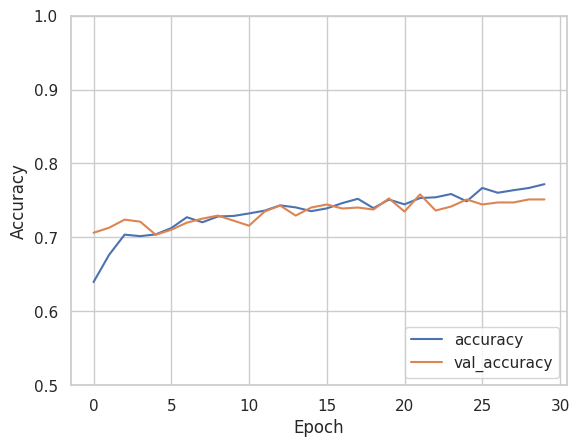

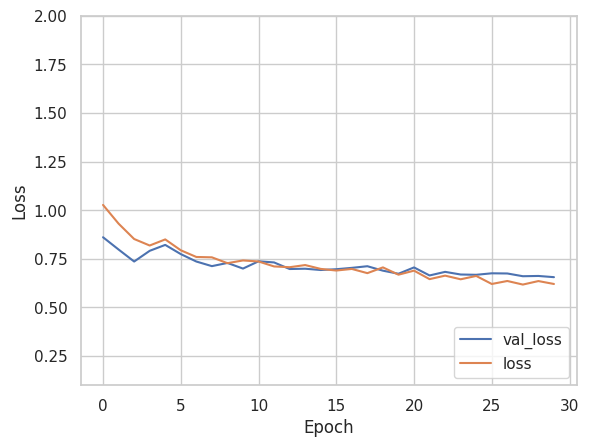

In [70]:
# [개선] 기존: history_1.historyl'accuracy'] 등 → 대괄호·따옴표가 깨진 인쇄 오타 수정, 두 그래프 사이에 plt.show() 추가
plt.plot(history_1.history['accuracy'], label='accuracy')
plt.plot(history_1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history_1.history['val_loss'], label='val_loss')
plt.plot(history_1.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0.1, 2])
plt.legend(loc='lower right')
plt.show()


# → InceptionV3 모델의 학습·검증 정확도를 한 그래프에, 학습·검증 손실을 다른 그래프에 그려 비교하겠다

먼저, 첫 번째 플롯은 학습 정확도(`accuracy`)와 검증 정확도(`val_accuracy`)의 변화를 에포크(epoch)별로 시각화합니다. `plt.plot`을 사용하여 학습과 검증 데이터에서의 정확도를 각각 다른 색상의 선으로 나타냅니다. x축은 에포크를, y축은 정확도를 나타내며, `plt.ylim([0.5, 1])`을 설정하여 y축 범위를 0.5에서 1로 제한합니다. 이를 통해 학습과 검증의 정확도가 얼마나 안정적으로 상승하는지 확인할 수 있습니다. `plt.legend`는 학습 정확도와 검증 정확도를 구분하기 위한 범례를 추가합니다.

두 번째 플롯은 학습 손실(`loss`)과 검증 손실(`val_loss`)의 변화를 시각화합니다. `plt.plot`을 사용하여 학습 및 검증 데이터에서의 손실 값을 에포크별로 나타내며, x축은 에포크를, y축은 손실 값을 나타냅니다. `plt.ylim([0.1, 2])`을 설정하여 y축 범위를 손실 값이 주로 변동하는 범위로 제한합니다. 이 그래프는 모델이 학습 데이터에 얼마나 잘 적합하고 있는지, 그리고 검증 데이터에서도 일반화가 잘 이루어지고 있는지 확인할 수 있도록 도와줍니다.

이 두 그래프를 통해 학습 정확도가 검증 정확도보다 훨씬 높아지고 검증 손실이 증가하는 경향이 보이면 과적합(Overfitting)의 신호일 수 있습니다. 반대로 학습 정확도와 검증 정확도가 모두 낮고 손실이 일정 수준 이상으로 유지된다면 과소적합(Underfitting)일 가능성이 있습니다. 이러한 시각화는 학습 과정에서 모델 성능을 실시간으로 평가하고, 필요 시 학습률 조정, 데이터 증강, 또는 모델 구조 변경 등의 조치를 취하는 데 중요한 정보를 제공합니다.

> **개선 사항 — 그래프 두 개를 나눠 그리기** — 책 코드에는 정확도 그래프와 손실 그래프 사이에 `plt.show()`가 없어서, 노트북에서 실행하면 **두 그래프가 한 그림에 겹쳐서** 그려집니다(정확도 선과 손실 선이 한 축에 함께 나오고, 마지막 `ylim`·`ylabel`만 적용됨). 본문 설명대로 "첫 번째 플롯", "두 번째 플롯"이 따로 보이도록 사이에 `plt.show()`를 넣었습니다. 아래 VGG16과 앙상블 그래프도 같은 방법으로 고쳤습니다.

**결과 해석 — InceptionV3 학습 결과**

| 에포크 | accuracy | val_accuracy | loss | val_loss |
|---|---|---|---|---|
| 1 | 0.64 | 0.7063 | 1.03 | 0.86 |
| 22 | – | **0.7582** (최고) | – | – |
| 30 | 0.7720 | 0.7514 | 0.62 | **0.6556** (최저, 저장) |

- **첫 에포크부터 검증 정확도 0.71**입니다. 처음부터 학습한 CNN이 30에포크 동안 0.46에 머문 것과 대조적입니다. ImageNet 사진 100만 장 이상으로 미리 배운 "선·질감·모양을 알아보는 능력"을 그대로 가져와 쓰는 **전이 학습**의 효과입니다.
- **정확도 그래프**: 학습(파란 선)과 검증(주황 선)이 0.70∼0.77 사이에서 거의 붙어서 함께 올라갑니다. 두 선 사이의 간격이 작으므로 **과적합이 거의 없습니다.** 초반에 검증이 학습보다 높은 것은, 학습 데이터에는 회전·반전 같은 증강이 걸려 문제가 더 어렵기 때문입니다.
- **손실 그래프**: 두 선 모두 꾸준히 내려가고, 검증 손실은 30에포크째에 가장 낮았습니다(0.6556). 끝까지 조금씩 좋아지고 있었으므로 **에포크를 늘리면 조금 더 오를 여지**가 있습니다.
- `inception.h5`에는 검증 손실이 가장 낮았던 30에포크째 모델(검증 정확도 0.7514)이 저장되어 뒤의 앙상블에 쓰입니다.

아래 코드는 학습률을 동적으로 조정하기 위해 `ReduceLROnPlateau` 콜백을 설정하는 과정입니다.

In [71]:
# [개선] 기존: Ird = ReduceLROnPlateau(...) → 소문자 l이 대문자 I로 인쇄된 오타 (이후 코드는 lrd를 사용)
lrd = ReduceLROnPlateau(monitor='val_loss', patience=2, verbose=1, factor=0.8, min_lr=1e-6)


# → VGG16 학습에 쓸 학습률 조정 콜백을 같은 설정으로 한 번 더 만들겠다 (학습이 시작될 때마다 내부 기록이 초기화되므로 앞의 것을 다시 써도 결과는 같음)

이 콜백은 모델 학습 중 검증 손실(`val_loss`)이 일정 기간 동안 개선되지 않을 경우 학습률을 감소시켜, 최적화 과정에서 더 세밀한 조정을 가능하게 합니다. 이를 통해 모델이 더욱 안정적으로 수렴하고, 학습 속도를 조정하며, 최적의 성능에 도달할 가능성을 높입니다.

`monitor='val_loss'`는 검증 손실을 모니터링하도록 설정합니다. 검증 손실은 모델이 새로운 데이터에 대해 얼마나 잘 일반화되는지를 평가하는 지표로, 이 값이 개선되지 않을 경우 학습률 조정이 이루어집니다. `patience=2`는 검증 손실이 개선되지 않는 상태를 허용하는 에포크 수를 나타냅니다. 이 설정에서는 검증 손실이 연속으로 2번의 에포크 동안 개선되지 않으면 학습률이 감소합니다.

`factor=0.8`는 학습률을 기존 값의 80%로 감소시키는 역할을 합니다. 학습률이 감소하면 모델이 더 세밀하게 최적화를 진행할 수 있어, 손실 값이 정체된 구간에서 추가적인 개선이 이루어질 가능성이 커집니다. `min_lr=1e-6`은 학습률의 최소값을 설정하여, 학습률이 지나치게 낮아져 학습 속도가 현저히 느려지는 상황을 방지합니다. `verbose=1`은 학습률 감소가 발생할 때마다 사용자에게 메시지를 출력하여 진행 상황을 확인할 수 있도록 합니다. 이 설정은 초기 학습 단계에서 빠르게 손실 값을 줄이는 동시에, 학습 후반부에서 더 세밀한 최적화를 가능하게 하여 과적합을 방지하고 모델의 성능을 향상시킵니다. 학습률을 자동으로 조정하는 `ReduceLROnPlateau`는 복잡한 학습 문제에서 특히 유용하며, 학습 과정을 효율적으로 관리하는 중요한 도구입니다.

다음 코드는 CNN 모델 학습을 수행하며, 학습 과정에서 가장 성능이 좋은 모델을 저장하기 위한 설정을 포함하고 있습니다.

In [72]:
# [개선] 기존: 'D:/testRun/model2.hdfs', period=10 → .h5 확장자, save_best_only로 바꿈 (위 model_1과 같은 이유)
mcp = f'{SAVE_DIR}/model2.h5'
modelcheckpoint2 = ModelCheckpoint(mcp, verbose=1, monitor='val_loss', save_best_only=True, save_freq='epoch')

# [개선] 기존: model_2.fit_generator(..., callbacks=[Ird, modelcheckpoint2]) → fit으로 바꾸고 Ird 오타를 lrd로 수정
# [개선] 에포크: 기존 epochs=100 → 실행 설정 셀의 EPOCHS 사용 / verbose=2: 에포크당 한 줄만 출력
history_2 = model_2.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN, validation_data=valid_generator, validation_steps=STEP_SIZE_VALID, epochs=EPOCHS, verbose=2, callbacks=[lrd, modelcheckpoint2])


# → VGG16 모델(model_2)을 EPOCHS(책: 100)에포크 동안 학습시키고, 검증 손실이 가장 낮았던 모델을 SAVE_DIR/model2.h5에 저장하겠다

Epoch 1/30

Epoch 1: val_loss improved from None to 0.91751, saving model to /kaggle/working/model2.h5

Epoch 1: finished saving model to /kaggle/working/model2.h5
184/184 - 111s - 605ms/step - accuracy: 0.6724 - auc: 0.8932 - loss: 0.9225 - precision: 0.7932 - recall: 0.5106 - val_accuracy: 0.7063 - val_auc: 0.9208 - val_loss: 0.9175 - val_precision: 0.9077 - val_recall: 0.4167 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 0.91751 to 0.83311, saving model to /kaggle/working/model2.h5

Epoch 2: finished saving model to /kaggle/working/model2.h5
184/184 - 77s - 418ms/step - accuracy: 0.7116 - auc: 0.9221 - loss: 0.8040 - precision: 0.8119 - recall: 0.5863 - val_accuracy: 0.6557 - val_auc: 0.9102 - val_loss: 0.8331 - val_precision: 0.8425 - val_recall: 0.4604 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_loss did not improve from 0.83311
184/184 - 77s - 420ms/step - accuracy: 0.7181 - auc: 0.9285 - loss: 0.7650 - precision: 0.8200 - recall: 0.5860 - val_accuracy:

먼저, `mcp` 변수는 모델이 저장될 파일의 경로를 지정하며, 여기서는 `"D:/testRun/model2.hdf5"`로 설정되어 있습니다. 이 파일은 학습 중 특정 조건에 따라 저장된 최적의 모델 가중치를 포함하게 됩니다.

`ModelCheckpoint`는 모델 학습 중 콜백으로 활용되며, 지정된 경로에 모델의 가중치를 저장합니다. `verbose=1`은 저장 작업이 이루어질 때마다 진행 상태를 출력하여 사용자에게 알립니다. `save_freq='epoch'`은 매 에포크가 종료될 때마다 모델이 저장되도록 설정합니다. `period=10`은 과거 Keras 버전에서 특정 에포크 간격마다 저장을 수행하도록 설정된 매개변수로, 최신 Keras에서는 더 이상 사용되지 않습니다.

`history_2`는 학습 결과를 저장하는 객체로, `fit_generator` 메서드를 통해 학습이 진행됩니다. 이 메서드는 데이터 로더를 사용하여 데이터를 배치 단위로 처리하며, 학습 데이터를 `train_generator`로부터, 검증 데이터를 `valid_generator`로부터 제공합니다. 학습 과정은 `steps_per_epoch=STEP_SIZE_TRAIN`으로 설정된 스텝 수만큼 진행되며, 에포크당 학습 데이터 전체를 한 번 처리하도록 구성됩니다. 검증 데이터는 `validation_steps=STEP_SIZE_VALID`로 설정된 스텝 수만큼 처리되며, 학습 중 모델의 일반화 성능을 평가합니다.

전체 학습은 100번의 에포크 동안 진행되며, `callbacks` 매개변수를 통해 학습률 감소를 제어하는 `ReduceLROnPlateau`와 모델 저장을 담당하는 `ModelCheckpoint`가 적용됩니다. 이 설정은 학습 과정에서 손실이 정체되는 구간에서 학습률을 자동으로 줄이고, 가장 성능이 좋은 모델을 기록하여 이후 작업에서 활용할 수 있도록 합니다. 이러한 설정은 학습의 효율성을 높이고 모델 성능을 극대화하기 위한 중요한 역할을 합니다.

> **참고** — 책 본문도 `period=10`은 "최신 Keras에서는 더 이상 사용되지 않는다"고 직접 밝히고 있습니다. 실제로 Keras 3에서는 이 매개변수를 넣는 순간 `TypeError`로 멈추기 때문에 이 노트북에서는 지웠습니다.

다음 코드는 전체 데이터셋을 처리하고 모델 평가 및 예측 단계에서 사용할 데이터 로더를 생성하는 과정입니다.

In [73]:
# [개선] 기존: rescale=1./255 + flow_from_dataframe(preprocessing_function=...) → 위 complete_generator와 같은 문제로 수정
complete_datagen = ImageDataGenerator(preprocessing_function=preprocessing)
complete_generator = complete_datagen.flow_from_dataframe(
    dataframe=train,
    directory=f"{DATA_DIR}/train_images/",
    x_col="id_code",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    shuffle=False,
    class_mode=None
)


# → 앞의 예측용 로더와 똑같은 로더를 한 번 더 만들겠다 (책 코드의 반복 부분)

Found 3662 validated image filenames.


`ImageDataGenerator`를 사용하여 데이터를 정규화하고 배치 단위로 로드할 수 있도록 설정합니다. 먼저, `complete_datagen`은 `ImageDataGenerator`의 인스턴스로 생성되며, `rescale=1./255`를 통해 모든 픽셀 값을 0과 1 사이로 정규화합니다. 이 과정은 모델 입력 데이터의 범위를 일정하게 유지하여 학습과 예측의 안정성을 높입니다.

`flow_from_dataframe` 메서드를 활용하여 생성된 `complete_generator`는 데이터프레임에 저장된 이미지 파일 정보를 기반으로 데이터를 로드합니다. 여기서 `dataframe=train`은 데이터프레임을 지정하며, 이미지 파일 이름이 포함된 열을 `x_col="id_code"`로 설정합니다. 실제 이미지 파일은 `directory="D:/Dataset/train_images/"`에서 로드되며, 이 디렉터리와 데이터프레임의 파일 이름 정보를 결합하여 이미지를 찾습니다.

`target_size=(IMG_SIZE, IMG_SIZE)`는 이미지를 `(224, 224)` 크기로 리사이즈하여 모델 입력 크기와 일치하도록 합니다. 배치 크기는 `batch_size=1`로 설정되어 한 번에 한 개의 이미지를 처리하며, `shuffle=False`를 통해 데이터 순서를 섞지 않고 로드합니다. `class_mode=None`은 이 데이터 로더가 라벨 없이 이미지 데이터만 반환하도록 설정합니다. 이는 모델 학습 후, 예측이나 평가를 위해 사용됩니다.

또한, `preprocessing_function=preprocessing`을 설정하여 사용자 정의 전처리 함수를 적용합니다. 이 함수는 Ben Graham 기법과 Gaussian Blur를 사용하여 이미지의 품질을 개선하고, 불필요한 배경을 제거하여 모델이 중요한 특징에 집중하도록 돕습니다. 이 데이터 로더는 데이터의 품질을 유지하면서 모델 평가와 예측 단계에서 일관된 데이터를 제공하기 위해 설계되었습니다.

다음 코드는 CNN 모델의 학습 결과를 시각화하여, 학습 및 검증 데이터에서의 정확도와 손실 변화를 에포크(epoch) 단위로 보여줍니다.

> **참고** — 본문은 이미지 크기를 `(227, 227)`이라고 설명하지만 Step 7의 `IMG_SIZE`는 **224**입니다(Step 6 설명을 옮겨 오면서 남은 숫자로 보입니다). 위 본문에서는 실제 코드에 맞게 224로 적었습니다.

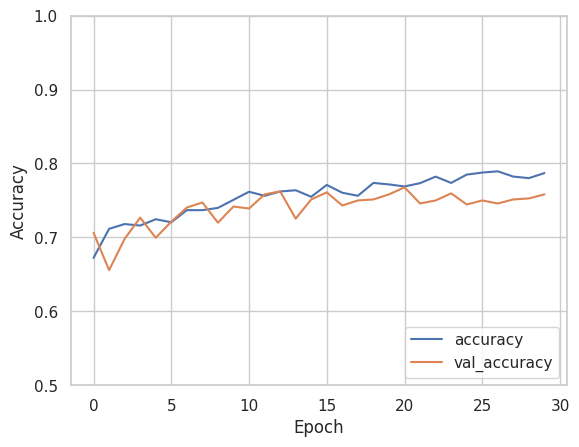

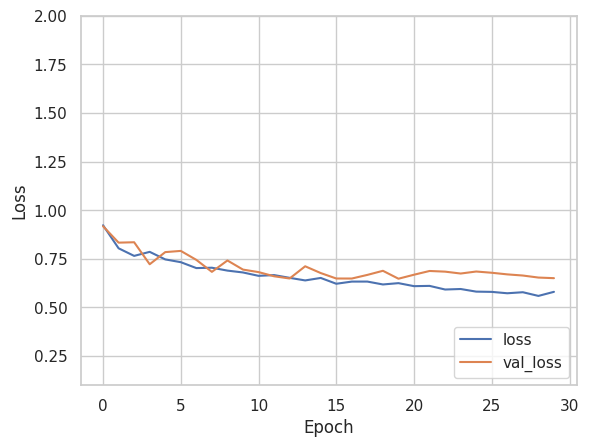

In [74]:
# [개선] 기존: history_2.history[accuracy'] 등 → 따옴표 누락 수정, 두 그래프 사이에 plt.show() 추가
plt.plot(history_2.history['accuracy'], label='accuracy')
plt.plot(history_2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history_2.history['loss'], label='loss')
plt.plot(history_2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0.1, 2])
plt.legend(loc='lower right')
plt.show()


# → VGG16 모델의 학습·검증 정확도와 학습·검증 손실을 각각 다른 그래프로 그리겠다

이를 통해 학습 성능을 분석하고, 모델의 학습이 적절히 이루어지고 있는지 확인할 수 있습니다.

먼저, 첫 번째 그래프는 학습 정확도(`accuracy`)와 검증 정확도(`val_accuracy`)를 시각화합니다. `plt.plot`을 사용하여 학습 및 검증 정확도를 각각 선 그래프로 그립니다. x축은 에포크를, y축은 정확도를 나타내며, `plt.ylim([0.5, 1])`을 설정하여 y축 범위를 0.5에서 1로 제한합니다. 이 설정은 그래프를 더 명확하게 표현하며, 모델의 정확도가 에포크가 진행됨에 따라 어떻게 변화하는지 한눈에 확인할 수 있도록 돕습니다. `plt.legend`를 통해 그래프의 각 선이 학습 정확도와 검증 정확도를 나타냄을 명시합니다.

두 번째 그래프는 학습 손실(`loss`)과 검증 손실(`val_loss`)을 시각화합니다. `plt.plot`을 사용하여 학습 및 검증 손실 값을 에포크별로 표현하며, x축은 에포크를, y축은 손실 값을 나타냅니다. `plt.ylim([0.1, 2])`을 설정하여 손실 값의 변화 범위를 효과적으로 강조합니다. 이 그래프를 통해 모델이 데이터에 과적합되는지 또는 과소적합되는지 확인할 수 있습니다. 손실 값이 안정적으로 감소하고 검증 손실 값이 학습 손실 값과 비슷한 경향을 보인다면, 모델이 안정적으로 학습되고 있음을 나타냅니다.

이 두 그래프는 학습 과정에서 모델의 성능과 일반화 정도를 평가하는 데 유용합니다. 예를 들어, 학습 정확도가 높아지는 반면 검증 정확도가 낮아지거나 손실 값이 증가한다면 이는 과적합의 징후일 수 있습니다. 반대로, 학습 정확도와 검증 정확도가 모두 낮다면 과소적합을 의미할 수 있습니다. 이러한 시각화는 학습 중 발생하는 문제를 식별하고, 모델 구조, 학습률, 데이터 증강 등의 조정을 통해 성능을 개선하는 데 중요한 정보를 제공합니다.

**결과 해석 — VGG16 학습 결과**

| 에포크 | accuracy | val_accuracy | loss | val_loss |
|---|---|---|---|---|
| 1 | 0.67 | 0.7063 | 0.93 | 0.92 |
| 20 | – | 0.7582 | – | **0.6477** (최저, 저장) |
| 21 | – | **0.7678** (최고) | – | – |
| 30 | 0.7870 | 0.7582 | 0.58 | 0.65 |

- VGG16도 전이 학습이라 첫 에포크부터 0.71로 시작했고, 최고 검증 정확도는 **0.768**로 InceptionV3(0.758)보다 조금 높았습니다.
- **20에포크 이후의 변화가 중요합니다.** 학습 손실(파란 선)은 0.58까지 계속 내려가는데 검증 손실(주황 선)은 0.65∼0.69에서 더 내려가지 않습니다. 정확도도 학습은 0.79까지 오르지만 검증은 0.75∼0.76에 머뭅니다. 학습 데이터에만 맞춰지기 시작하는 **과적합의 초기 신호**입니다.
- 그래서 `ModelCheckpoint(save_best_only=True)`가 마지막(30에포크) 모델이 아니라 **검증 손실이 가장 낮았던 20에포크째 모델**을 `model2.h5`로 남겼습니다. "마지막 모델 = 가장 좋은 모델"이 아니라는 것을 보여 주는 예입니다.
- 구조가 전혀 다른 InceptionV3와 에포크당 시간이 거의 같은(약 77초) 것으로 보아, 이 노트북에서는 모델 계산보다 **사진을 읽고 전처리하는 시간**이 학습 시간의 대부분을 차지하는 것으로 보입니다.

### 6. 앙상블 모델

이 코드는 여러 개의 사전 학습된 모델을 결합하여 앙상블 모델을 생성하는 과정입니다. 앙상블 학습은 각각의 모델이 가진 강점을 결합하여 예측 성능을 향상시키는 기법으로, 여기서는 3개의 개별 모델(CNN, Inception, 그리고 또 다른 모델)을 사용하고 있습니다.

In [75]:
from tensorflow.keras.models import Model, load_model
# [개선] Resizing 추가: CNN(227 입력)과 InceptionV3·VGG16(224 입력)의 입력 크기를 맞추기 위함
from tensorflow.keras.layers import Input, Average, Resizing

# [개선] 기존: 'D:/testRun/CNN.hdf5', 'inception.hdf5', 'model2.hdf5' → 5번에서 저장한 .h5 파일 이름으로 통일
model0 = load_model(f'{SAVE_DIR}/CNN.h5')
# [개선] 기존: Model(inputs-model0.inputs, outputs-model0.outputs, ...)
#        → ① = 가 - 로 인쇄된 오타
#        → ② outputs는 출력 "목록"이라, 감싼 모델도 [확률] 형태의 리스트를 돌려줘 아래 Average()에서 AttributeError
#             목록의 첫 번째(=유일한) 출력 outputs[0]을 꺼내 확률 배열 하나를 돌려주게 함
model0 = Model(inputs=model0.inputs, outputs=model0.outputs[0], name='name_of_model')
model1 = load_model(f'{SAVE_DIR}/inception.h5')
model1 = Model(inputs=model1.inputs, outputs=model1.outputs[0], name='name_of_model1')
model2 = load_model(f'{SAVE_DIR}/model2.h5')
model2 = Model(inputs=model2.inputs, outputs=model2.outputs[0], name='name_of_model2')

models = [model0, model1, model2]

model_input = Input(shape=(224, 224, 3))
# [개선] 기존: model_outputs = [model(model_input) for model in models]
#        → CNN(model0)은 227×227 입력으로 만든 모델이라 224×224를 넣으면 ValueError. CNN에만 227로 늘려서 넣음
cnn_input = Resizing(227, 227)(model_input)
model_outputs = [model0(cnn_input), model1(model_input), model2(model_input)]
ensemble_output = Average()(model_outputs)
ensemble_model = Model(inputs=model_input, outputs=ensemble_output, name='ensemble')


# → 저장해 둔 세 모델(CNN·InceptionV3·VGG16)을 불러와 각각 다른 이름을 붙이겠다
# → 224×224 사진 한 장을 세 모델에 동시에 넣고(CNN에는 227로 늘려서), 나온 5단계 확률 세 묶음을 평균 내는 앙상블 모델을 만들겠다

먼저, 각 개별 모델을 파일 경로에서 로드합니다. `load_model` 함수를 사용하여 이전에 저장된 모델(`CNN.hdf5`, `inception.hdf5`, `model2.hdf5`)을 불러옵니다. 불러온 모델은 각각의 입력과 출력을 기반으로 `Model` 객체로 변환되며, 이 객체들은 나중에 앙상블 모델에서 사용됩니다.

그다음, 세 모델을 리스트로 저장하여 `models` 변수에 할당합니다. 이는 앙상블 모델을 생성할 때 반복적으로 사용할 수 있도록 준비된 구조입니다.

`Input` 층을 통해 앙상블 모델의 입력 크기를 정의합니다. 여기서는 `(224, 224, 3)` 크기의 이미지 입력을 사용합니다. 각 모델은 동일한 입력을 공유하며, 이를 통해 개별 모델이 각각의 예측을 수행합니다.

`model_outputs`는 `models` 리스트에 포함된 모든 모델을 반복하여 입력 데이터를 처리한 뒤 출력값을 반환합니다. 이 과정에서 각 모델의 출력은 리스트로 저장됩니다.

앙상블의 최종 출력을 생성하기 위해 `Average` 층을 사용하여 각 모델 출력의 평균을 계산합니다. 평균화는 개별 모델 예측의 가중치 없는 결합을 의미하며, 모델 간의 결과를 종합적으로 반영하여 안정된 예측을 제공합니다.

마지막으로, `ensemble_model`은 정의된 입력과 평균화된 출력을 결합하여 최종 앙상블 모델을 생성합니다. 이 모델은 입력 이미지를 받아 각 모델의 예측 결과를 종합하여 최종 출력값을 반환합니다. 이렇게 구성된 앙상블 모델은 단일 모델보다 더 높은 성능과 안정성을 제공할 가능성이 높습니다. 앙상블 학습은 특히 개별 모델이 서로 다른 약점을 가지는 경우, 예측 정확도를 효과적으로 향상시키는 데 유용한 방법입니다.

**개선 사항 — 입력 크기가 다른 모델 합치기**

Step 6의 CNN은 `Input(shape=(227, 227, 3))`으로 만들었고, InceptionV3·VGG16은 224×224로 만들었습니다. 원래 코드처럼 224×224 입력 하나를 세 모델에 그대로 넣으면 CNN에서 다음 오류가 납니다.

```
ValueError: Input 0 of layer "name_of_model" is incompatible with the layer:
expected shape=(None, 227, 227, 3), found shape=(None, 224, 224, 3)
```

해결 방법은 여러 가지인데(① CNN을 224로 다시 학습, ② 생성기를 두 개 쓰기 등), 이 노트북은 **가장 적게 바꾸는 방법**을 골랐습니다. 앙상블 모델 안에 `Resizing(227, 227)` 층을 넣어 CNN으로 가는 길에서만 사진을 227×227로 살짝 늘립니다. 224와 227은 3픽셀 차이라 CNN이 학습 때 본 사진과 거의 같은 모습이 됩니다.

**`Model(inputs=..., outputs=..., name=...)`으로 다시 감싸는 이유**: 세 모델을 하나의 앙상블 안에 넣으려면 각자 이름이 달라야 합니다. 불러온 모델들은 원래 이름(예: `sequential`, `functional`)이 겹칠 수 있어서, 같은 모델을 새 이름(`name_of_model`, `name_of_model1`, `name_of_model2`)으로 다시 감싼 것입니다.

**`outputs`와 `outputs[0]`의 차이**: `model.outputs`는 "출력들의 목록"(`[출력1]`)입니다. 목록을 출력으로 감싼 모델을 호출하면 결과도 목록(`[확률]`)으로 나오는데, `Average`는 "확률 배열 여러 개"를 기대하므로 "목록의 목록"을 받으면 `AttributeError: 'list' object has no attribute 'shape'`로 멈춥니다(Keras 2는 출력이 하나면 자동으로 풀어 줬지만 Keras 3는 그대로 둡니다). 이 모델들은 출력이 하나뿐이므로 `outputs[0]`으로 꺼내 썼습니다. (단수형 `model.output`도 있지만, 파일에서 불러온 Sequential 모델은 아직 한 번도 호출되지 않아 `output`이 정의되지 않았다는 오류가 날 수 있습니다.)

**`Average`가 하는 일**: 세 모델이 내놓은 5단계 확률을 칸마다 평균 냅니다. 예를 들어 CNN `[0.1, 0.1, 0.6, 0.1, 0.1]`, InceptionV3 `[0.0, 0.1, 0.8, 0.1, 0.0]`, VGG16 `[0.3, 0.1, 0.4, 0.1, 0.1]`이면 앙상블 = `[0.13, 0.10, 0.60, 0.10, 0.07]` → 중등도(2). Step 3의 수식에서 세 가중치가 모두 1/3인 경우입니다.

In [76]:
# [개선] 기존: metrics=METRICS → 앙상블 모델에도 새 지표 객체를 넣음 (5번 개선 사항 참고)
ensemble_model.compile(optimizer='Adam', loss="categorical_crossentropy", metrics=get_metrics())


# → 앙상블 모델도 Adam·categorical_crossentropy·4가지 지표로 학습 준비를 하겠다

이 코드는 앙상블 모델을 컴파일하여 학습과 평가를 수행할 준비를 하는 단계입니다. `compile` 메서드는 모델의 학습 방식을 정의하며, 손실 함수, 옵티마이저, 평가 메트릭을 설정합니다. 여기서 앙상블 모델은 다중 클래스 분류 문제를 해결하기 위해 구성되었습니다.

- **옵티마이저(Optimizer)**: `optimizer='Adam'`은 Adam 옵티마이저를 설정합니다. Adam은 학습률을 동적으로 조정하며, 계산 효율성과 수렴 속도에서 널리 사용되는 옵티마이저입니다. 이를 통해 모델은 빠르고 안정적으로 최적화 과정을 수행할 수 있습니다.
- **손실 함수(Loss Function)**: `loss="categorical_crossentropy"`는 다중 클래스 분류 문제에서 일반적으로 사용되는 손실 함수입니다. 각 클래스에 대한 예측 확률과 실제 라벨 간의 차이를 계산하여 모델이 예측을 개선하도록 학습합니다. 이 손실 함수는 라벨이 원-핫 인코딩(One-Hot Encoding)된 형태일 때 사용됩니다.
- **평가 메트릭(Metrics)**: `metrics=METRICS`는 모델의 학습과 평가 중 성능을 측정하는 지표를 정의합니다. 일반적으로 포함되는 메트릭은 정확도(accuracy), 정밀도(precision), 재현율(recall), 그리고 ROC-AUC 점수(auc)로, 각각 모델의 분류 성능을 다각도로 평가합니다. 이를 통해 모델이 데이터에 대해 얼마나 효과적으로 학습했는지 확인할 수 있습니다.

이 컴파일 단계는 앙상블 모델이 데이터를 처리하고 예측 성능을 평가할 준비를 마쳤음을 의미합니다. 이 설정은 이후 모델 학습(fit)과 평가(evaluate)에 사용되며, 설정된 손실 함수와 옵티마이저를 기반으로 최적화를 수행합니다. 앙상블 모델의 컴파일은 개별 모델의 강점을 결합하여 더욱 강력하고 안정적인 예측 성능을 목표로 합니다.

아래 코드는 앙상블 모델의 학습 과정을 실행하고, 모델의 구조를 요약하여 출력합니다. 학습은 데이터 로더를 통해 배치 단위로 진행되며, 검증 데이터를 사용해 학습 중 모델의 일반화 성능을 평가합니다.

In [77]:
# [개선] 기존: ensemble_model.fit_generator generator=train_generator, ... → 여는 괄호 누락 + Keras 3에서 삭제된 함수. fit으로 바꿈
# [개선] 에포크: 기존 epochs=100 → 실행 설정 셀의 EPOCHS 사용 / verbose=2: 에포크당 한 줄만 출력
history_ensemble = ensemble_model.fit(train_generator, steps_per_epoch=STEP_SIZE_TRAIN, validation_data=valid_generator, validation_steps=STEP_SIZE_VALID, epochs=EPOCHS, verbose=2, callbacks=[lrd])
ensemble_model.summary()


# → 앙상블 모델 전체를 EPOCHS(책: 100)에포크 동안 다시 학습시키고, 세 모델이 어떻게 연결되어 있는지 구조를 출력하겠다

Epoch 1/30
184/184 - 135s - 732ms/step - accuracy: 0.7621 - auc: 0.9343 - loss: 0.7421 - precision: 0.8575 - recall: 0.6447 - val_accuracy: 0.7404 - val_auc: 0.9221 - val_loss: 0.8040 - val_precision: 0.8802 - val_recall: 0.5820 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.000800000037997961.
184/184 - 79s - 432ms/step - accuracy: 0.7587 - auc: 0.9316 - loss: 0.7562 - precision: 0.8676 - recall: 0.6331 - val_accuracy: 0.6995 - val_auc: 0.9181 - val_loss: 0.8289 - val_precision: 0.8879 - val_recall: 0.5519 - learning_rate: 0.0010
Epoch 3/30
184/184 - 79s - 430ms/step - accuracy: 0.7512 - auc: 0.9303 - loss: 0.7516 - precision: 0.8665 - recall: 0.6379 - val_accuracy: 0.7514 - val_auc: 0.9225 - val_loss: 0.7782 - val_precision: 0.8697 - val_recall: 0.6202 - learning_rate: 8.0000e-04
Epoch 4/30

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0006400000303983689.
184/184 - 79s - 428ms/step - accuracy: 0.7546 - auc: 0.9257 - loss: 0.7707 

Model: "ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 227, 227,  │          0 │ input_layer_4[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ name_of_model       │ (None, 5)         │  6,811,621 │ resizing[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ name_of_model1      │ (None, 5)         │ 24,874,807 │ input_layer_4[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ name_of_model2      │ (None, 5)         │ 16,207,703 │ input_layer_4[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average (Average)   │ (None, 5)         │          0 │ name_of_model[0]… │
│                     │                   │            │ name_of_model1[0… │
│                     │                   │            │ name_of_model2[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,637,211 (269.46 MB)

 Trainable params: 11,371,539 (43.38 MB)

 Non-trainable params: 36,522,592 (139.32 MB)

 Optimizer params: 22,743,080 (86.76 MB)

먼저, `fit_generator` 메서드를 사용해 모델 학습을 수행합니다. 학습 데이터는 `train_generator`에서 배치 단위로 제공되며, 데이터 증강과 전처리가 적용된 상태로 모델에 전달됩니다. 에포크당 학습 데이터를 처리하기 위한 스텝 수는 `STEP_SIZE_TRAIN`으로 설정됩니다. 이는 학습 데이터 전체 샘플 수를 배치 크기로 나눈 값으로, 한 에포크 내에서 학습 데이터 전체를 처리할 수 있도록 정의됩니다. 검증 데이터는 `valid_generator`를 통해 제공되며, 에포크당 검증 데이터를 처리하기 위한 스텝 수는 `STEP_SIZE_VALID`로 설정됩니다. 이를 통해 학습 중 모델의 성능을 독립적으로 평가할 수 있습니다.

학습은 100번의 에포크 동안 진행되며, 검증 데이터에 대한 성능을 모니터링하여 학습률을 조정하는 `ReduceLROnPlateau` 콜백이 적용됩니다. 이 콜백은 검증 손실이 일정 기간 동안 개선되지 않을 경우 학습률을 감소시켜 모델이 더 세밀하게 학습할 수 있도록 돕습니다.

마지막으로, `ensemble_model.summary()`를 사용해 앙상블 모델의 구조를 출력합니다. 출력 결과에는 각 계층의 이름과 유형, 출력 형태, 그리고 학습 가능한 매개변수의 수가 포함됩니다. 이를 통해 모델의 전체 구조와 복잡도를 한눈에 파악할 수 있으며, 학습 중 설정된 계층이 예상대로 작동하는지 확인할 수 있습니다.

이 과정은 앙상블 모델의 성능을 최적화하고, 모델 구조를 검토하여 학습과 평가의 효율성을 높이는 데 중요한 역할을 합니다.

> **참고 — 앙상블을 "다시 학습"한다는 것의 의미**
>
> 원래 앙상블은 각자 학습을 마친 모델의 예측을 **그냥 합치기만** 하는 경우가 많습니다. 책 코드는 합친 뒤 한 번 더 100에포크(이 노트북은 `EPOCHS`)를 학습시키는데, 이때 일어나는 일은 다음과 같습니다.
>
> - 세 모델의 가중치 중 **얼려 두지 않은 부분**(CNN 전체, InceptionV3·VGG16 위에 붙인 Dense 층들)이 "평균 예측이 정답에 가까워지는 방향"으로 함께 조정됩니다. InceptionV3·VGG16 본체는 5번에서 얼린 상태(`trainable=False`)가 파일에 저장되어 있어 그대로 얼려 있습니다.
> - `Average` 층 자체에는 학습할 가중치가 없으므로, 세 모델의 **발언권(가중치)은 계속 1/3씩 같습니다.** 즉 이 학습으로 Step 3에서 말한 "성능에 따른 가중치"가 정해지지는 않습니다.
> - `model0`, `model1`, `model2` 변수는 앙상블 안의 모델과 **같은 객체**라서, 이 셀이 끝나면 세 변수 모두 앙상블 학습으로 바뀐 가중치를 갖게 됩니다. 원래 저장한 상태로 돌아가려면 위의 `load_model` 셀을 다시 실행하면 됩니다(파일은 바뀌지 않았습니다).
>
> 논문의 가중치 앙상블을 직접 확인해 보고 싶다면, 이 Step 맨 끝에 추가한 **가중치 앙상블 셀**을 실행해 보세요.

아래 코드는 앙상블 모델의 학습 결과를 시각화하여 학습 및 검증 데이터에서의 정확도와 손실 변화를 에포크 단위로 분석합니다. 그래프를 통해 모델 학습 성능의 경향을 확인하고, 과적합 또는 과소적합 여부를 판단할 수 있습니다.

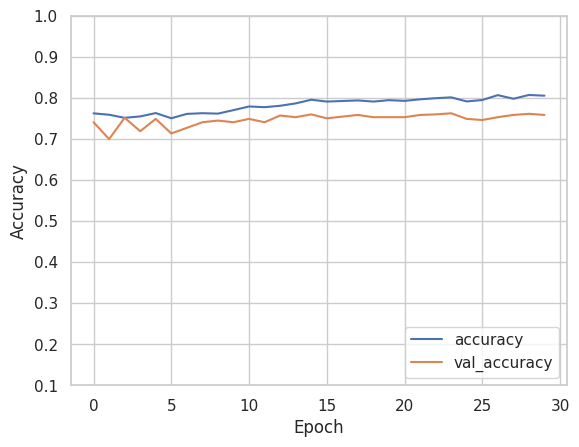

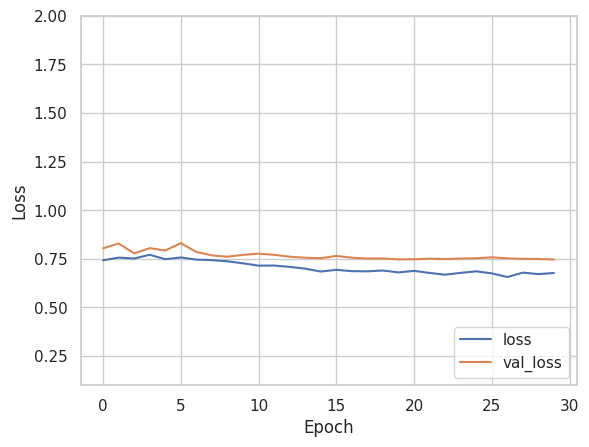

In [78]:
# [개선] 기존: history_ensemble.historyl'accuracy'] 등 → 인쇄 오타 수정, 두 그래프 사이에 plt.show() 추가
plt.plot(history_ensemble.history['accuracy'], label='accuracy')
plt.plot(history_ensemble.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.1, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history_ensemble.history['loss'], label='loss')
plt.plot(history_ensemble.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0.1, 2])
plt.legend(loc='lower right')
plt.show()


# → 앙상블 모델의 학습·검증 정확도(y축 0.1~1)와 학습·검증 손실(y축 0.1~2)을 각각 그래프로 그리겠다

첫 번째 그래프는 학습 정확도(`accuracy`)와 검증 정확도(`val_accuracy`)를 나타냅니다. `plt.plot` 함수를 사용하여 에포크별 정확도를 선 그래프로 시각화하며, x축은 에포크 수를, y축은 정확도를 나타냅니다. `plt.ylim([0.1, 1])`로 y축의 범위를 설정하여 정확도의 변화 범위를 강조합니다. 학습 정확도와 검증 정확도의 경향이 서로 유사하게 상승한다면 모델이 데이터에 잘 적합되고 있음을 나타냅니다. 반면, 학습 정확도가 높지만 검증 정확도가 낮다면 이는 과적합의 신호일 수 있습니다.

두 번째 그래프는 학습 손실(`loss`)과 검증 손실(`val_loss`)을 시각화합니다. `plt.plot` 함수를 사용하여 학습 및 검증 손실 값을 에포크별로 나타냅니다. x축은 에포크 수를, y축은 손실 값을 표시하며, `plt.ylim([0.1, 2])`로 y축 범위를 설정하여 손실 값의 변화를 강조합니다. 학습 손실이 에포크가 진행됨에 따라 점차 감소하고, 검증 손실도 유사한 경향을 보인다면 모델이 안정적으로 학습되고 있음을 의미합니다. 그러나 학습 손실은 감소하지만 검증 손실이 증가한다면 과적합 가능성을 시사합니다.

이 두 그래프는 모델 학습의 효과를 실시간으로 분석할 수 있도록 하며, 학습률, 데이터 증강, 또는 모델 구조 조정과 같은 개선 작업의 필요성을 판단하는 데 유용한 정보를 제공합니다. 학습 정확도와 손실 값의 균형을 이루는 것이 모델의 최적 성능을 달성하는 데 중요합니다.

**결과 해석 — 앙상블 모델 재학습**

| 에포크 | accuracy | val_accuracy | loss | val_loss |
|---|---|---|---|---|
| 1 | 0.76 | 0.7404 | 0.74 | 0.80 |
| 24 | – | **0.7623** (최고) | – | – |
| 30 | 0.8051 | 0.7582 | 0.68 | 0.7464 |

- 이미 학습된 세 모델을 묶었기 때문에 **첫 에포크부터 학습 정확도 0.76**으로 시작합니다.
- 30에포크 동안 학습 정확도는 0.76 → 0.81로 올랐지만 검증 정확도는 0.74 → 0.76으로 거의 그대로입니다. 그래프에서 두 선의 간격이 점점 벌어지는 것이 보입니다. **세 모델을 합친 뒤 다시 학습시키는 것은 검증 성능을 거의 올리지 못하고 과적합만 키웠습니다.**
- **검증 손실(0.75)이 InceptionV3·VGG16 단독(0.65)보다 높은 이유**: `Average()`는 세 모델의 확률을 똑같이 1/3씩 섞는데, 그중 CNN은 사진과 상관없이 "정상 50%, 중등도 27% …" 같은 비율만 내놓습니다. 이 확률이 섞이면 정답 단계에 준 확신이 옅어져 손실이 커집니다. 정확도(가장 큰 확률의 단계)는 크게 변하지 않아도 손실은 나빠질 수 있다는 예입니다.
- 앙상블의 원래 목적은 이미 학습된 모델의 의견을 **합치기만** 하는 것입니다. 바로 아래의 가중치 앙상블 셀이 재학습 없이 저장된 세 모델로 이 방식을 계산합니다.

#### [추가] 가중치 앙상블 — 논문 수식 직접 구현하기

책 코드의 앙상블은 세 모델을 **똑같이 1/3씩** 평균 내지만, Step 3에서 설명한 논문의 방법은 성능이 좋은 모델에 더 큰 가중치를 주는 **가중치 평균 앙상블**(W2 > W1 > W3)입니다. 아래 셀은 그 수식

$$y_{\text{ensemble}} = \sum_{i=1}^{3} w_i \cdot \hat{y}_i$$

을 그대로 구현합니다. 가중치 $w_i$는 각 모델의 **검증 정확도에 비례**하도록 정하고(합이 1이 되게 나눔), 단순 평균 앙상블과 결과를 비교합니다.

- 앙상블 학습(위 셀)으로 바뀌기 전의 원래 모델을 쓰기 위해 저장된 파일(`.h5`)을 새로 불러옵니다.
- 평가에는 증강 없이 순서를 섞지 않는(`shuffle=False`) 검증용 로더를 써서, 예측과 정답의 순서를 맞춥니다.

In [79]:
# [추가] 가중치 앙상블: 각 모델의 검증 정확도에 비례하는 가중치로 예측을 합침 (Step 3의 수식 구현)


from sklearn.metrics import accuracy_score

# ===== Load base models =====
# 앙상블 학습 전의 원래 모델을 쓰기 위해 저장된 파일을 새로 불러옴
cnn_model = load_model(f'{SAVE_DIR}/CNN.h5')
inception_model = load_model(f'{SAVE_DIR}/inception.h5')
vgg_model = load_model(f'{SAVE_DIR}/model2.h5')

# CNN은 227 입력이므로, 224 사진을 227로 늘려서 넣는 작은 모델로 감쌈
inp = Input(shape=(224, 224, 3))
cnn_224 = Model(inputs=inp, outputs=cnn_model(Resizing(227, 227)(inp)))

# ===== Predict on validation set =====
# 증강 없이, 순서를 섞지 않는 검증용 로더 → 예측 결과와 정답(labels)의 순서가 같음
valid_eval_generator = valid_datagen.flow_from_dataframe(
    dataframe=train, directory=f"{DATA_DIR}/train_images/",
    x_col="id_code", y_col="diagnosis", batch_size=16, class_mode="categorical",
    target_size=(IMG_SIZE, IMG_SIZE), subset='validation', shuffle=False
)
y_true = np.array(valid_eval_generator.labels)

# predict(): 사진마다 5단계 확률을 담은 (사진 수, 5) 배열을 돌려줌
p_cnn = cnn_224.predict(valid_eval_generator)
p_inc = inception_model.predict(valid_eval_generator)
p_vgg = vgg_model.predict(valid_eval_generator)
preds = {'CNN': p_cnn, 'InceptionV3': p_inc, 'VGG16': p_vgg}

# ===== Weights =====
# argmax(axis=1): 5개 확률 중 가장 큰 칸의 번호(=예측 단계)를 사진마다 고름
accs = {name: accuracy_score(y_true, p.argmax(axis=1)) for name, p in preds.items()}
# 정확도를 합이 1이 되도록 나눠 가중치로 사용 (정확도가 높을수록 가중치가 큼)
total = sum(accs.values())
weights = {name: acc / total for name, acc in accs.items()}

# ===== Ensemble =====
# 단순 평균: 세 확률을 1/3씩 / 가중치 평균: Σ wi · ŷi
p_mean = (p_cnn + p_inc + p_vgg) / 3
p_weighted = sum(weights[name] * p for name, p in preds.items())

for name in preds:
    print(f'{name:<12} 정확도 {accs[name]:.4f}   가중치 {weights[name]:.3f}')
print(f'단순 평균 앙상블   정확도 {accuracy_score(y_true, p_mean.argmax(axis=1)):.4f}')
print(f'가중치 앙상블      정확도 {accuracy_score(y_true, p_weighted.argmax(axis=1)):.4f}')


# → 저장된 세 모델로 검증 사진의 5단계 확률을 각각 구하고, 모델별 정확도를 계산하겠다
# → 정확도를 합이 1이 되게 나눈 값을 가중치로 삼아 가중치 평균 앙상블을 만들고, 단순 평균 앙상블과 정확도를 비교하겠다

Found 732 validated image filenames belonging to 5 classes.
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step
CNN          정확도 0.4604   가중치 0.234
InceptionV3  정확도 0.7514   가중치 0.381
VGG16        정확도 0.7582   가중치 0.385
단순 평균 앙상블   정확도 0.7650
가중치 앙상블      정확도 0.7732


**코드 설명과 결과 읽는 법**

| 출력 줄 | 뜻 |
|---|---|
| `CNN 정확도 … 가중치 …` | 모델 하나만 썼을 때의 검증 정확도와, 그로부터 계산된 발언권 |
| `단순 평균 앙상블` | 책 코드의 `Average()`와 같은 방식(앙상블 재학습 전) |
| `가중치 앙상블` | 논문의 방식 |

- 세 모델의 정확도가 비슷하면 가중치도 모두 1/3(0.333) 근처가 되어 두 앙상블의 결과가 거의 같습니다. 정확도 차이를 더 크게 반영하고 싶다면 정확도를 제곱하거나, 검증 손실이 작은 순서로 가중치를 주는 등 다른 규칙을 쓸 수 있습니다. 논문도 "W2 > W1 > W3"라는 순서만 밝혔을 뿐 정확한 값은 적지 않았습니다.
- **주의할 점**: 여기서는 가중치를 정할 때와 성능을 잴 때 **같은 검증 데이터**를 썼습니다. 그래서 가중치 앙상블의 정확도가 실제보다 조금 좋게 나올 수 있습니다. 엄밀하게 하려면 가중치를 정하는 데이터와 최종 평가에 쓰는 데이터(테스트 데이터)를 따로 나눠야 합니다.
- 정확도 외에 앙상블의 정밀도·재현율·F1도 보고 싶다면, 1장에서 썼던 `classification_report(y_true, p_weighted.argmax(axis=1))`를 실행하면 단계별 성적표가 나옵니다.

**결과 해석 — 단순 평균 vs 가중치 앙상블**

| 모델 | 검증 정확도 | 가중치(발언권) |
|---|---|---|
| CNN | 0.4604 | 0.234 |
| InceptionV3 | 0.7514 | 0.381 |
| VGG16 | 0.7582 | 0.385 |
| 단순 평균 앙상블 | **0.7650** | 1/3씩 |
| 가중치 앙상블 | **0.7732** | 위 가중치 |

- **가중치 계산**: 각 모델의 정확도를 세 정확도의 합(1.970)으로 나눈 값입니다. 예를 들어 VGG16은 0.7582 ÷ 1.970 = 0.385입니다. 세 가중치를 더하면 1이 됩니다.
- **두 앙상블 모두 가장 좋은 단독 모델(VGG16 0.7582)보다 높습니다.** 서로 다른 구조의 모델이 서로 다른 사진에서 틀리기 때문에, 의견을 합치면 한쪽의 실수를 다른 쪽이 메워 줍니다. 논문의 핵심 주장이 이 실행에서도 확인되었습니다.
- **가중치 앙상블이 단순 평균보다 0.8%p 높은 이유**: 아무것도 배우지 못한 CNN의 발언권이 1/3(0.333)에서 0.234로 줄었기 때문입니다. 다만 CNN의 정확도도 0.46이라 가중치가 0까지 내려가지는 않습니다. 정확도를 그대로 비율로 쓰는 방식은 "쓸모없는 모델"을 충분히 걸러 내지 못한다는 한계도 보여 줍니다.
- 위 **코드 설명과 결과 읽는 법**의 **주의할 점**처럼, 가중치를 정한 데이터와 평가한 데이터가 같은 732장이라 이 0.7732는 조금 낙관적인 값입니다.

#### [추가] 최종 비교 — 모델 5개 성능표와 가중치 앙상블 혼동행렬

위 셀에서 구한 예측(`p_cnn`, `p_inc`, `p_vgg`, `p_mean`, `p_weighted`)으로 Step 4의 표와 같은 형태의 성능 비교표를 만듭니다. 책의 지표(정확도·정밀도·재현율·F1·AUC)에 더해, APTOS 2019 대회의 공식 채점 기준이었던 <strong>QWK(이차 가중 카파)</strong>도 함께 계산합니다.

> **용어 풀이 — QWK(Quadratic Weighted Kappa, 이차 가중 카파)**: 단계를 **얼마나 크게** 틀렸는지까지 반영하는 점수입니다. 정확도는 "정상 → 경증"으로 틀리든 "정상 → 증식성"으로 틀리든 똑같이 한 개 틀린 것으로 세지만, QWK는 단계 차이의 제곱만큼 더 크게 감점합니다. 1이면 완벽, 0이면 우연히 맞힌 수준입니다. 단계가 순서대로 이어진 DR 같은 문제에 잘 맞는 지표라 대회 채점에 쓰였습니다.

,Accuracy,Precision,Recall,F1 Score,AUC,QWK
Model,,,,,,
CNN,0.4604,0.0921,0.2000,0.1261,0.5000,0.0000
InceptionV3,0.7514,0.6144,0.4943,0.5098,0.9051,0.8099
VGG16,0.7582,0.5813,0.5172,0.5300,0.9017,0.7871
Average Ensemble,0.7650,0.6891,0.4850,0.5009,0.9167,0.7865
Weighted Ensemble,0.7732,0.6355,0.5030,0.5205,0.9166,0.8113


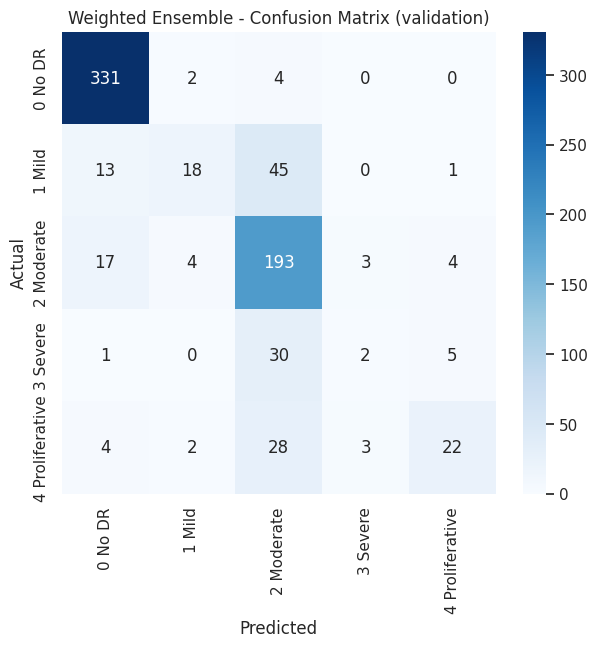

In [80]:
# [추가] 모델 5개(단독 3개 + 앙상블 2개)의 성능을 Step 4와 같은 지표로 비교하고, 가중치 앙상블의 혼동행렬을 그림


from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix

# 단계 이름 (Step 6에서 정의했지만, Step 7만 따로 실행할 때를 대비해 다시 정의)
GRADE_NAMES = ['0 No DR', '1 Mild', '2 Moderate', '3 Severe', '4 Proliferative']

# ===== Metrics table =====
all_probs = {'CNN': p_cnn, 'InceptionV3': p_inc, 'VGG16': p_vgg,
             'Average Ensemble': p_mean, 'Weighted Ensemble': p_weighted}
rows = []
for name, p in all_probs.items():
    pred = p.argmax(axis=1)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, pred),
        # average='macro': 다섯 단계를 똑같은 비중으로 평균 (불균형 데이터에서 공정한 비교)
        'Precision': precision_score(y_true, pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, pred, average='macro', zero_division=0),
        'F1 Score': f1_score(y_true, pred, average='macro', zero_division=0),
        # multi_class='ovr': 단계마다 "이 단계 vs 나머지"로 AUC를 구해 평균
        'AUC': roc_auc_score(y_true, p, multi_class='ovr', labels=list(range(5))),
        # weights='quadratic': 단계 차이의 제곱만큼 감점하는 QWK
        'QWK': cohen_kappa_score(y_true, pred, weights='quadratic'),
    })
result_df = pd.DataFrame(rows).set_index('Model')
display(result_df.style.format('{:.4f}').background_gradient(cmap='Blues'))

# ===== Confusion matrix (weighted ensemble) =====
cm = confusion_matrix(y_true, p_weighted.argmax(axis=1), labels=range(5))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GRADE_NAMES, yticklabels=GRADE_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Weighted Ensemble - Confusion Matrix (validation)')
plt.show()


# → 다섯 모델의 정확도·정밀도·재현율·F1·AUC·QWK를 한 표로 모아, 값이 클수록 진하게 칠해 비교하겠다
# → 가중치 앙상블이 어떤 단계를 헷갈리는지 혼동행렬로 그리겠다

> **표 읽는 법 — Step 4의 책 표와 비교하기**
>
> - 이 표의 정밀도·재현율·F1은 다섯 단계의 **macro 평균**입니다. 책의 표도 같은 방식으로 계산한 것으로 보이지만 논문에 계산 방법이 적혀 있지 않아, 숫자를 1:1로 비교하기보다는 **모델끼리의 순서**(어느 모델이 더 나은가)를 비교하는 데 쓰는 것이 좋습니다.
> - 책 값보다 낮게 나오는 것이 정상입니다. 이 노트북은 에포크를 줄였고(책 100 → 30), 검증 데이터 분할과 무작위 초기값도 논문과 다릅니다.
> - 앙상블 두 줄이 단독 모델 세 줄보다 진하면 "합치는 것이 도움이 된다"는 논문의 주장이 이 실행에서도 확인된 것입니다. 단독 모델 중 하나가 앙상블보다 좋다면, 나머지 두 모델이 오히려 발목을 잡은 경우입니다.
> - 정확도는 높은데 Recall·F1이 낮다면 사진이 많은 정상(0)·중등도(2)만 잘 맞히고 적은 단계(1·3·4)를 놓치고 있다는 뜻입니다. 혼동행렬의 아래쪽 행을 함께 확인하세요.

**결과 해석 — 모델 5개 비교표**

| 모델 | Accuracy | Precision | Recall | F1 | AUC | QWK |
|---|---|---|---|---|---|---|
| CNN | 0.4604 | 0.0921 | 0.2000 | 0.1261 | 0.5000 | 0.0000 |
| InceptionV3 | 0.7514 | 0.6144 | 0.4943 | 0.5098 | 0.9051 | 0.8099 |
| VGG16 | 0.7582 | 0.5813 | 0.5172 | **0.5300** | 0.9017 | 0.7871 |
| 단순 평균 앙상블 | 0.7650 | **0.6891** | 0.4850 | 0.5009 | **0.9167** | 0.7865 |
| 가중치 앙상블 | **0.7732** | 0.6355 | 0.5030 | 0.5205 | 0.9166 | **0.8113** |

- **CNN 줄**: 재현율 0.2000은 다섯 단계 중 정상 하나만 100% 맞히고 나머지는 0%라서 (1 + 0 + 0 + 0 + 0) ÷ 5 = 0.2가 된 것입니다. AUC 0.5000과 QWK 0.0000은 "동전 던지기와 같은 수준"이라는 뜻입니다.
- **정확도·AUC·QWK는 앙상블이 가장 좋습니다.** 특히 가중치 앙상블은 정확도(0.7732)와 QWK(0.8113)에서 1등입니다. QWK(이차 가중 카파)는 보통 0.6∼0.8을 '상당한 일치', 0.8 이상을 '매우 높은 일치'로 해석하므로, 0.81은 정답(의사의 판정)과 **단계의 순서를 꽤 잘 맞춘다**는 뜻입니다.
- **F1은 VGG16 단독(0.5300)이 가장 높습니다.** 앙상블은 다수 단계(0·2)를 더 잘 맞혀 정확도를 올렸지만, 적은 단계(1·3)를 찾는 능력까지 좋아지지는 않았습니다. 어떤 지표로 보느냐에 따라 "가장 좋은 모델"이 달라질 수 있다는 점을 기억해 두세요.
- **AUC 0.90∼0.92 vs F1 0.50∼0.53**: AUC는 "병이 있는 사진에 더 높은 확률을 주는가"(순서)를 보고, F1은 "실제로 맞는 단계를 골랐는가"(결정)를 봅니다. 모델이 대략적인 심각도 순서는 잘 알지만, 바로 옆 단계끼리는 자주 헷갈린다는 뜻입니다. 혼동행렬에서 확인할 수 있습니다.

---

**결과 해석 — 가중치 앙상블의 혼동행렬**

| 실제 단계 | 사진 수 | 맞힌 수 | 단계별 재현율 | 가장 많이 헷갈린 단계 |
|---|---|---|---|---|
| 0 정상 | 337 | 331 | **98.2%** | 2 중등도 (4장) |
| 1 경증 | 77 | 18 | 23.4% | **2 중등도 (45장)** |
| 2 중등도 | 221 | 193 | **87.3%** | 0 정상 (17장) |
| 3 중증 | 38 | 2 | 5.3% | **2 중등도 (30장)** |
| 4 증식성 | 59 | 22 | 37.3% | **2 중등도 (28장)** |

① **틀린 사진의 대부분이 "2 중등도" 열로 몰립니다.** 경증·중증·증식성 사진이 각각 45·30·28장씩 중등도로 예측되었습니다. 중등도는 두 번째로 많은 단계(27%)라서, 확신이 없을 때 모델이 "가운데 단계"를 고르는 경향이 생겼습니다.

② **중증(3단계)은 38장 중 2장만 맞혔습니다.** 가장 적은 단계(5%)이고, 중등도와 증식성 사이에 있어 경계가 애매합니다. 단계별 데이터 수를 맞추는 <strong>클래스 가중치(class_weight)</strong>나 증강을 적은 단계에 더 주는 방법이 필요한 부분입니다.

③ **임상적으로 보면 결과가 생각보다 쓸 만합니다.** 실제 진료에서는 다섯 단계를 정확히 맞히는 것보다 "**안과 전문의에게 보내야 하는 환자**(보통 2단계 이상, referable DR)를 놓치지 않는 것"이 더 중요합니다. 이 기준으로 혼동행렬을 다시 묶어 계산하면 다음과 같습니다.

| 질문 | 계산 | 결과 |
|---|---|---|
| 2단계 이상 환자를 2단계 이상으로 찾아냈나? (민감도) | (200 + 37 + 53) ÷ 318 | **91.2%** |
| 0·1단계 사람을 0·1단계로 맞혔나? (특이도) | (333 + 31) ÷ 414 | **87.9%** |
| 병이 조금이라도 있는 사람(1∼4단계)을 찾아냈나? | 360 ÷ 395 | **91.1%** |
| 정상인을 정상으로 맞혔나? | 331 ÷ 337 | **98.2%** |

<strong>민감도(sensitivity)</strong>는 "환자를 환자라고 찾아내는 비율", <strong>특이도(specificity)</strong>는 "건강한 사람을 건강하다고 맞히는 비율"입니다. 다섯 단계 정확도는 77%지만 "의뢰가 필요한가"라는 두 갈래 질문으로 바꾸면 민감도 91%, 특이도 88%가 됩니다. 다만 위험한 쪽의 실수, 즉 **증식성 59장 중 4장을 "정상"으로 예측**한 경우는 실제 환자에게 치명적일 수 있어 따로 줄여야 할 오류입니다.

**결과 해석 — 책(논문) vs 이 노트북 vs 공개 코드**

| 모델 | 책 정확도 / AUC | 이 노트북 정확도 / AUC | 차이 |
|---|---|---|---|
| 커스텀 CNN | 90.56% / 93.82% | 46.04% / 0.500 | −44.5%p |
| InceptionV3 | 93.08% / 97.20% | 75.14% / 0.905 | −17.9%p |
| VGG16 | 91.29% / 96.72% | 75.82% / 0.902 | −15.5%p |
| 가중치 앙상블 | **95.06% / 98.10%** | **77.32% / 0.917** | −17.7%p |
| (참고) 공개 Kaggle 노트북, EfficientNetB0 + 클래스 가중치 | – | 정확도 73%, macro F1 0.59 | – |

**같은 경향은 재현되었습니다.** "전이 학습 모델이 처음부터 학습한 모델보다 낫다", "여러 모델을 합친 앙상블이 단독 모델보다 낫다", "가중치 앙상블이 단순 평균보다 낫다"는 세 가지 결론은 이 실행에서도 그대로 나타났습니다.

**숫자는 크게 차이 납니다.** 이 노트북의 앙상블(77%)은 같은 대회 데이터를 다른 방법으로 학습한 공개 노트북(73%)보다는 조금 높지만, 책의 95%와는 거리가 멉니다. 가능한 이유는 다음과 같습니다.

| 이유 | 설명 |
|---|---|
| 에포크 | 책은 100에포크, 이 노트북은 30에포크입니다. 다만 InceptionV3·VGG16은 20에포크 이후 검증 성능이 거의 멈췄으므로 이것만으로 18%p 차이를 설명하기는 어렵습니다. |
| 커스텀 CNN | 같은 구조로는 학습 자체가 되지 않았습니다. 논문에서는 다른 구조(Step 3의 파라미터 표는 합성곱 6층, 코드는 12층)나 다른 설정을 썼을 가능성이 있습니다. |
| 평가 방법 | 논문에 검증 데이터를 어떻게 나눴는지, 지표를 어떻게 평균 냈는지 적혀 있지 않습니다. 같은 환자의 비슷한 사진이 학습·검증에 함께 들어가면 점수가 높게 나올 수 있습니다. |
| 책 안의 불일치 | Step 4에서 정리한 것처럼 책 안에서도 표마다 수치가 다르고, 정확도 90% 이상인데 재현율은 68∼80%로 낮게 보고되어 있습니다. |

결론적으로, **책의 수치를 목표로 삼기보다는 "이 코드로 직접 돌려 보면 이 정도가 나온다"는 기준값**으로 이 결과를 쓰는 것이 좋습니다. 이 기준에서 출발해 클래스 가중치, 더 나은 사전 학습 모델(EfficientNet 등), 높은 입력 해상도, QWK에 맞춘 학습 방법 등을 하나씩 바꿔 가며 효과를 비교해 볼 수 있습니다.

## 참조사항 — 이 노트북에서 개선·보완한 내용 정리

책의 원래 코드를 최신 환경(TensorFlow 2.21 / Keras 3)에서 그대로 실행했을 때 오류가 나거나, 오류 없이 돌아가지만 결과가 어긋나던 부분을 아래와 같이 고쳤습니다. 각 항목의 자세한 설명은 해당 위치의 **개선 사항** 블록에 있습니다. OCR로 옮기는 과정에서 깨진 따옴표·괄호·`=` 기호 같은 단순 인쇄 오타 수정은 코드 안의 `# [개선]` 주석에만 표시했습니다.

**① 실행하면 오류로 멈추던 부분**

| 위치 | 기존 방식의 문제 | 개선 내용 |
|---|---|---|
| Step 5·6·7 import | `from keras.preprocessing.image import ImageDataGenerator` → Keras 3에서 `ImportError` | `from tensorflow.keras.preprocessing.image import ...`로 경로 변경 |
| Step 6·7 import | `from keras.wrappers.scikit_learn import KerasClassifier` → `ModuleNotFoundError` | 쓰이지 않으므로 주석 처리 |
| Step 6 1번 | 코드 셀 안의 `pip uninstall` / `pip install` → `SyntaxError` | 주석으로 바꾸고 `!pip`, `%pip` 사용법 안내 |
| Step 6·7 학습 | `fit_generator` → Keras 3에서 삭제되어 `AttributeError` | `fit`으로 변경 (생성기를 그대로 받음) |
| Step 5·6·7 모델 저장 | 파일 이름 `.hdf5` → Keras 3에서 `ValueError` | 같은 HDF5 형식인 `.h5`로 변경 |
| Step 6·7 모델 저장 | `ModelCheckpoint(..., period=10/20)` → `TypeError` | `period` 삭제, `save_best_only=True`로 가장 좋은 모델만 저장 |
| Step 7 저장·불러오기 | 저장은 `model1.hdfs`, 불러오기는 `inception.hdf5` → 파일을 찾지 못함 | `CNN.h5` / `inception.h5` / `model2.h5`로 이름 통일 |
| Step 7 6번 앙상블 | CNN(227 입력)에 224 입력을 넣어 `ValueError` | CNN으로 가는 길에만 `Resizing(227, 227)` 층 추가 |
| Step 7 6번 앙상블 | `Model(..., outputs=model.outputs)`가 리스트를 돌려줘 `Average()`에서 `AttributeError` | `outputs=model.outputs[0]`(첫 번째 출력)으로 변경 |
| Step 6·7 F1 함수 | `K.sum`, `K.round`, `K.clip` → Keras 3에서 삭제 | `keras.ops`의 같은 함수로 변경 |
| Step 6·7 전처리 함수 | 함수 안의 `ax.set_title(...)` → `NameError` (사진마다) | 시각화용 줄이라 주석 처리 |
| Step 6 J48 | `DecisionTreeClassifier` import 누락 → `NameError` | import 추가 |
| Step 6 그래프 | 존재하지 않는 `history` 변수 사용 | 이 Step의 학습 기록 `history0`으로 변경 |
| 공통 경로·에포크 | `'D:/Dataset'`과 에포크 수가 코드 곳곳에 직접 적혀 있음 | Step 5·6·7 앞에 실행 설정 셀(`EPOCHS`, `DATA_DIR`, `SAVE_DIR`) 추가, Kaggle 경로 자동 감지. 에포크는 책 50·100 → 30 |

**② 오류는 없지만 결과가 어긋나던 부분**

| 위치 | 기존 방식의 문제 | 개선 내용 |
|---|---|---|
| Step 5·6·7 학습 (5곳) | `steps_per_epoch = 2930 // 16 = 183`인데 실제 묶음은 184개 → Keras 3에서 에포크가 '전체 → 1묶음'으로 번갈아, 30에포크 중 절반은 사진 16장만 학습 (첫 Kaggle 실행에서 발견) | `STEP_SIZE_TRAIN = len(train_generator)`, `STEP_SIZE_VALID = len(valid_generator)`로 실제 묶음 수 사용 |
| Step 5·6·7 생성기 | `rescale=1./255`와 `/ 255.`로 끝나는 전처리 함수를 함께 써서 **픽셀 값을 255로 두 번 나눔** (0∼0.004) | `rescale` 제거, 정규화는 전처리 함수에서 한 번만 |
| Step 5·6·7 검증 로더 | 검증 데이터도 증강 설정이 있는 `train_datagen`으로 만들어 매번 회전·반전됨 | 증강 없는 `valid_datagen` 추가 |
| Step 6·7 검증·예측 로더 | `flow_from_dataframe(preprocessing_function=...)` → 조용히 무시됨. 예측용 로더(`complete_generator`)에는 전처리가 전혀 적용되지 않음 | 전처리를 `ImageDataGenerator` 쪽으로 옮김 |
| Step 5·6 J48 | 셔플·증강이 걸린 생성기로 특징을 뽑고, 원래 순서의 정답과 짝지어 **특징과 정답이 어긋남** | `shuffle=False`, 증강 없는 특징 추출용 로더 추가 |
| Step 5·6 J48 | `predict()` 결과(5단계 확률)를 "특징"으로 사용 | 출력 직전 `Dense(32)` 층의 출력을 특징으로 사용 |
| Step 6·7 지표 | 5단계 분류에 `BinaryAccuracy` → 모두 0으로 찍어도 80%가 나오는 등 정확도가 부풀려짐 | `CategoricalAccuracy`로 변경 (이름은 `'accuracy'` 유지) |
| Step 7 4·5번 | `output = BatchNormalization()(x)` 뒤 `x`를 이어 써서 BN 층이 모델에서 빠짐 | `x = BatchNormalization()(x)`로 수정 |
| Step 7 지표 | 지표 객체 하나를 세 모델이 함께 사용 | 모델마다 새 지표를 만드는 `get_metrics()` 함수로 변경 |
| Step 7 그래프 | 정확도·손실 그래프 사이에 `plt.show()`가 없어 한 그림에 겹침 | 그래프마다 `plt.show()` 추가 |
| Step 6·7 막대그래프 | `countplot(palette=...)`만 지정 → 최신 seaborn에서 `FutureWarning` | `hue`와 `legend=False` 지정 (그림은 동일) |
| Step 5·6 모델 | 첫 `Conv2D`에 `input_shape` → Keras 3 경고 | 맨 앞에 `Input` 층 추가 |

**③ 추가한 내용**

| 위치 | 내용 |
|---|---|
| 맨 앞 | 실행 전 준비물(데이터·경로·GPU·버전) 안내 |
| Step 1·2 | 망막·미세동맥류·CNN·앙상블·AUC·전이 학습 등 용어 풀이 |
| Step 3 | 전체 시스템 구성도 다시 그리기, `train.csv` 구조, Ben Graham 기법 계산 풀이, 수식 풀어 읽기, 논문 표와 실제 코드 구조 비교 |
| Step 4 | 표 읽는 법(정확도 vs 재현율), 책 안의 수치가 서로 다른 부분 정리 |
| Step 5∼7 | 층별 크기 변화 표, 원-핫 인코딩·콜백·에포크/배치/스텝·`uint8` 등 용어 풀이, 그래프 읽는 법, 학습 시간 안내 |
| Step 7 끝 | 논문의 **가중치 평균 앙상블**을 직접 구현하고 단순 평균과 비교하는 셀 |
| Step 6 2번 | 전처리 전·후 사진 비교 그림 (책 Step 3의 Original / After Pre-processing 그림을 실제 데이터로 재현) |
| Step 6 끝 | 저장된 최고 CNN의 혼동행렬과 단계별 성적표(classification report) |
| Step 7 끝 | 모델 5개(CNN·InceptionV3·VGG16·단순 평균·가중치 앙상블)의 정확도·정밀도·재현율·F1·AUC·QWK 비교표와 가중치 앙상블 혼동행렬 |
| 실행 설정 셀 | 사진 3,662장을 처음 한 번만 긴 변 512픽셀로 줄여 저장(원본으로는 Kaggle GPU에서도 1에포크 약 9분) |
| 학습 로그 | `fit(..., verbose=2)`로 에포크당 한 줄만 출력, `/kaggle/input` 파일 목록은 폴더별 개수만 출력 |

**④ 책 본문에 대해 알아 둘 점**

| 위치 | 내용 |
|---|---|
| Step 3 | 커스텀 CNN 파라미터 표(합성곱 6층, 첫 층 64필터)와 Step 5·6 코드(합성곱 12층, 첫 층 32필터)의 구조가 다름 |
| Step 3 | Inception-v3 입력 크기를 299×299라고 설명하지만 코드는 224×224 사용 |
| Step 3 vs Step 7 | 논문은 성능 기반 **가중치** 앙상블, 책 코드는 **단순 평균**(`Average`) 앙상블 |
| Step 4 | 제안 모델 정확도가 95.13%(2번 표)와 95.06%(3번 표·본문)로 다르게 적혀 있음 |
| Step 5·6 | `DecisionTreeClassifier`는 J48(C4.5)이 아니라 CART 방식 |
| Step 6 | 본문은 EarlyStopping을 적용한다고 하지만 코드에서는 주석 처리되어 있음 |
| Step 6 | 본문의 "HDFS 형식"은 HDF5의 오타 |
| Step 7 4번 | 사진 인쇄본 206쪽 코드 사이에 섞여 있는 영어 문장("The assistant should provide a normal, straightforward response explaining what the code does.")은 코드가 아니라 책 원고 작성 과정에서 남은 문구로 보여 제외함 |

## Kaggle 실행 기록 — 실행하면서 겪은 일과 해결

이 노트북을 Kaggle에서 처음 실행해 결과를 얻기까지 겪은 문제와 해결 방법을 정리했습니다. 비슷한 딥러닝 노트북을 Kaggle에서 돌릴 때 같은 문제를 만날 가능성이 높아서 기록해 둡니다.

**① 실행 준비**

| # | 겪은 일 | 원인 | 해결 / 배운 점 |
|---|---|---|---|
| 1 | 실행 결과 없이 만든 HTML이 1장보다 빈약해 보임 | 2장은 사진 3,662장으로 긴 학습이 필요해, 작성 환경에서는 실제 데이터로 실행할 수 없었음 | Kaggle(무료 GPU, 대회 데이터 내장)에서 실행하고, 결과가 담긴 ipynb에 해석 블록을 채워 HTML 완성 |
| 2 | VS Code(Windows)로 돌리면 안 되나? | TensorFlow는 2.11부터 Windows GPU 지원 중단 → CPU로만 학습, 에포크당 수십 분 | GPU가 필요하면 Kaggle 또는 WSL2. 내 PC에서는 에포크를 크게 줄여 흐름 확인용으로 사용 |
| 3 | 에포크를 100 → 30으로 줄여도 되나? | Kaggle은 한 번 실행이 최대 12시간이고 학습이 5번(Step 5 CNN, Step 6 CNN, InceptionV3, VGG16, 앙상블) | 실행 설정 셀의 `EPOCHS` 하나로 관리, 책 원래 값(50·100)은 주석으로 남김. 실제로 전이 학습 모델은 20에포크 전후에서 검증 성능이 거의 멈춤 |
| 4 | 학습 로그가 너무 길어질 걱정 | `fit` 기본값 `verbose=1`은 진행 막대가 계속 갱신 → 저장된 노트북에 수백 줄 | `verbose=2`로 에포크당 한 줄, `/kaggle/input` 파일 목록은 폴더별 개수만 출력 |
| 5 | 데이터를 추가했는지 헷갈림 (Add Input 버튼) | ⊕ = 아직 추가 안 됨, ⊖ = 이미 추가됨 | 실행 설정 셀 출력의 `train.csv 있음: True` 두 줄로 확인 |
| 6 | Kaggle 데이터 경로가 예상과 다름 | 실제 경로가 `/kaggle/input/competitions/aptos2019-blindness-detection` (`competitions/` 폴더가 하나 더 있음) | 경로를 직접 적지 않고 `glob('/kaggle/input/**/train.csv', recursive=True)`로 자동 탐색 |
| 7 | TPU도 고를 수 있는데 더 빠르지 않나? | TPU는 전용 코드(`TPUStrategy`)와 `tf.data` 입력 파이프라인이 있어야 제 성능이 남. 책의 `ImageDataGenerator` 방식으로는 TPU가 대부분 놀게 됨 | 이 노트북은 GPU T4 ×2 사용 |
| 8 | 내 PC에 압축을 어디 풀까? | D 드라이브가 없고, 클라우드 백업·동기화 폴더나 git 저장소 안에 10GB를 풀면 동기화·커밋 문제가 생김 | `C:\Dataset`에 데이터를 풀고, 노트북의 내 PC 기본 경로도 `C:/Dataset`으로 변경 |

**② 실행 중에 만난 일**

| # | 겪은 일 | 원인 | 해결 / 배운 점 |
|---|---|---|---|
| 9 | 빨간 배경의 `E ... cuda_timer.cc ... Delay kernel timed out` 메시지 | TensorFlow·XLA 내부 로그(표준 오류 출력)라 Kaggle이 빨간색으로 표시. `Compiled cluster using XLA!`는 오히려 GPU를 쓰고 있다는 신호 | 진짜 오류는 `Traceback`이 나오고 그 셀에서 실행이 멈춤. 로그를 줄이려면 TensorFlow import 전에 `os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'`. 이 노트북의 저장된 출력에서는 이런 안내 로그를 정리함 |
| 10 | `WARNING:absl: ... HDF5 file ... legacy`, `compile_metrics will be empty` 경고 | Keras 3는 `.keras` 형식을 권장하고 `.h5`는 옛 형식으로 분류. 불러온 모델을 바로 예측에만 쓰면 지표가 비어 있다는 안내 | 둘 다 오류 아님. 새로 짤 코드는 `.keras` 권장 |
| 11 | Kaggle 화면에서 설명 글 일부에 취소선이 그어짐 | `0~255 … 0~1`처럼 물결표가 마크다운 취소선 기호로 해석됨 | 범위 표기의 물결표를 모양이 비슷한 다른 기호(∼)로 일괄 변경 |
| 12 | 1에포크에 548초(약 9분), 30에포크면 약 27시간 | 원본 사진이 가로 2,000∼4,000픽셀 PNG라 에포크마다 3,662장을 다시 읽는 데 시간이 대부분 쓰임(GPU 계산은 금방 끝남) | 실행 설정 셀에서 처음 한 번만 긴 변 512픽셀로 줄여 `/tmp/aptos_512`에 저장 → 1에포크 75초로 **약 7배 빨라짐** |
| 13 | 에포크 1로 시험 실행했더니 그래프가 텅 빔 | `plt.plot()`은 점과 점을 잇는 선만 그림. 기록이 1개면 이을 점이 없음 | 오류 아님. 30에포크 본 실행에서는 정상적으로 그려짐 |
| 14 | 편집 화면을 켜 둔 채 Commit하면 GPU 시간이 두 배로 나감 | 편집 세션(Interactive Session)과 Commit 실행이 각각 GPU를 씀 | **Save Version → Save & Run All (Commit)** 뒤 편집 세션은 Stop Session으로 끄기. Commit은 브라우저를 닫아도 서버에서 계속 실행됨 |

**③ 결과를 보고 찾아낸 문제**

| # | 겪은 일 | 원인 | 해결 / 배운 점 |
|---|---|---|---|
| 15 | 30에포크 본 실행이 예상보다 훨씬 빨리 끝남. 에포크 시간이 58초 → 6초 → 58초 → 6초로 번갈아 나옴 | 책 코드는 `steps_per_epoch = 2930 // 16 = 183`인데 생성기의 실제 묶음은 184개(마지막 묶음 2장). Keras 3는 남은 1묶음을 다음 에포크로 넘기고, 그 에포크는 그 1묶음(16장)만 학습하고 끝냄 → **30에포크 중 실제 학습은 약 15에포크**. 작은 데이터로 재현해 확인(3묶음 → 1묶음 → 3묶음 → 1묶음) | `STEP_SIZE_TRAIN = len(train_generator)`로 실제 묶음 수를 쓰도록 고친 뒤 재실행. **에포크 시간이 들쭉날쭉하면 로그를 의심**하고, 정확도가 0.375(= 6/16)처럼 16장 기준으로 딱 떨어지는 것도 단서 |
| 16 | 커스텀 CNN이 모든 사진을 "0 정상"으로 예측 | 손실이 1.29∼1.30에서 멈춤 = 단계별 비율만 외운 모델의 손실. BatchNormalization 없이 깊은 CNN을 처음부터 학습 + 불균형 데이터 | 코드 오류가 아니라 모델 구조·학습 설정의 한계. 책의 90.56%는 재현되지 않음. 개선 실험 후보: BatchNormalization 추가, 학습률 낮추기, `class_weight` |
| 17 | Step 6 정확도 그래프가 비어 보임 | 책 코드의 `plt.ylim([0.5, 1])` 범위 밖(0.46∼0.50)에 선이 있음 | 오류 아님. `ylim`을 넓히면 선이 보임 |

**④ 측정 시간과 결과 변화**

| 학습 셀 | 시험 실행 (EPOCHS=1, 원본 사진) | 시험 실행 (EPOCHS=1, 512 사진) | 본 실행 (EPOCHS=30, 최종) |
|---|---|---|---|
| Step 5 CNN | 548초 | 75초 | 1,788초 (약 30분, 에포크당 58초) |
| Step 6 CNN | – | 98초 | 2,354초 (약 39분, 에포크당 77초) |
| InceptionV3 | – | 120초 | 2,332초 (약 39분, 에포크당 76초) |
| VGG16 | – | 107초 | 2,341초 (약 39분, 에포크당 77초) |
| 앙상블 | – | 142초 | 2,421초 (약 40분, 에포크당 80초) |
| **합계** | – | 약 9분 | **약 3시간 7분** (학습만) |

| 검증 정확도 | 1차 실행 (steps_per_epoch 문제 있음, 실제 약 15에포크) | 최종 실행 (30에포크 모두 정상) |
|---|---|---|
| CNN | 0.4604 | 0.4604 |
| InceptionV3 | 0.7336 | 0.7514 |
| VGG16 | 0.7486 | 0.7582 |
| 단순 평균 앙상블 | 0.7473 | 0.7650 |
| 가중치 앙상블 | 0.7568 (QWK 0.7730) | **0.7732 (QWK 0.8113)** |

에포크마다 사진 전체를 학습하도록 고친 뒤 전이 학습 모델과 앙상블이 모두 1∼2%p 좋아졌습니다. CNN은 두 실행 모두 같은 상태에 머물렀습니다.